In [1]:
import os
import pickle
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams, cycler
from matplotlib.cm import ScalarMappable
import seaborn as sns
import tensorflow as tf
from scipy.stats import pearsonr, gaussian_kde
from sklearn.decomposition import PCA
import sys
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc import *

In [2]:
plt.rcParams['figure.dpi'] = 300
fontsize = 8
linewidth = 0.5

In [3]:
X = tf.convert_to_tensor([0.02,0.04,0.08,0.1,0.12,0.16,0.2,0.24,0.28,0.32], dtype = tf.float32)

In [4]:
v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'v1_ori_phase_condition_pcascores_wcomp.pkl')
v1_scores = pd.read_pickle(v1_xs_file)
v1_scores_condition_averaged = np.array([np.array(x) for x in v1_scores.scores.values]).mean(0)
Y_true = v1_scores_condition_averaged[:2,:,:].transpose(0,2,1)

In [5]:
Y_true = v1_scores_condition_averaged[:2,:,:].transpose(0,2,1)

In [6]:
param_bounds = {
    "fts": [20, 200],
    "t": [40, 150],
    "ampc": [0.01, 0.1],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01,0.1],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

## 1) Initial optimization

In [7]:
sgcc = SGCCircuit(param_bounds)

In [8]:
sgcc.initialize_random_parameters(n_v1=2, n_lgn=3, n_sample=1000)

In [9]:
optimizer = Optimize(sgcc, epochs=10000, loss_threshold=0.11)

Optimizer initialized with <keras.optimizers.optimizer_v2.adam.Adam object at 0x000001DC7D988310>


In [10]:
loss_decay = optimizer.fit(X, Y_true)

Training step = 0, N_exploration_samples = 1000,
min_loss = 1.0553112030029297
med_loss = 14.081954002380371
max_loss = 93.40081787109375

Training step = 100, N_exploration_samples = 1000,
min_loss = 0.7560997009277344
med_loss = 10.452706336975098
max_loss = 81.20939636230469

Training step = 200, N_exploration_samples = 1000,
min_loss = 0.6233749985694885
med_loss = 8.081014633178711
max_loss = 70.34986114501953

Training step = 300, N_exploration_samples = 1000,
min_loss = 0.5260686874389648
med_loss = 6.4001922607421875
max_loss = 60.76730728149414

Training step = 400, N_exploration_samples = 1000,
min_loss = 0.43816688656806946
med_loss = 4.998674392700195
max_loss = 52.3642578125

Training step = 500, N_exploration_samples = 1000,
min_loss = 0.3500306308269501
med_loss = 4.00791597366333
max_loss = 45.03130340576172

Training step = 600, N_exploration_samples = 1000,
min_loss = 0.2687923014163971
med_loss = 3.2831356525421143
max_loss = 38.66001892089844

Training step = 700, N

In [11]:
res = optimizer.outputs
param_history = res['param_history']

In [12]:
loss_decay = res['loss_decay']
last_epoch = loss_decay[-1]
best = np.where(last_epoch == last_epoch.min())[0][0]
print(f"Index of best parameters: {best}, loss = {last_epoch[best]}")

Index of best parameters: 558, loss = 0.108642578125


In [13]:
def minmax_norm(array, lower, upper):
    if (array.max() - array.min()) != 0:
        norm = (array - array.min()) / (array.max() - array.min())
        return lower + (norm * (upper-lower))
    else:
        return array

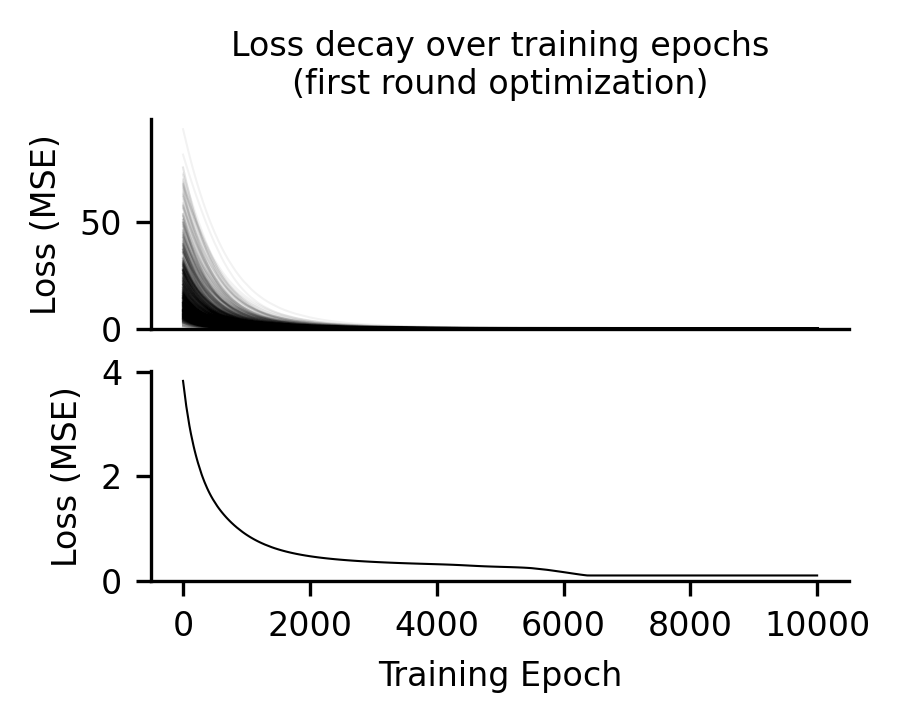

In [14]:
fig, ax = plt.subplots(2, figsize = (3,2))

for i, decay in enumerate(loss_decay.T):
    ax[0].plot(decay, alpha = 0.05, color = 'black', linewidth = linewidth)

ax[1].set_xlabel("Training Epoch", fontsize = fontsize)
ax[0].set_ylabel("Loss (MSE)", fontsize = fontsize)
ax[0].set_ylim(0,)
ax[0].set_xticks([])

ax[1].set_ylabel("Loss (MSE)", fontsize = fontsize)
ax[1].plot(loss_decay[:,best], alpha = 1, color = 'black', linewidth = linewidth)
ax[1].set_ylim(0.)
ax[0].set_title("Loss decay over training epochs\n(first round optimization)", fontsize = fontsize)

for i in range(2):
    ax[i].tick_params(labelsize = fontsize)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

figname = '2d_model_loss_decay_first_round.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

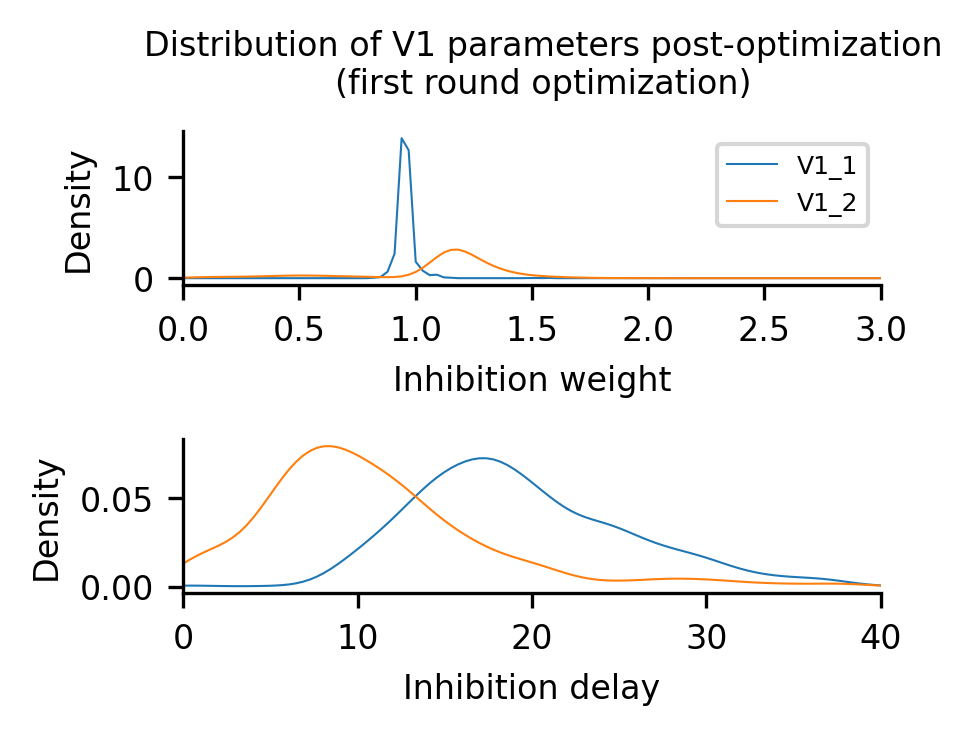

In [15]:
fig, ax = plt.subplots(2,1, figsize = (3, 2))

for i in range(2):
    i_ = np.abs(i-1)
    for u in range(2):
        x = np.linspace(
            list(param_bounds.values())[-1-i][0],
            list(param_bounds.values())[-1-i][1],
            100
        )
        data = param_history['V1_params'][:,-1,u,0,i_,0,0]
        kde = gaussian_kde(data)
        y = kde(x)

        ax[i].plot(x,y, label = f'V1_{u+1}', linewidth = linewidth)
        ax[i].set_xlim(
            list(param_bounds.values())[-1-i][0],
            list(param_bounds.values())[-1-i][1]
        )
        ax[i].set_ylabel("Density", fontsize = fontsize)
        ax[i].spines['top'].set_visible(False)
        ax[i].spines['right'].set_visible(False)
        ax[i].tick_params(labelsize = fontsize)

ax[0].set_xlabel('Inhibition weight', fontsize = fontsize)
ax[1].set_xlabel('Inhibition delay', fontsize = fontsize)
ax[0].legend(fontsize = 6)
fig.subplots_adjust(hspace=1)
plt.suptitle("Distribution of V1 parameters post-optimization\n(first round optimization)", fontsize = fontsize, x = 0.525, y = 1.05)

figname = '2d_model_v1_param_density_func_first_round.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

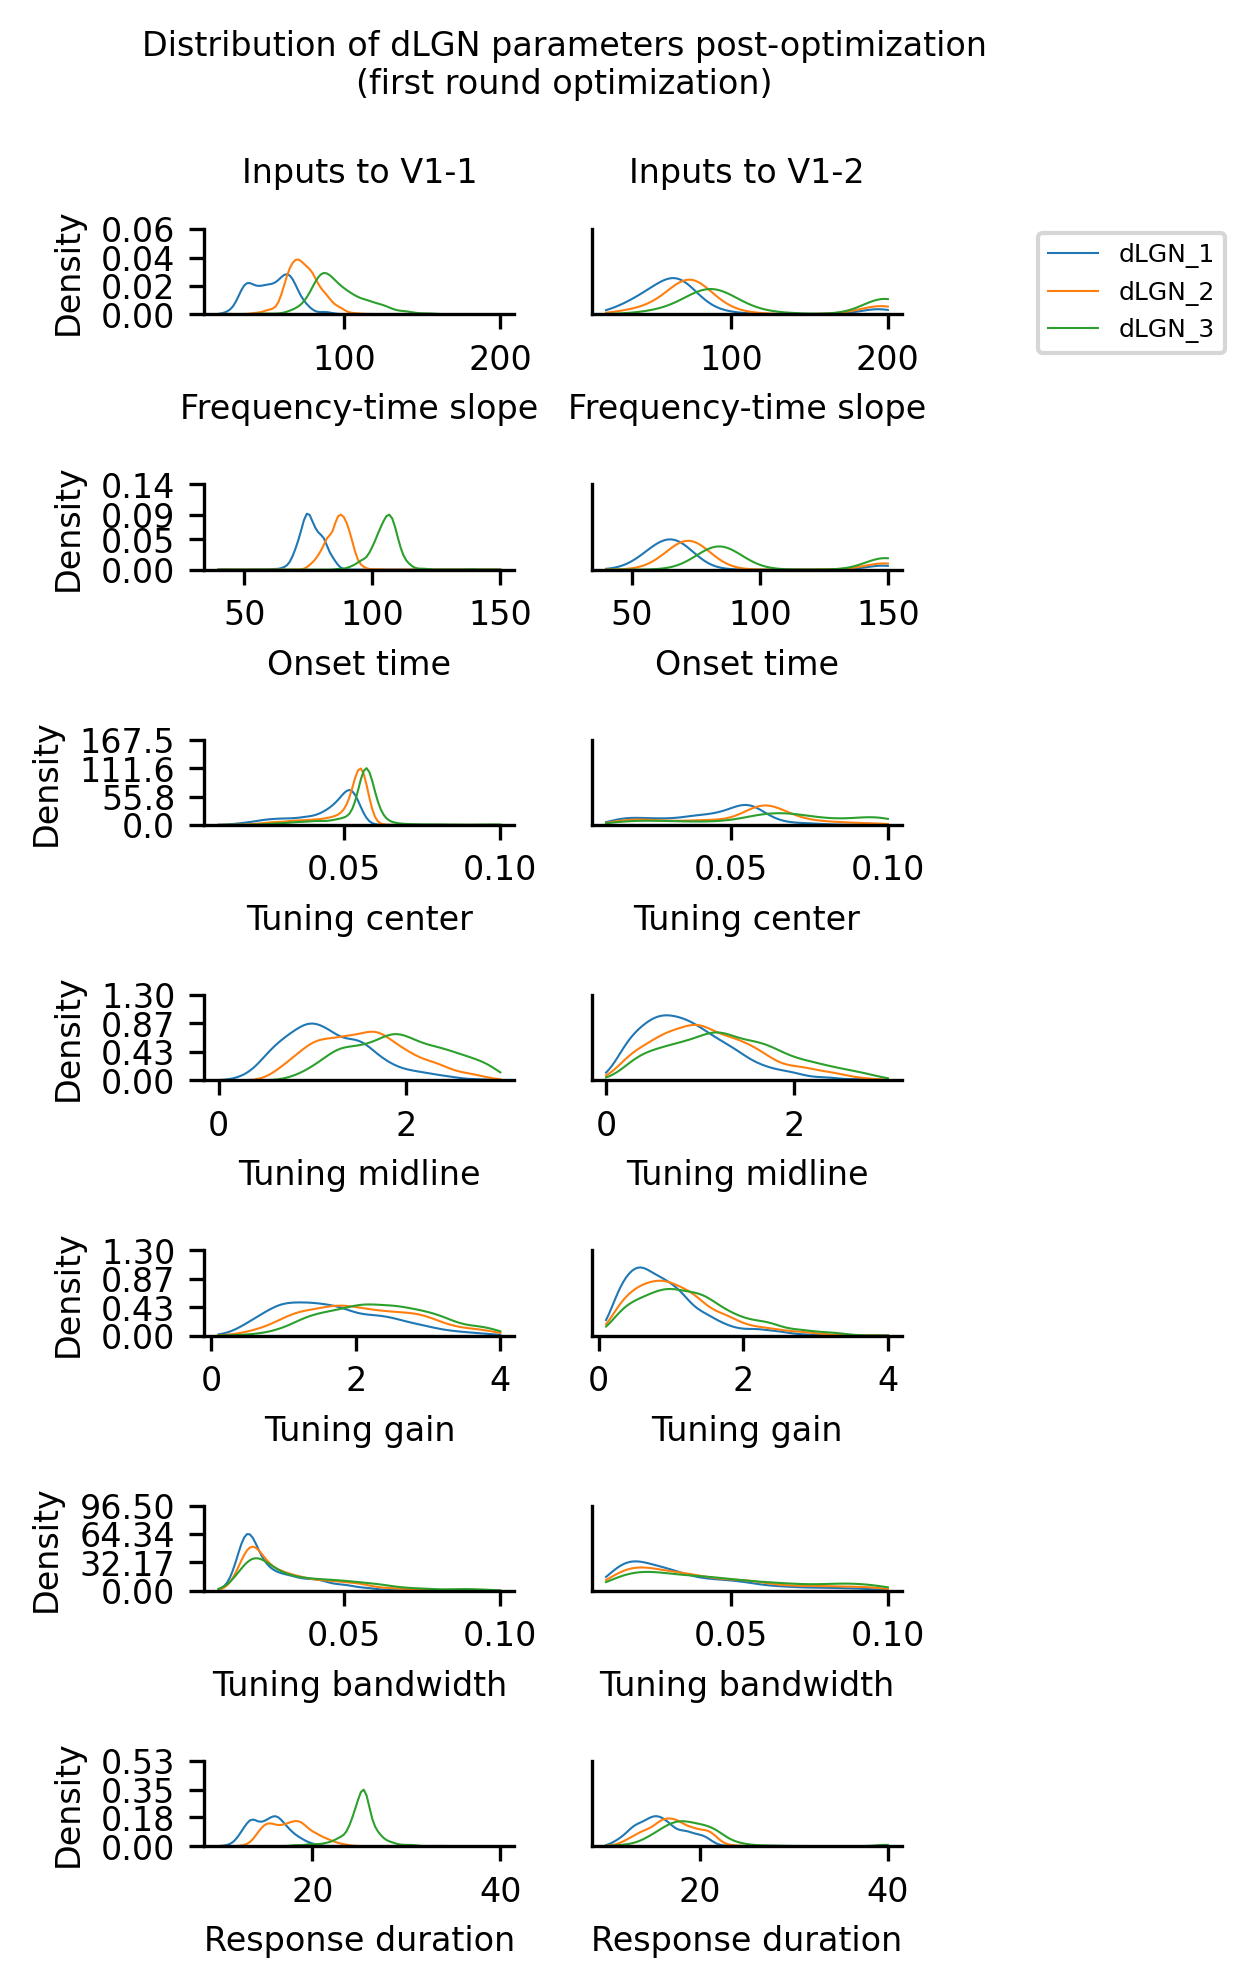

In [16]:
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Onset time',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Response duration'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            data = param_history['dLGN_params'][:,-1,u,i,row,0,0]
            x = np.linspace(
                list(param_bounds.values())[:7][row][0],
                list(param_bounds.values())[:7][row][1], 
                100
            )
            kde = gaussian_kde(data)
            y = kde(x)

            ymax.append(y.max())
            
            ax[row, u].plot(x, y, label = neuron_labels[i], linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("Density", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, np.max(ymax)+np.max(ymax)*0.25)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.linspace(0, np.max(ymax)+np.max(ymax)*0.5, 4).round(2))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.4,1.1))
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Distribution of dLGN parameters post-optimization\n(first round optimization)", fontsize = fontsize, x = 0.525, y = 0.975)

figname = '2d_model_dlgn_param_density_func_first_round.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

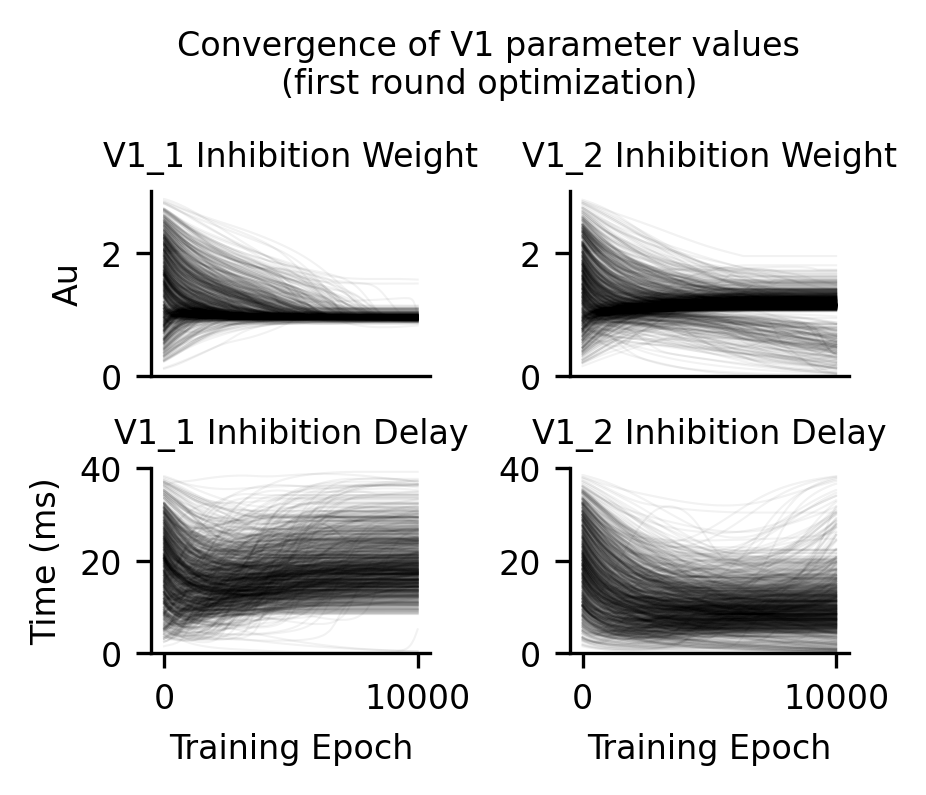

In [17]:
## inhibition weight::inhibition delay

fig, ax = plt.subplots(2,2, figsize = (3,2))

inh_w = 1
v1_n = 0 

for row in range(2):
    for col in range(2):
        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

ax[0,0].plot(
    param_history['V1_params'][:,:,v1_n,0,inh_w,0,0].T,
    linewidth=linewidth,
    alpha=0.05,
    color = 'black'
)

# 
v1_n = 1
ax[0,1].plot(
    param_history['V1_params'][:,:,v1_n,0,inh_w,0,0].T,
    linewidth=linewidth,
    alpha=0.05,
    color = 'black'
)

# a0
inh_d = 0
v1_n = 0
ax[1,0].plot(
    param_history['V1_params'][:,:,v1_n,0,inh_d,0,0].T,
    linewidth=linewidth,
    alpha=0.05,
    color = 'black'
)

# a1
v1_n = 1
ax[1,1].plot(
    param_history['V1_params'][:,:,v1_n,0,inh_d,0,0].T,
    linewidth=linewidth,
    alpha=0.05,
    color = 'black'
)

ax[0,0].set_ylim(0,3)
ax[0,0].set_title("V1_1 Inhibition Weight", fontsize = fontsize)
ax[0,0].set_xticks([])
ax[0,0].set_ylabel("Au", fontsize = fontsize)

ax[0,1].set_ylim(0,3)
ax[0,1].set_title("V1_2 Inhibition Weight", fontsize = fontsize)
ax[0,1].set_xticks([])

ax[1,0].set_ylim(0,40)
ax[1,0].set_title("V1_1 Inhibition Delay", fontsize = fontsize)
ax[1,0].set_ylabel("Time (ms)", fontsize = fontsize)
ax[1,0].set_xlabel("Training Epoch", fontsize = fontsize)

ax[1,1].set_ylim(0,40)
ax[1,1].set_title("V1_2 Inhibition Delay", fontsize = fontsize)
ax[1,1].set_xlabel("Training Epoch", fontsize = fontsize)
fig.subplots_adjust(wspace=0.5, hspace=0.5)
plt.suptitle("Convergence of V1 parameter values\n(first round optimization)", fontsize = fontsize, y = 1.15)

figname = '2d_model_v1_param_convergence_first_round.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

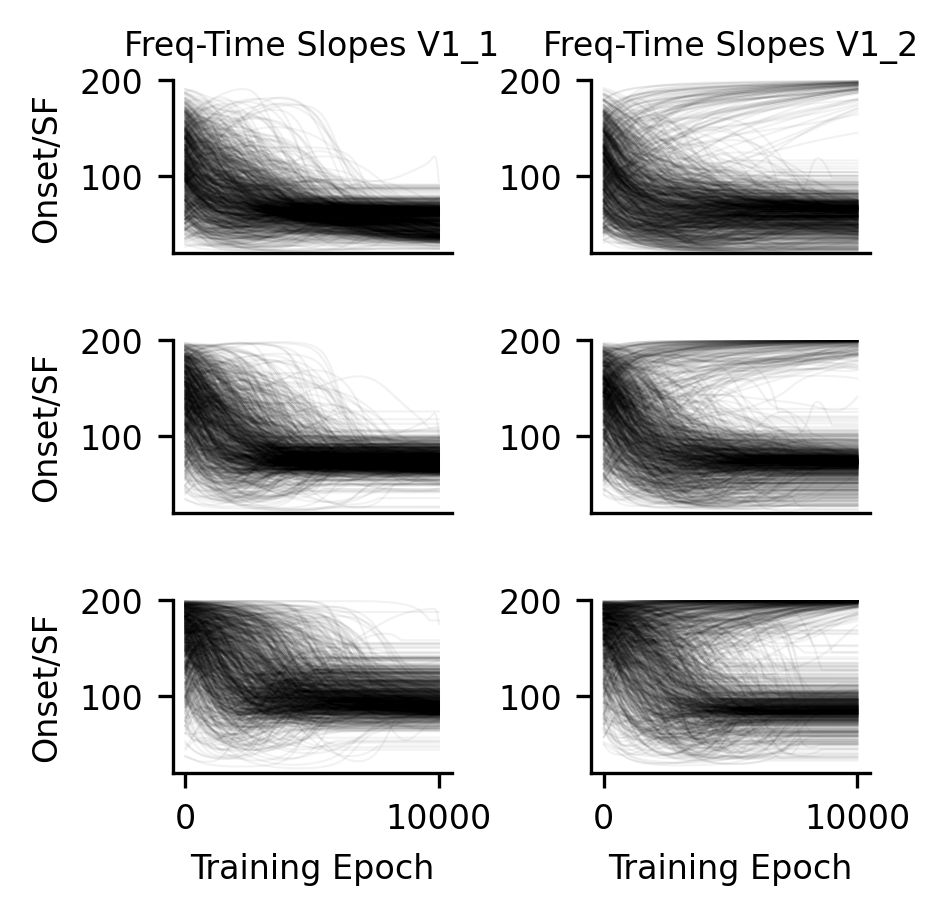

In [18]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 0

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Freq-Time Slopes V1_{i+1}", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("Onset/SF", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(20,200)
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

figname = '2d_model_fts_convergence_first_round.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

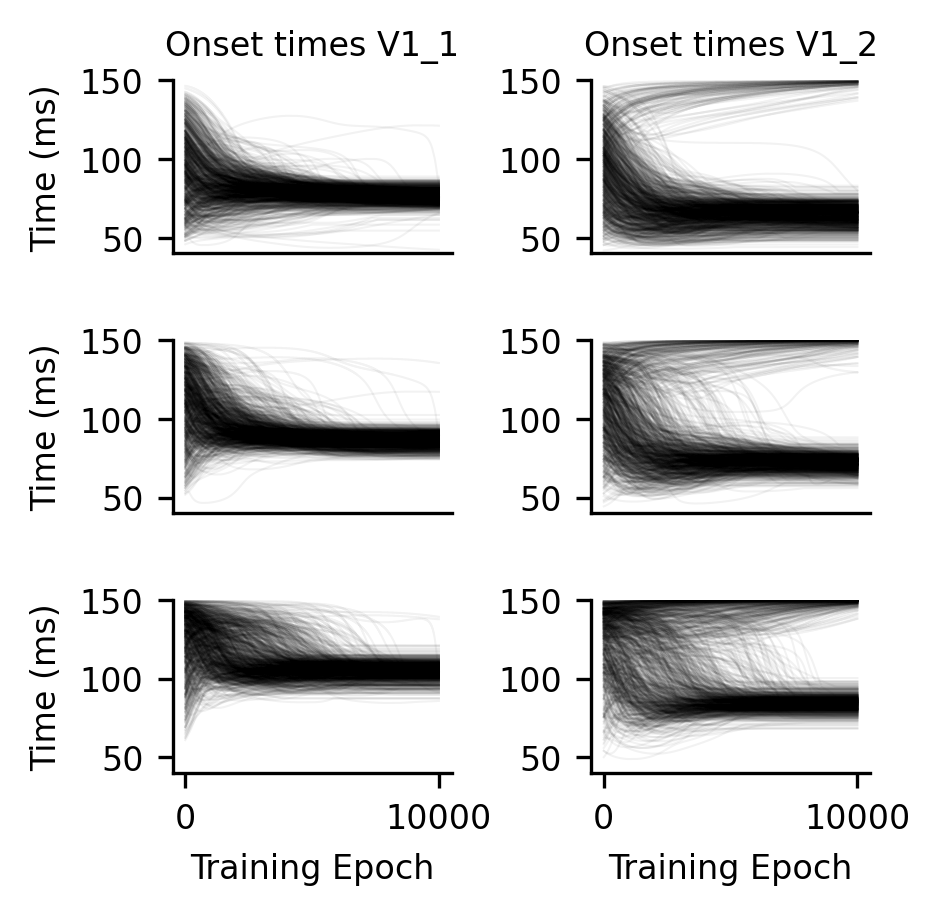

In [19]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 1

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Onset times V1_{i+1}", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("Time (ms)", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(40,150)
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

figname = '2d_model_t_convergence_first_round.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

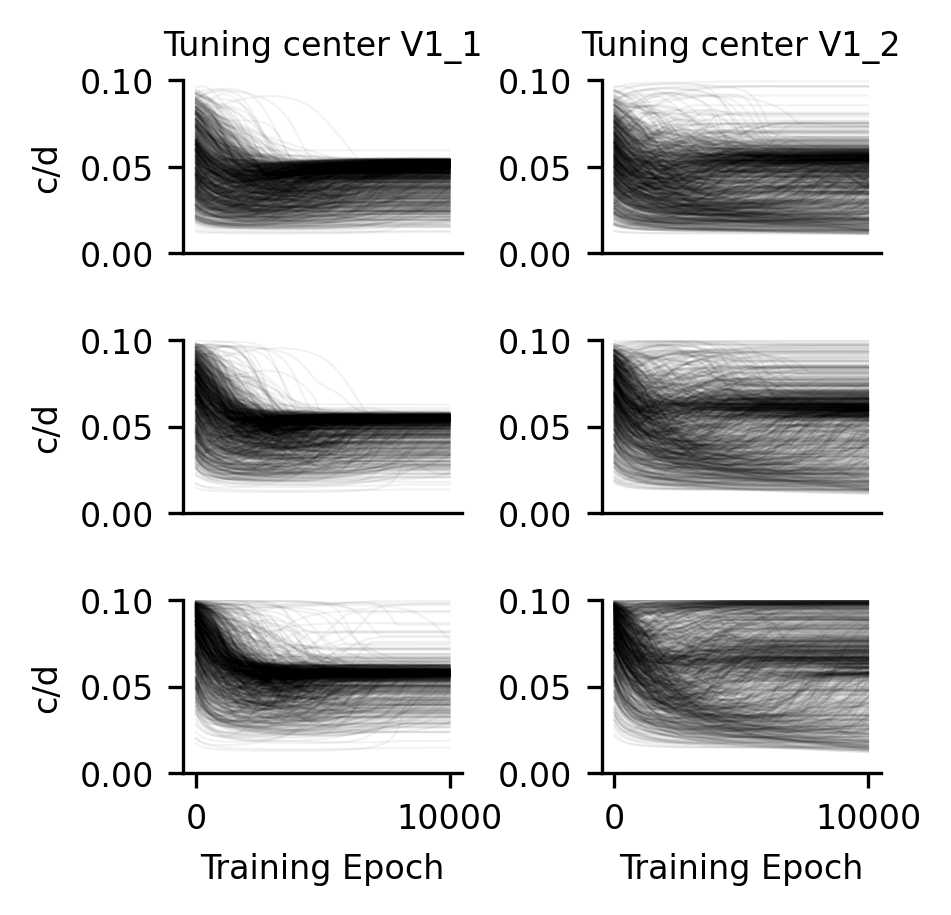

In [20]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 2

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Tuning center V1_{i+1}", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("c/d", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(0,0.1)
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

figname = '2d_model_ampc_convergence_first_round.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

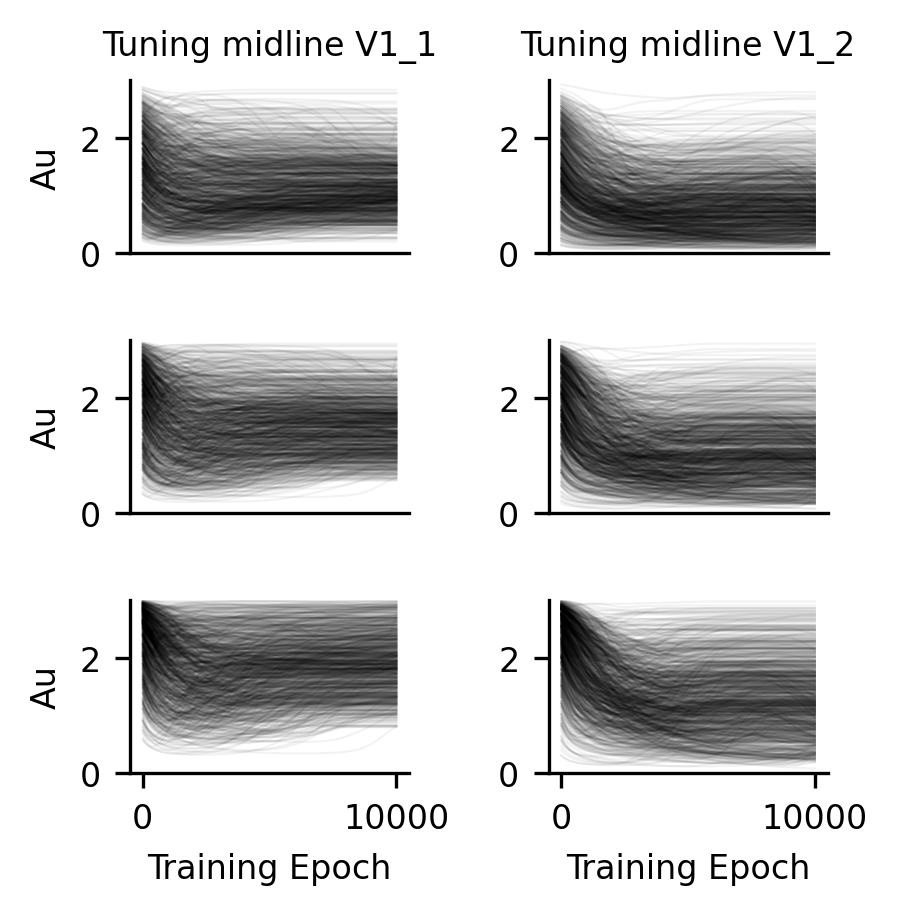

In [21]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 3

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Tuning midline V1_{i+1}", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("Au", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(0,3)
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

figname = '2d_model_ampm_convergence_first_round.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

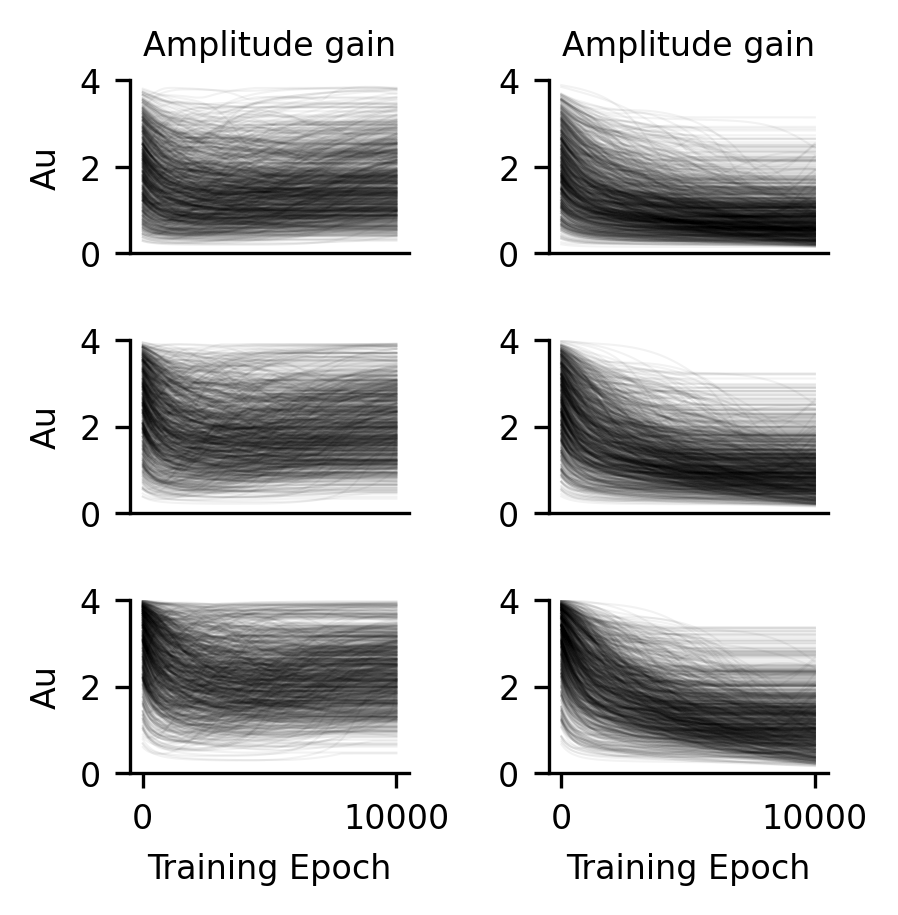

In [22]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 4

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Amplitude gain", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("Au", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(0,4)
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

figname = '2d_model_ampg_convergence_first_round.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

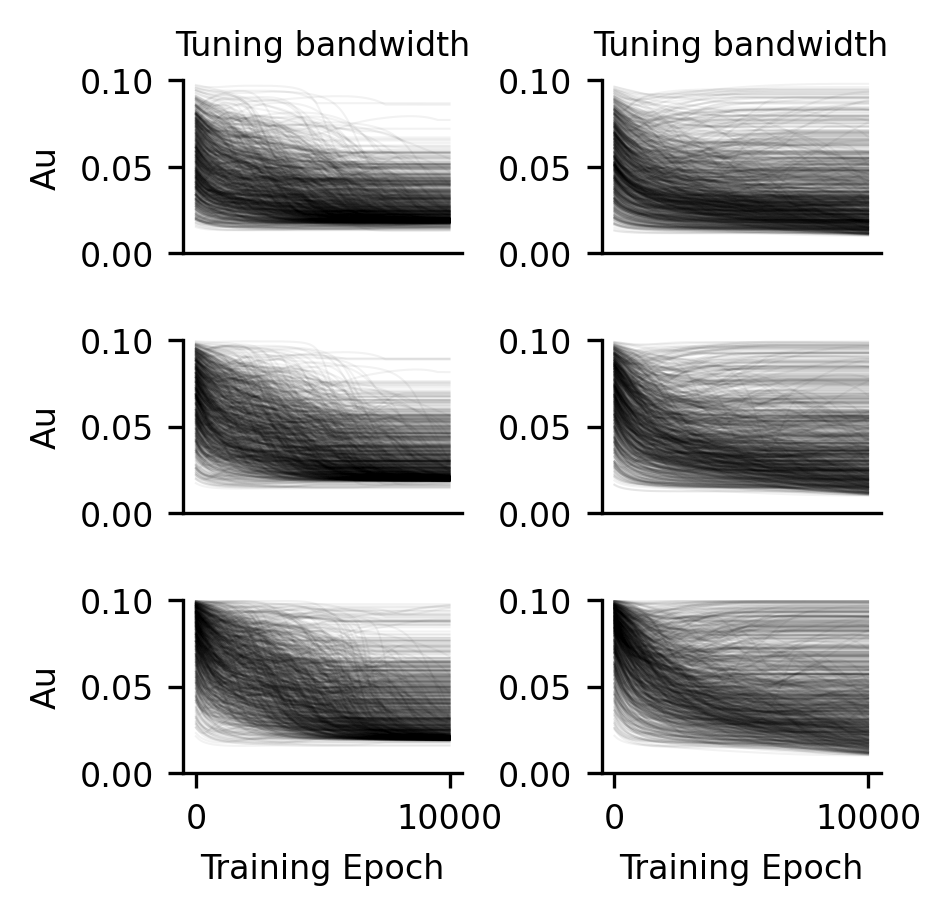

In [23]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 5

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Tuning bandwidth", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("Au", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(0,0.1)
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

figname = '2d_model_ampw_convergence_first_round.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

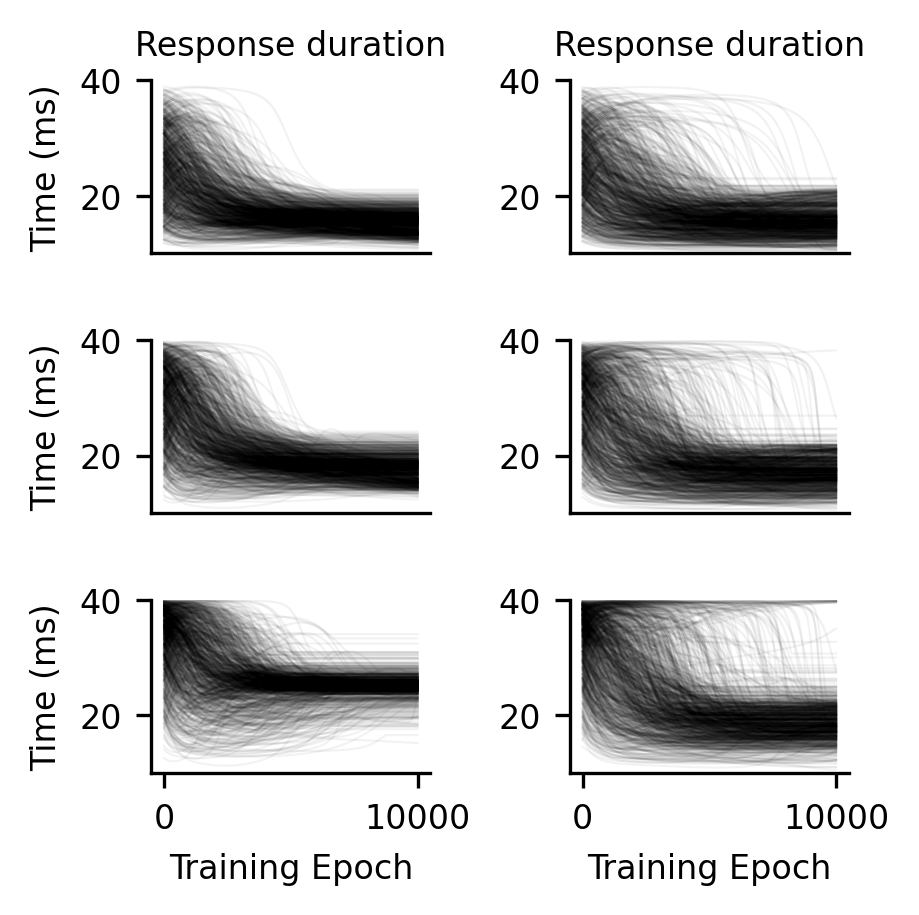

In [24]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 6

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Response duration", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("Time (ms)", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(10,40)
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

figname = '2d_model_d_convergence_first_round.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

In [25]:
res = param_history['dLGN_params'].squeeze()
print(res.shape[2:])
n_samples, n_epochs = res.shape[:2]
n_params = np.prod(res.shape[2:])# + np.prod(r2.shape[2:])

res = res.reshape(res.shape[0] * res.shape[1], np.prod(res.shape[2:]))

(2, 3, 7)


In [26]:
pca = PCA() # all epochs included
res_transformed_pca = pca.fit_transform(res).reshape(n_samples, n_epochs, n_params)

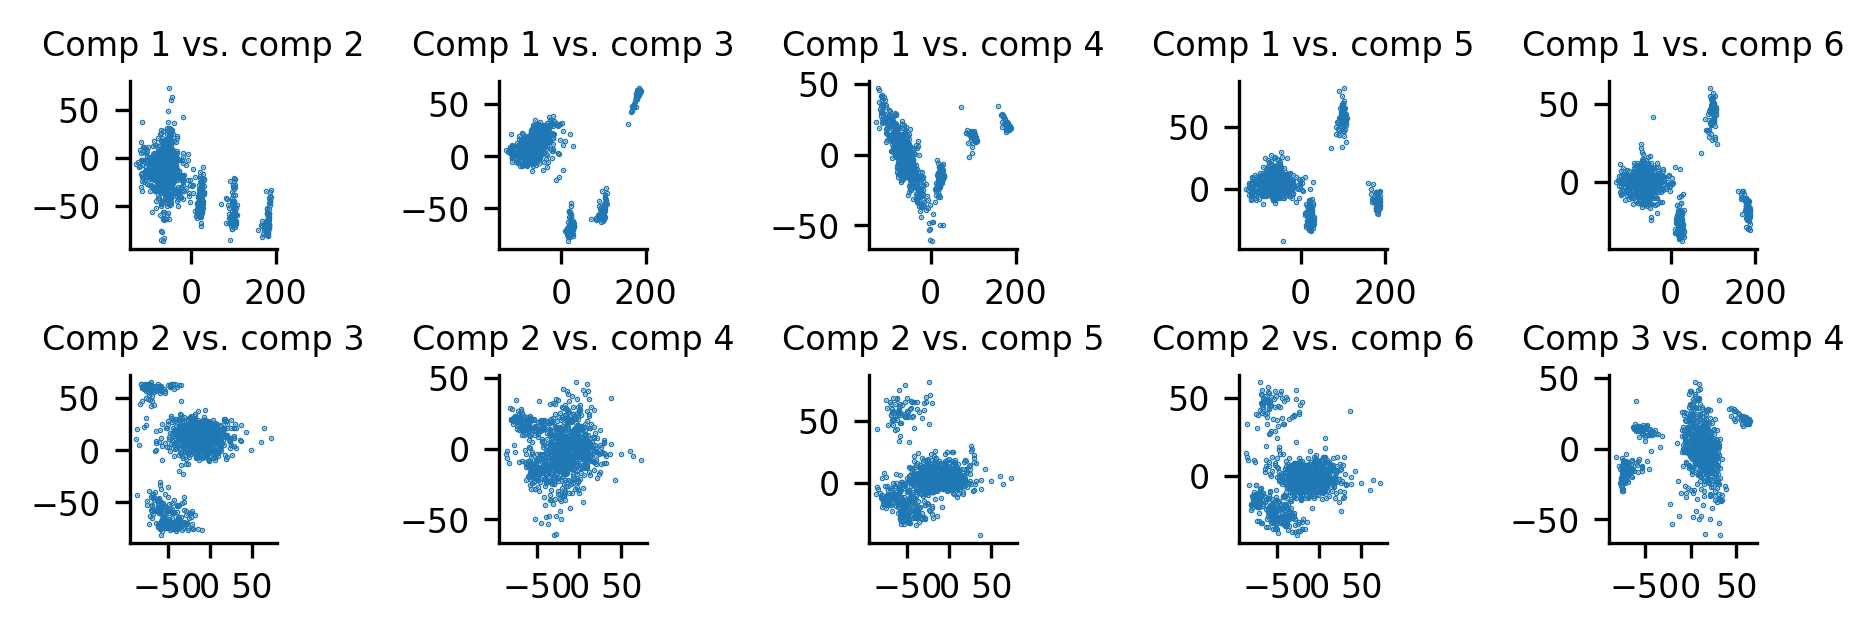

In [27]:
fig, ax = plt.subplots(2,5, figsize = (7,2))

comp_pairs = (list(combinations(np.arange(6), 2)))
i = 0
for row in range(2):
    for col in range(5):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        c0, c1 = comp_pairs[i]
        ax[row, col].scatter(res_transformed_pca[:,-1,c0], res_transformed_pca[:,-1,c1], s = 0.1) # last epoch
        ax[row, col].set_title(f"Comp {c0+1} vs. comp {c1+1}", fontsize = fontsize)
        i+=1

fig.subplots_adjust(hspace = 0.75, wspace = 1.5)
figname = '2d_model_pcaprojection_first_round.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

In [28]:
lgn_params = [
    'Frequency-time slope',
    'Onset time',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Response duration'
]

v1_params = [
    'Inhibition delay',
    'Inhibition weight'
]

lgn_units = [
    'dLGN_1 into V1_1',
    'dLGN_2 into V1_1',
    'dLGN_3 into V1_1',
    'dLGN_1 into V1_2',
    'dLGN_2 into V1_2',
    'dLGN_3 into V1_2',
]

v1_units = [
    'V1_1',
    'V1_2'
]

full_lgn_params = []
for unit in lgn_units:
    for param in lgn_params:
        full_lgn_params.append(f"{param} ({unit})")

full_v1_params = []
for unit in v1_units:
    for param in v1_params:
        full_v1_params.append(f"{param} ({unit})")
        
param_names = full_lgn_params+full_v1_params

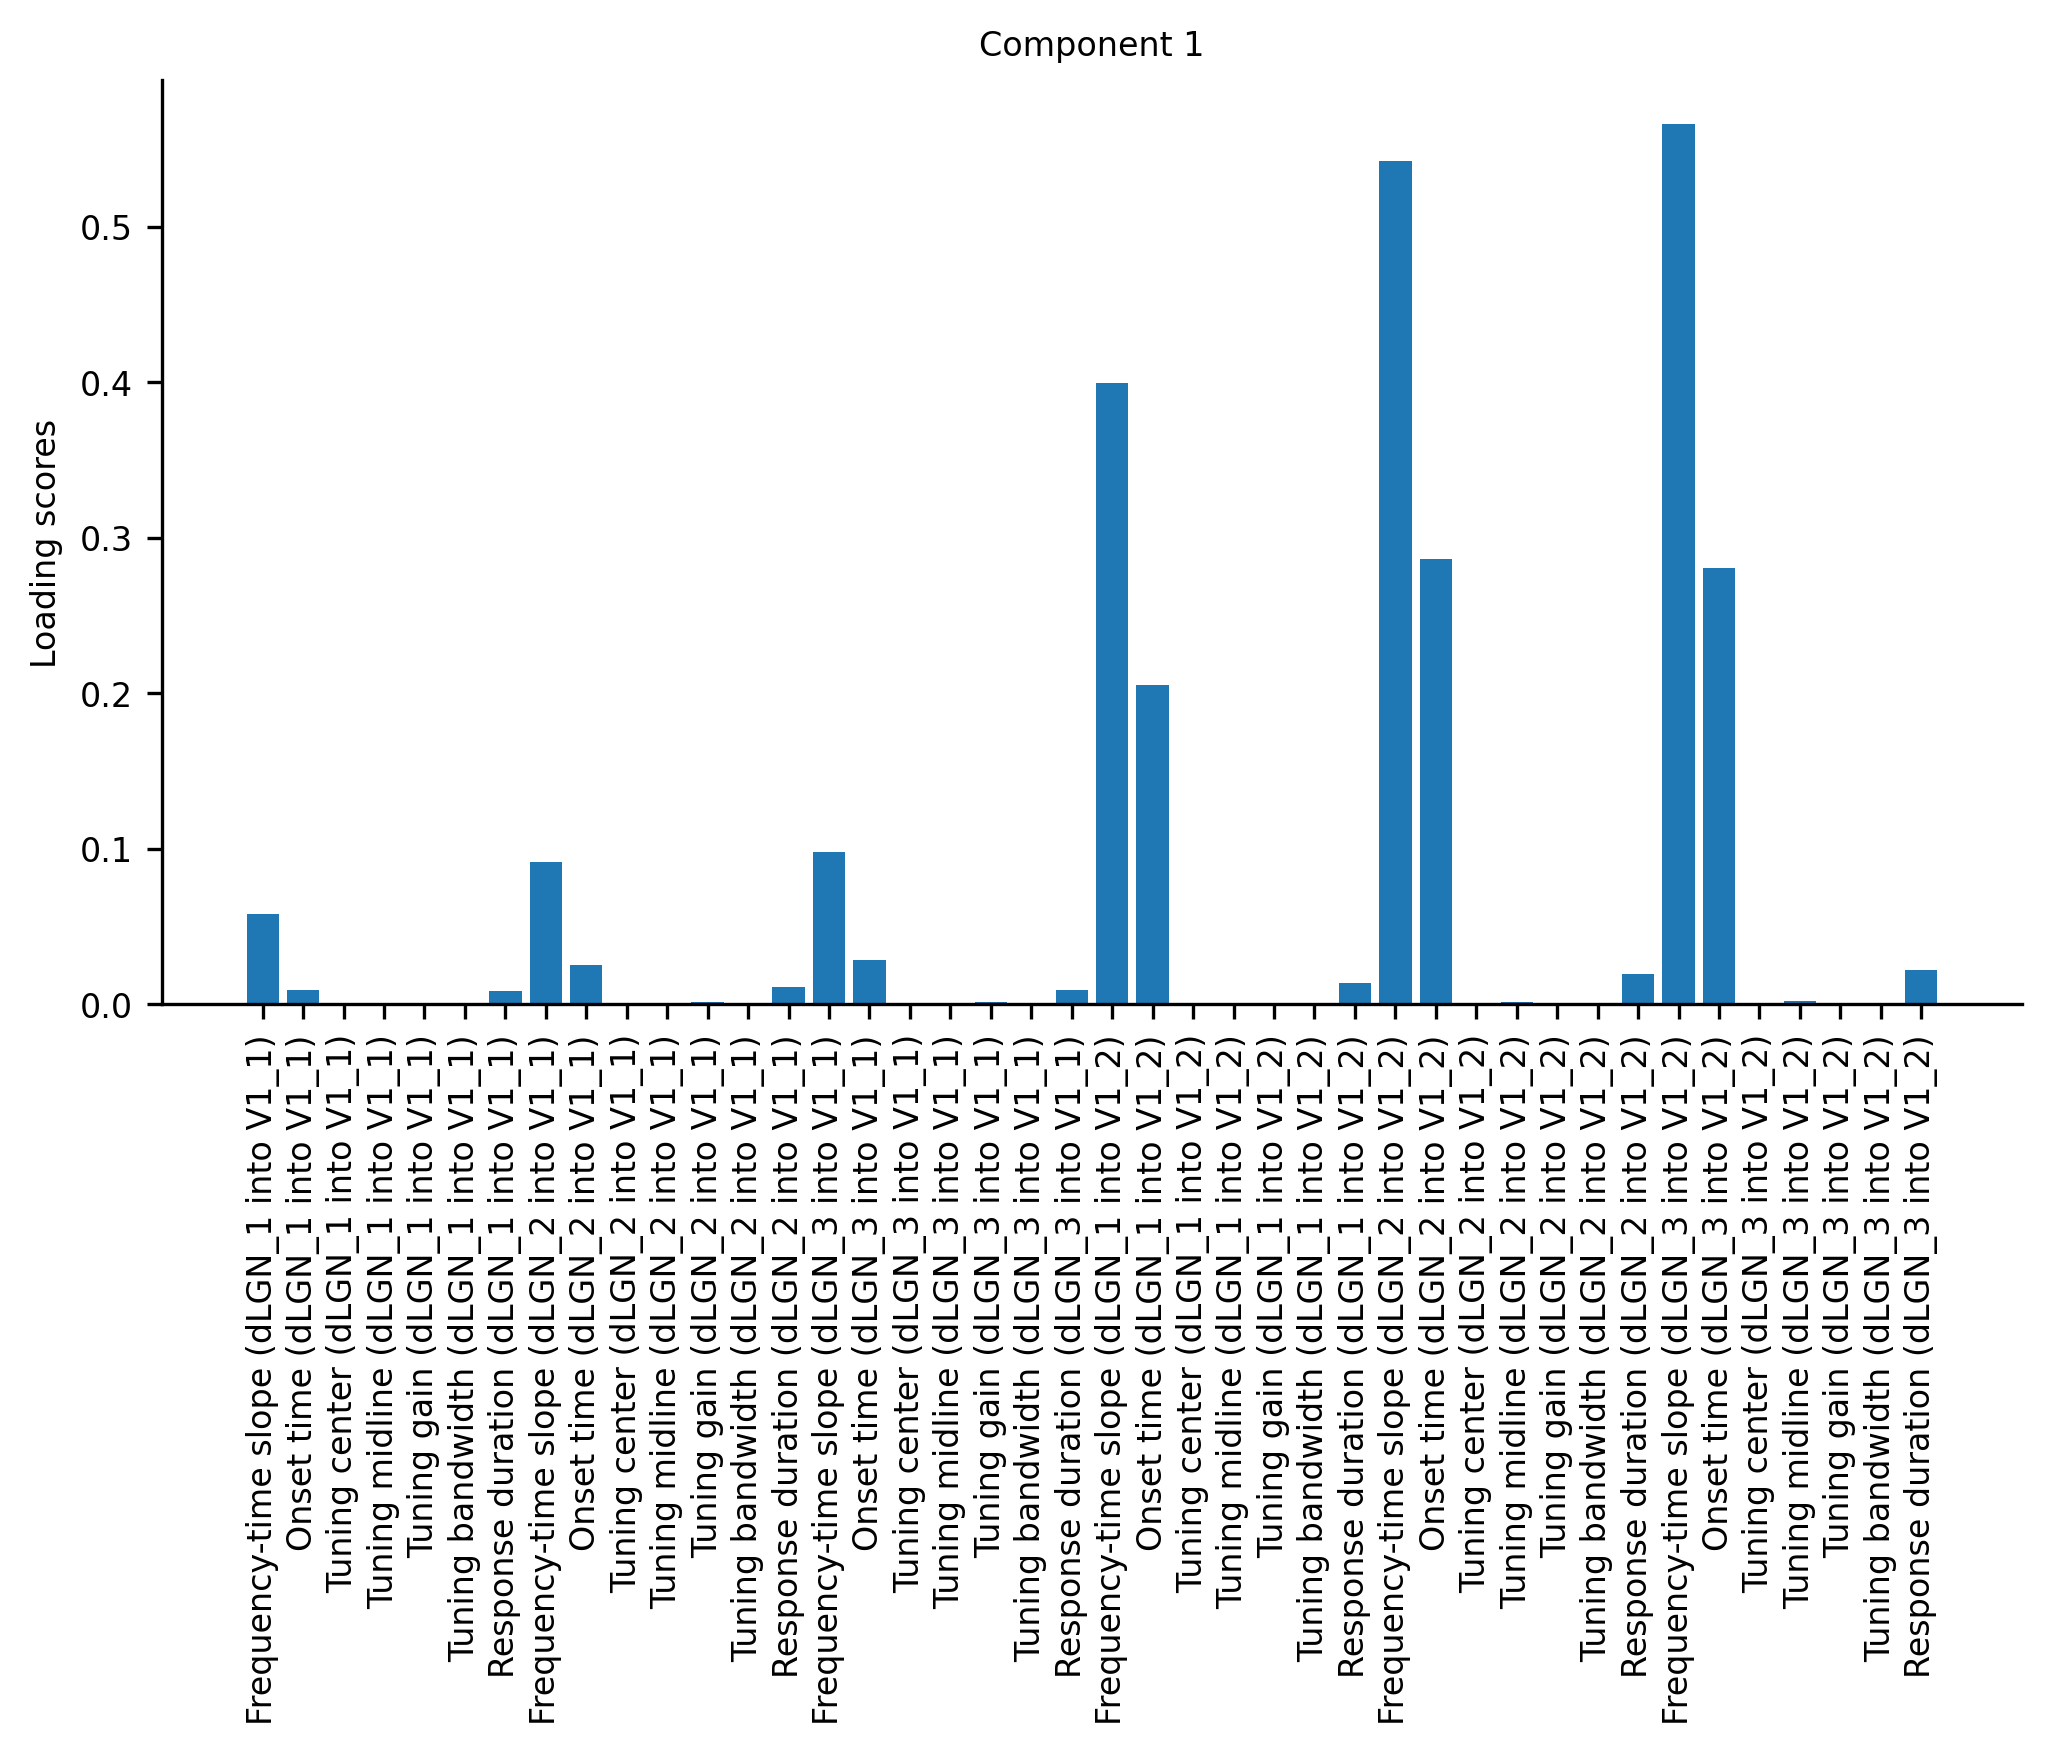

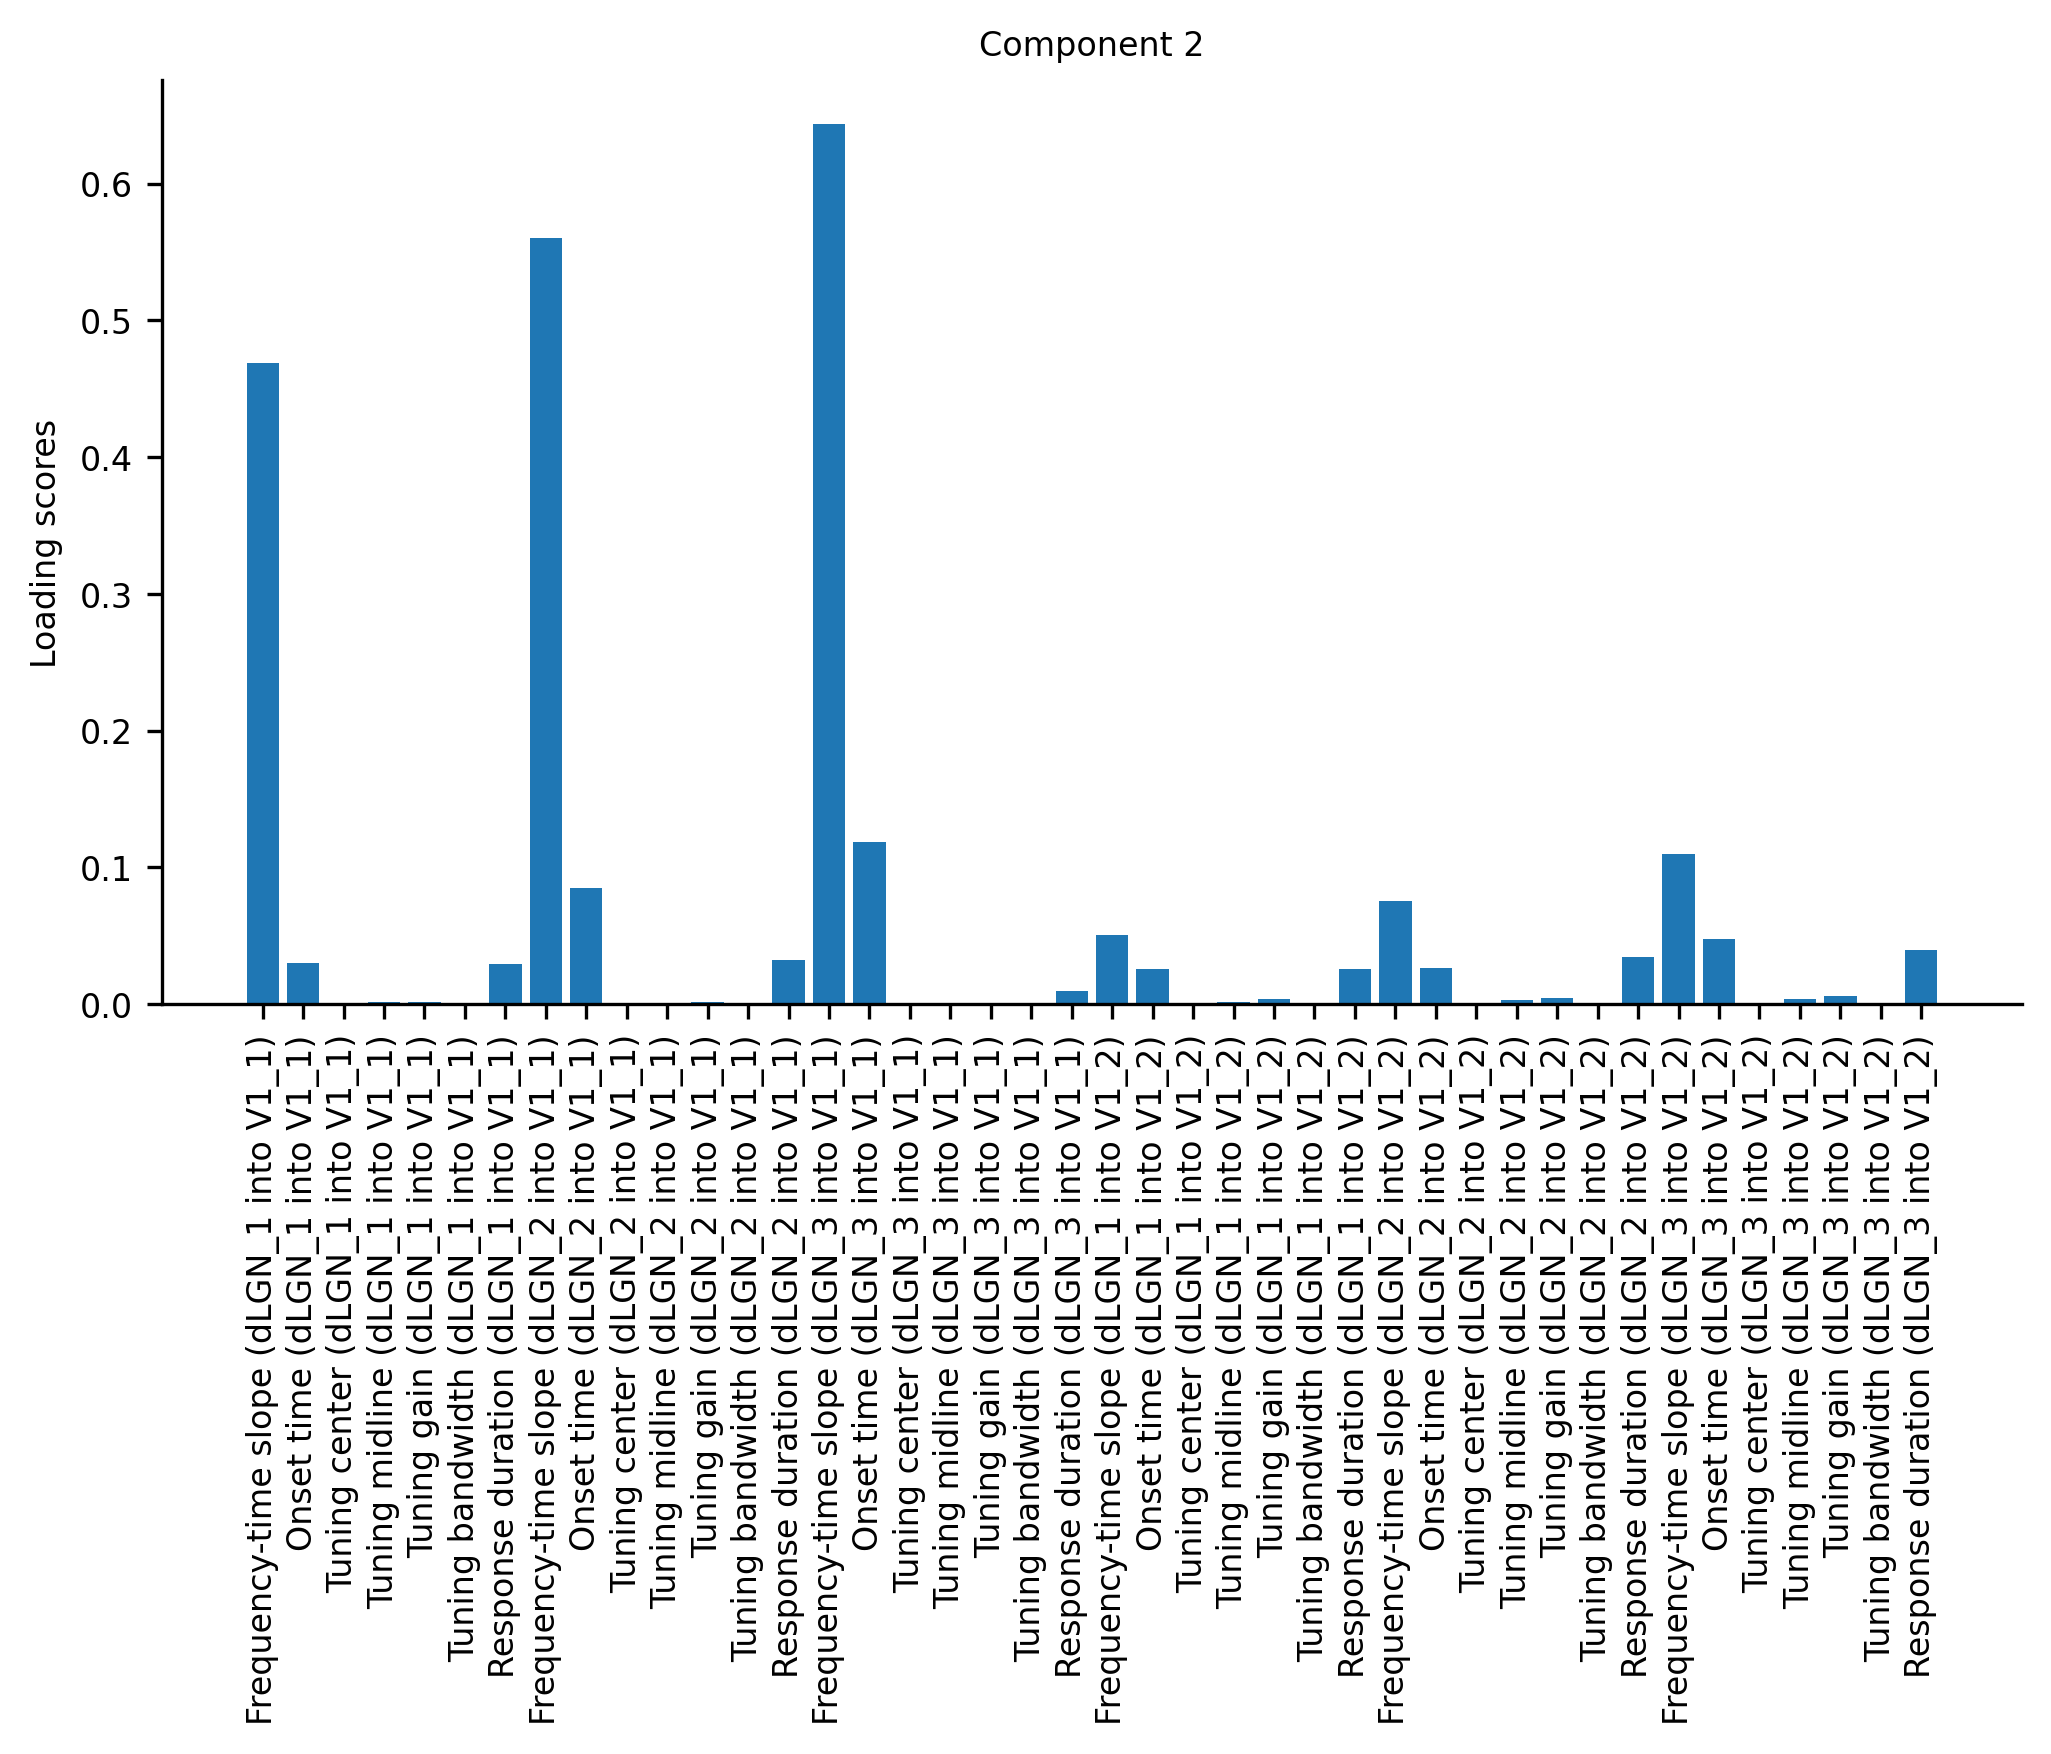

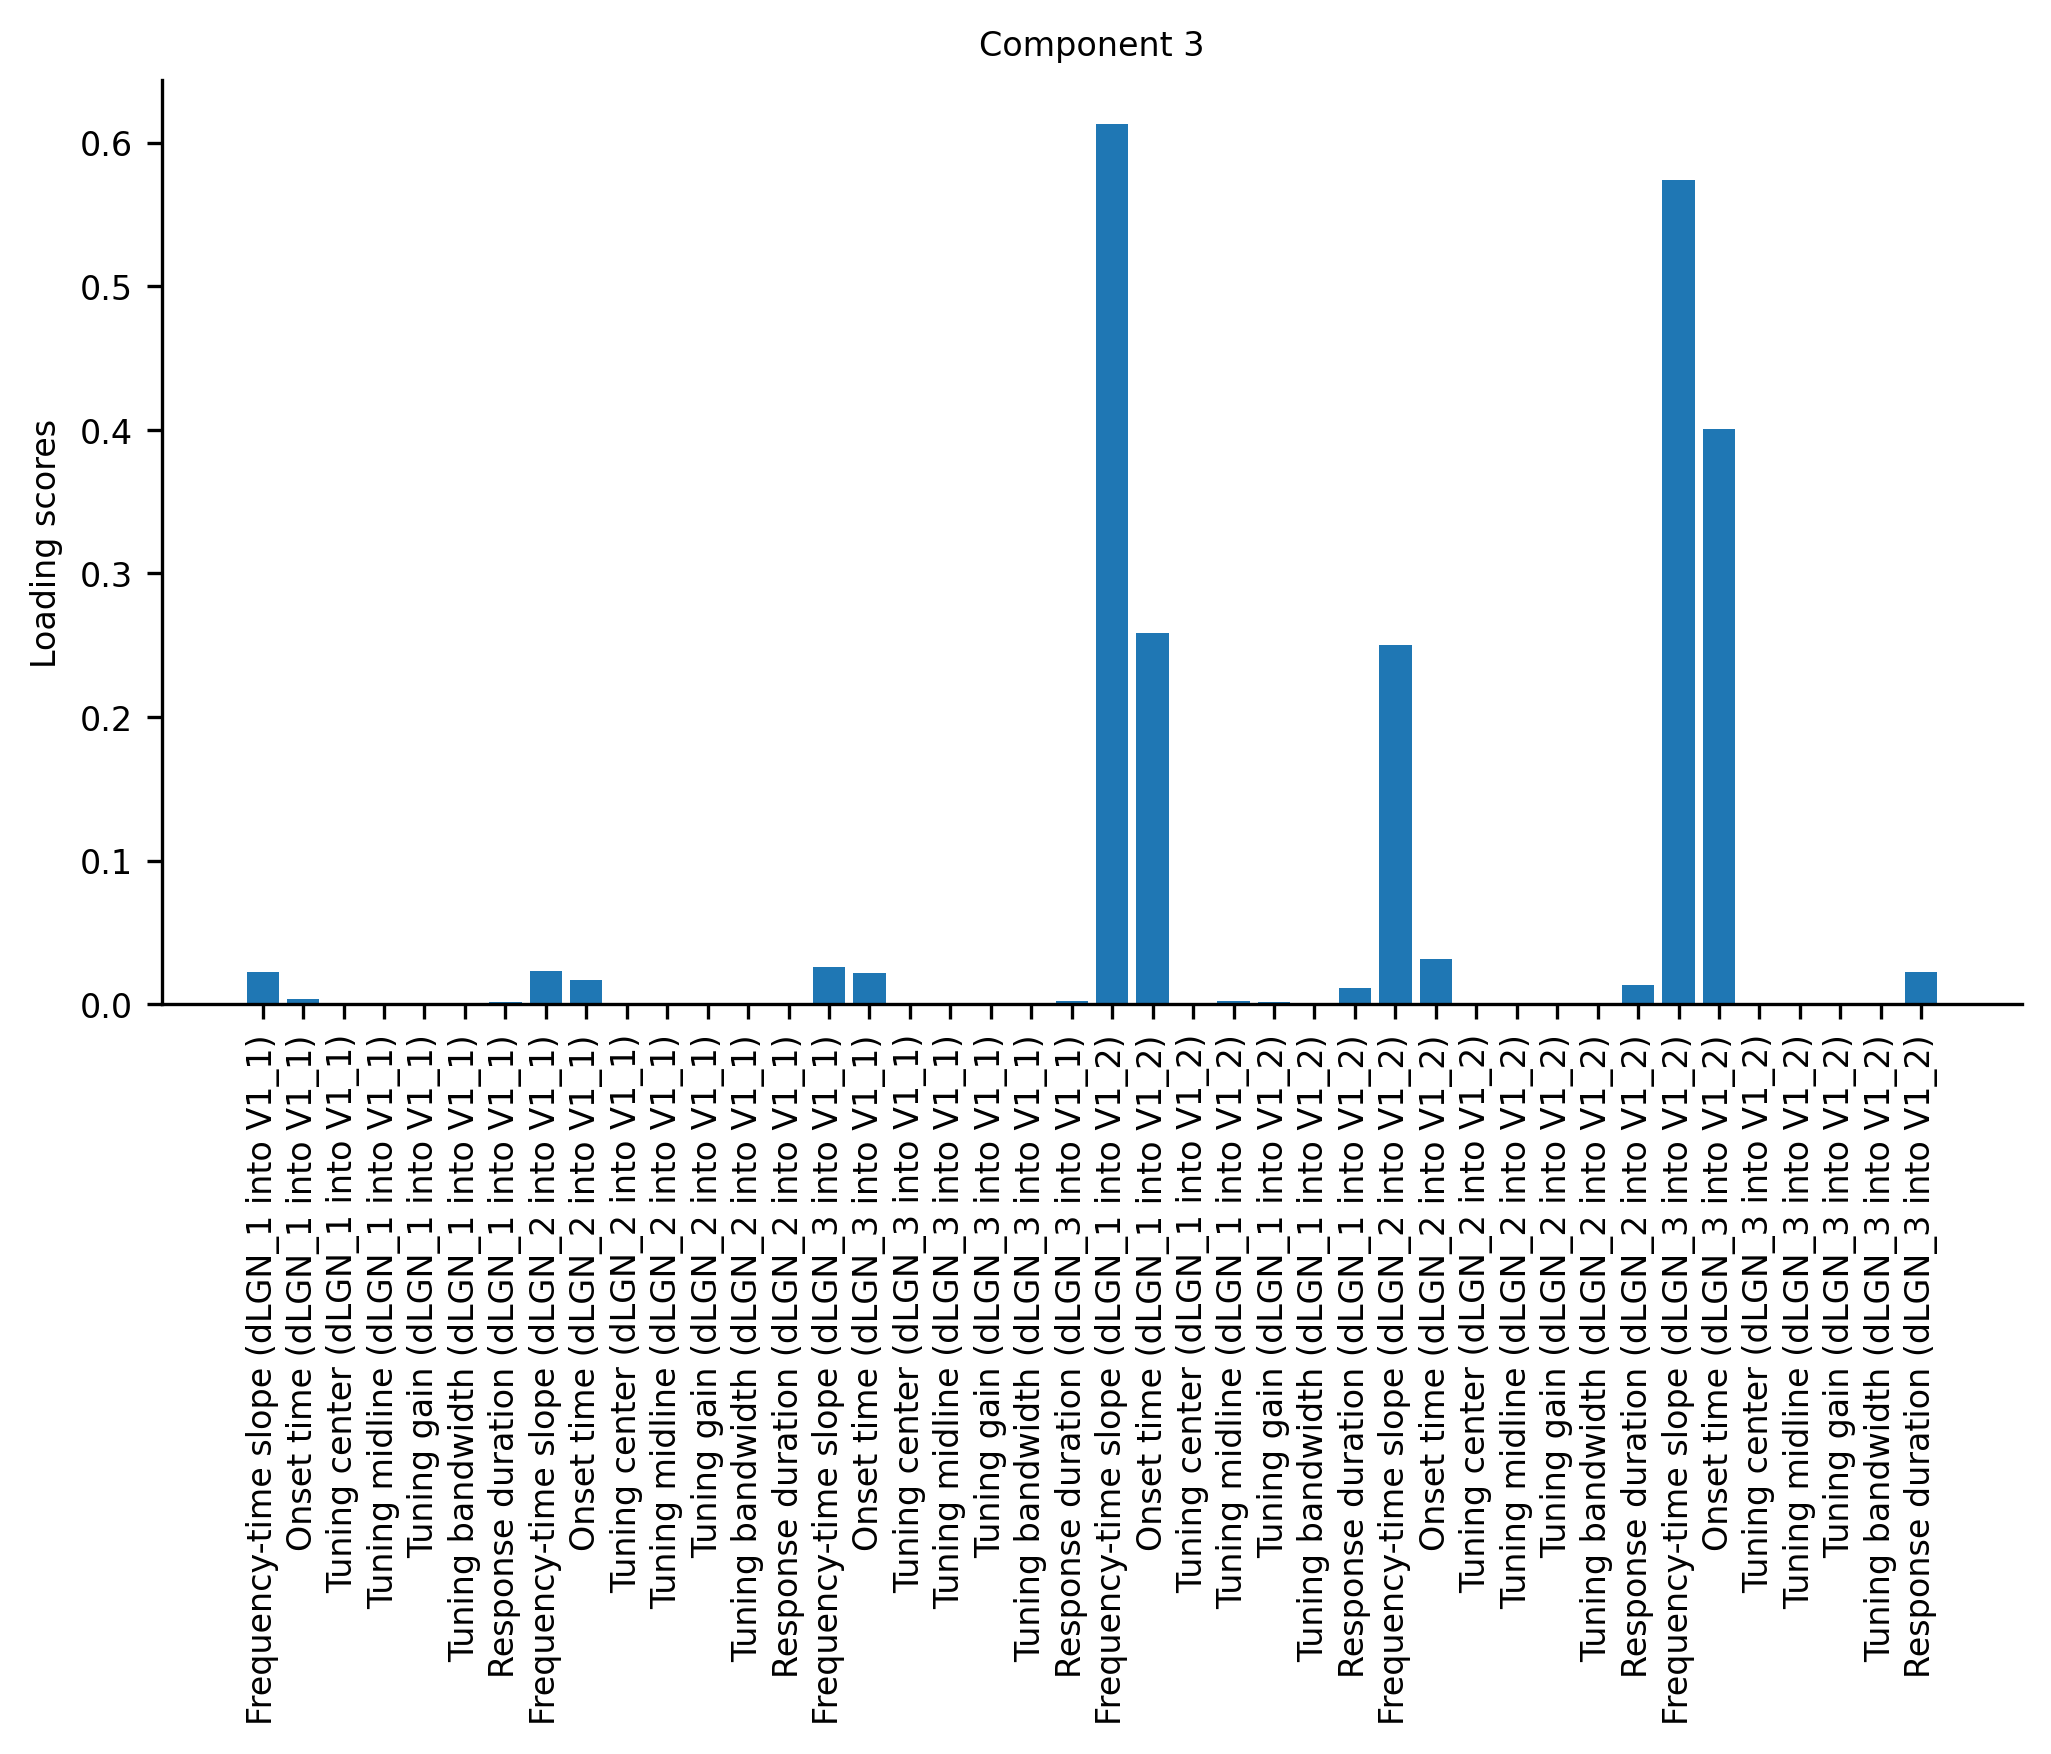

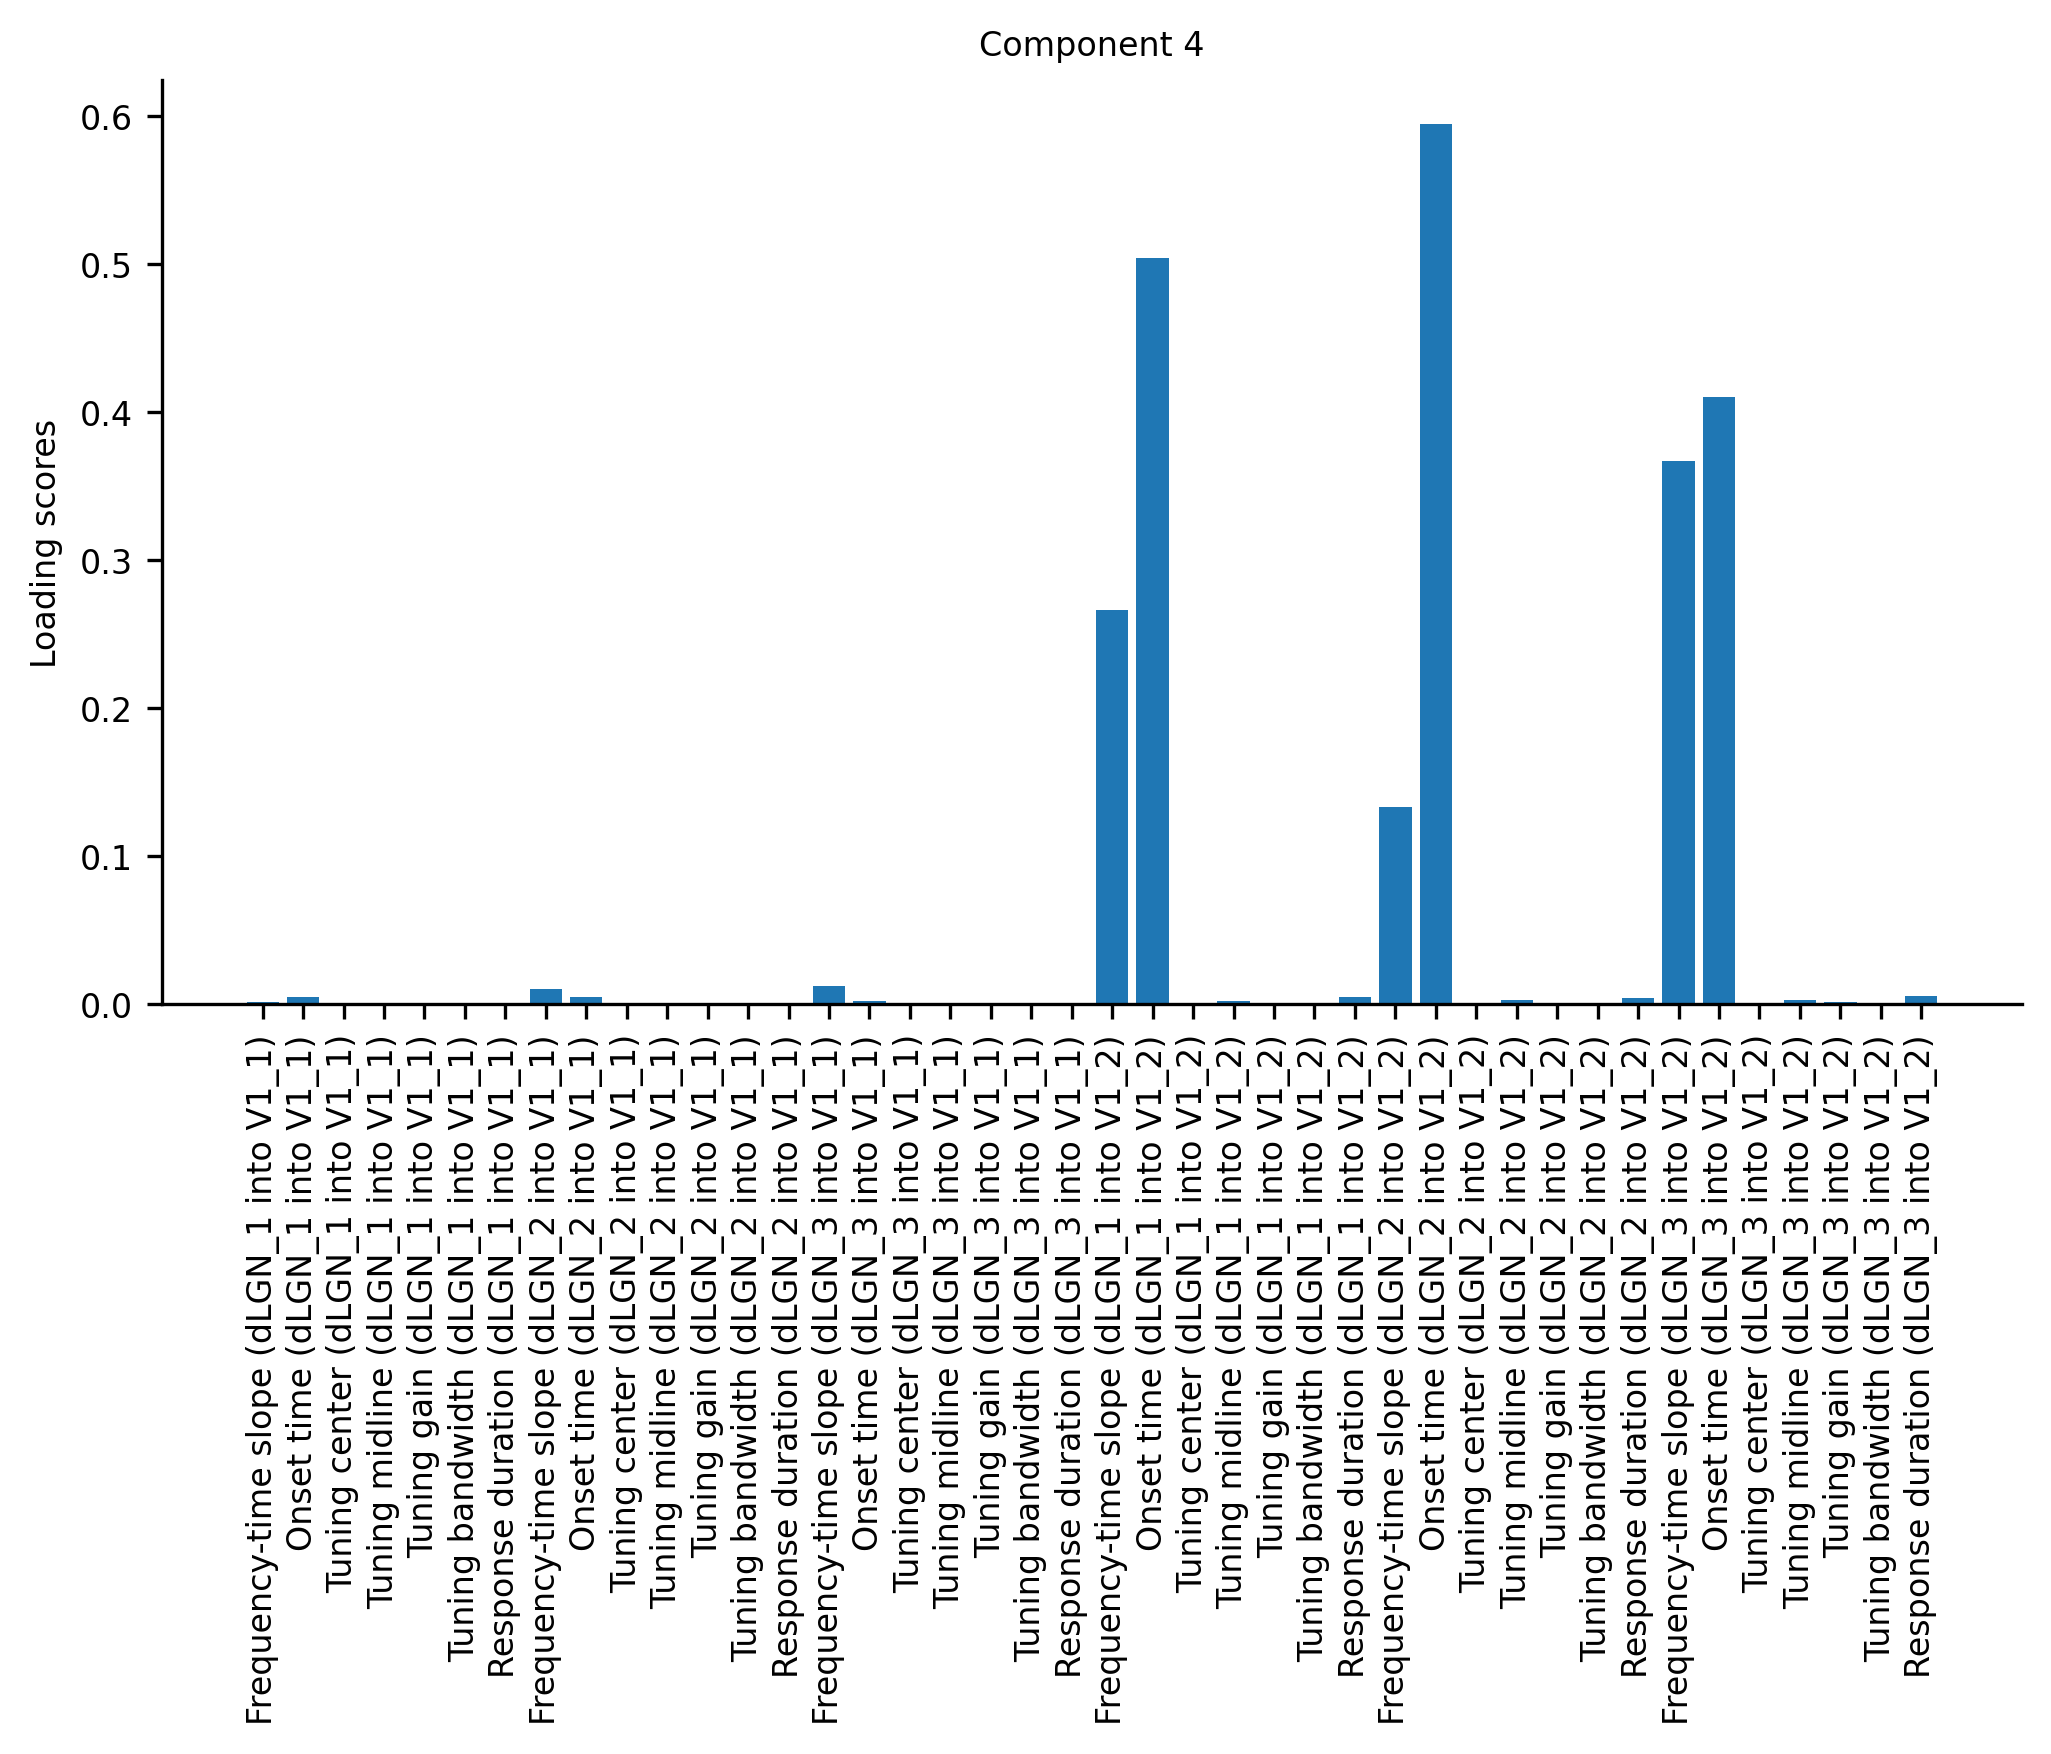

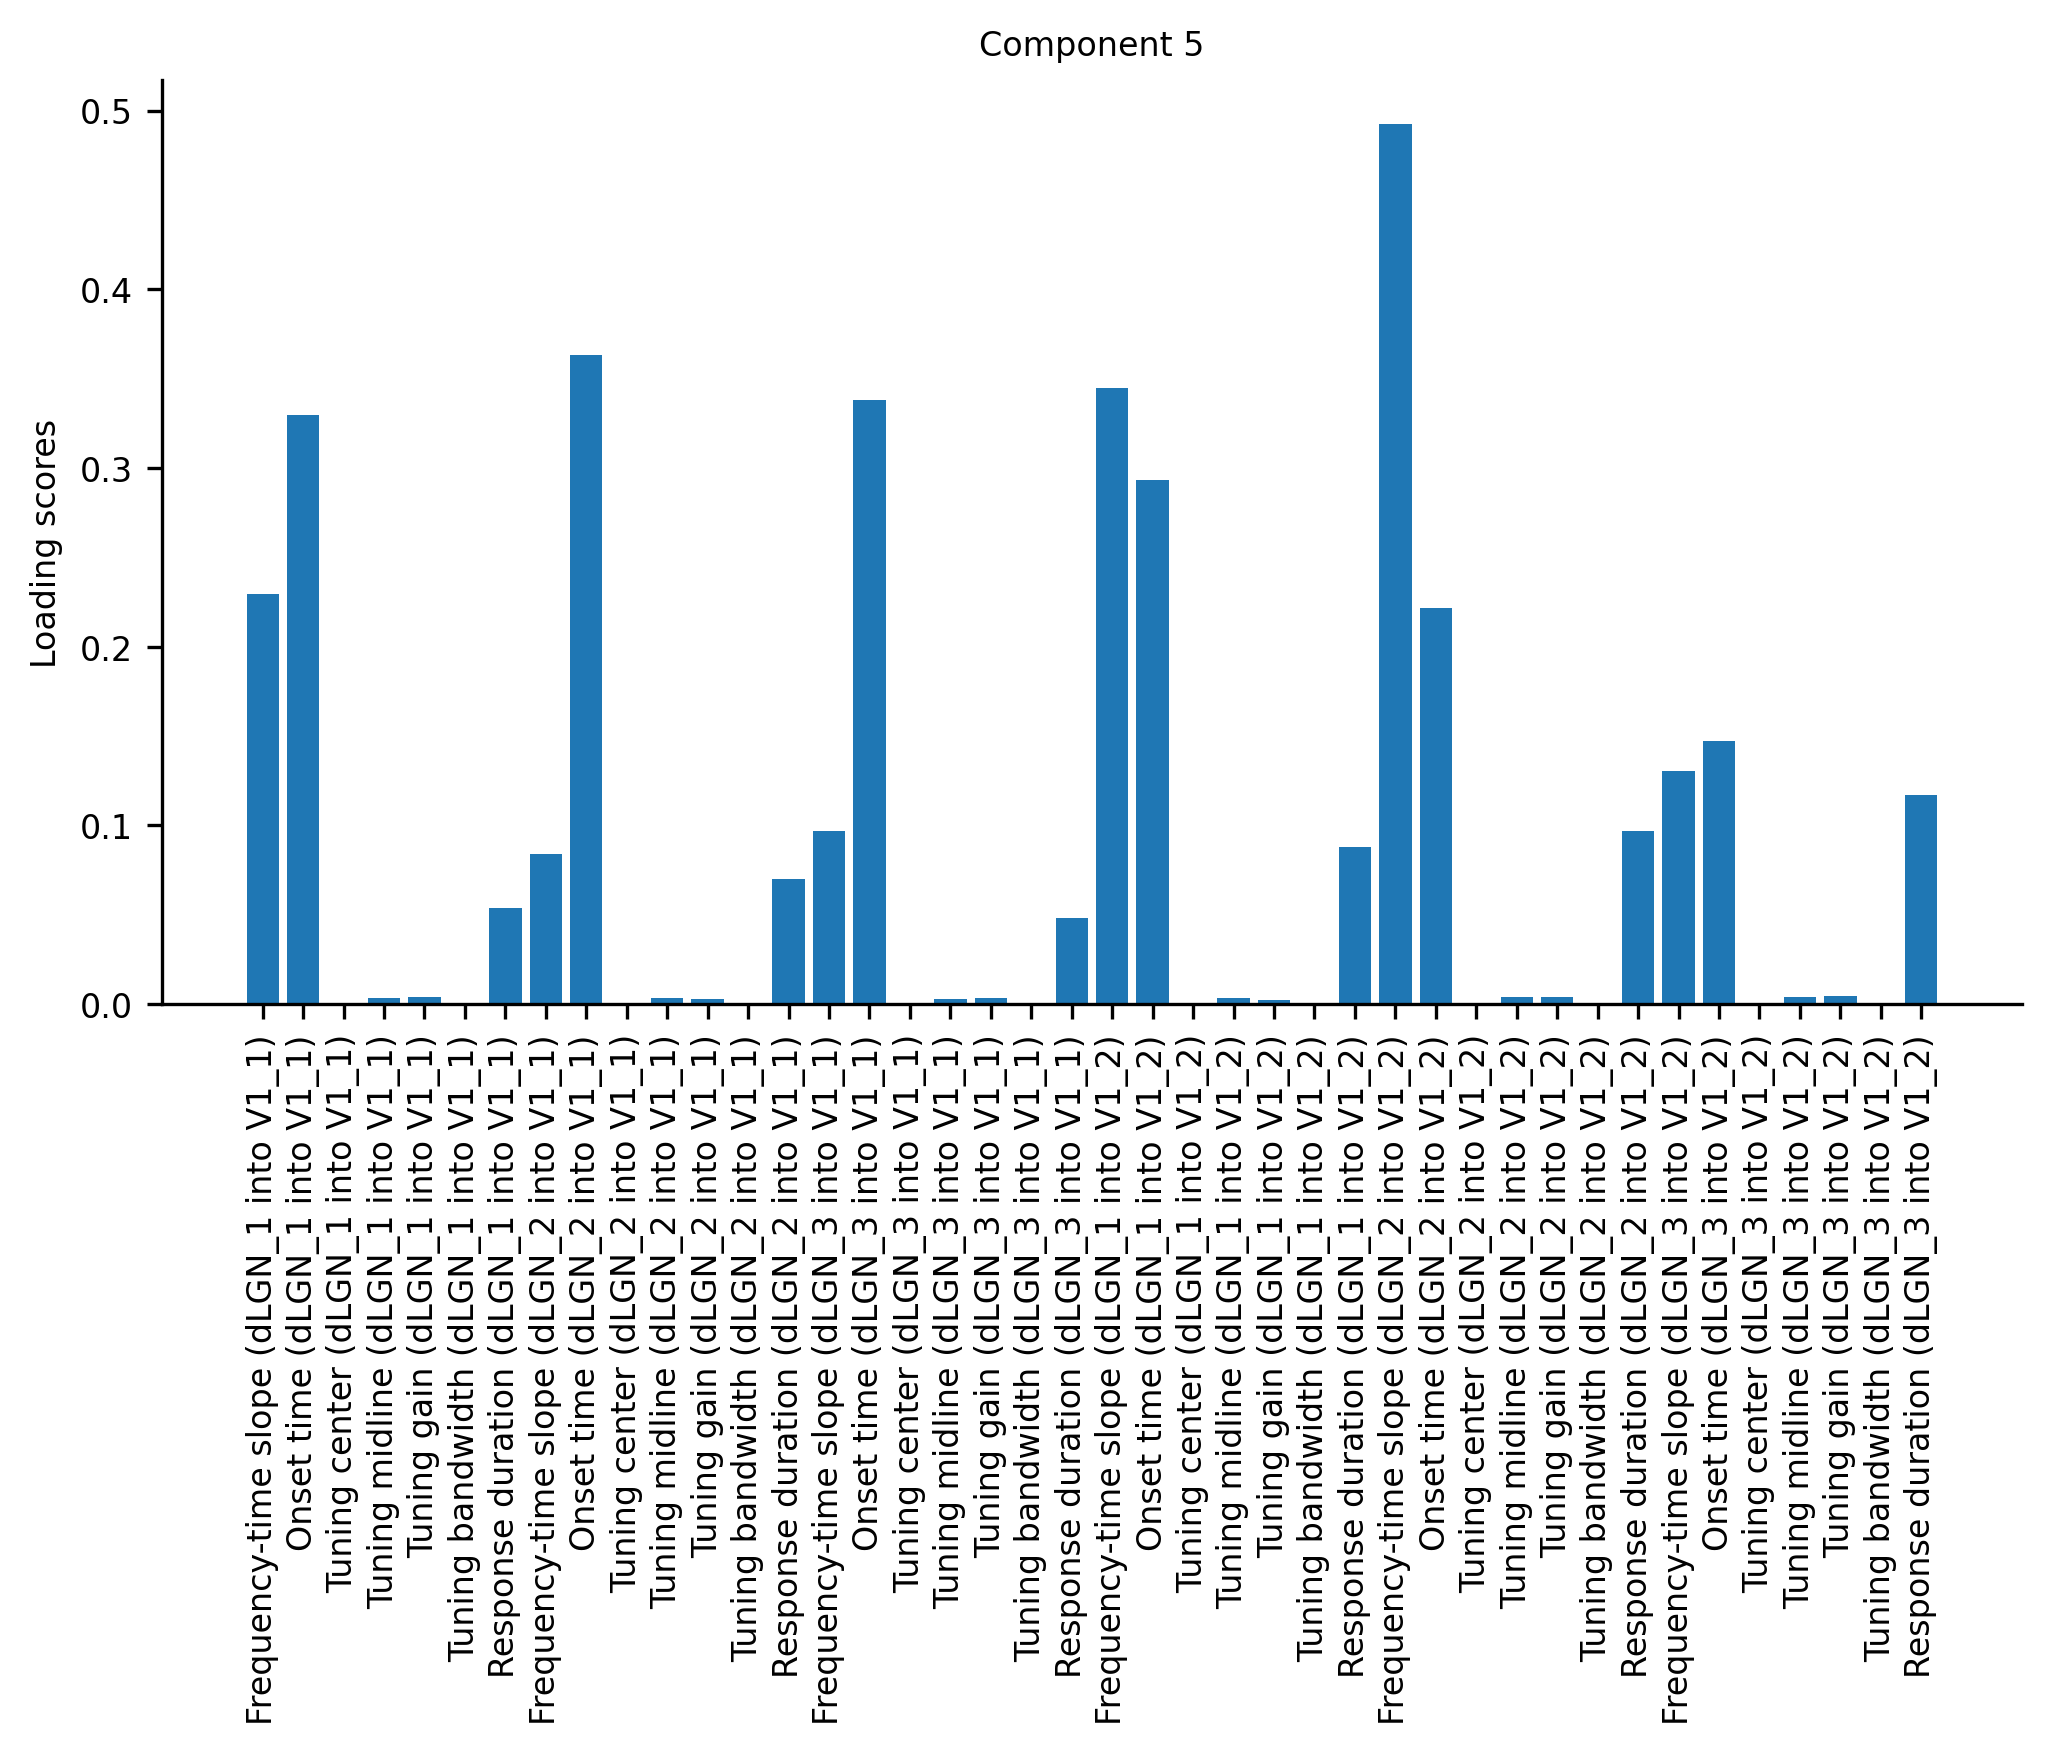

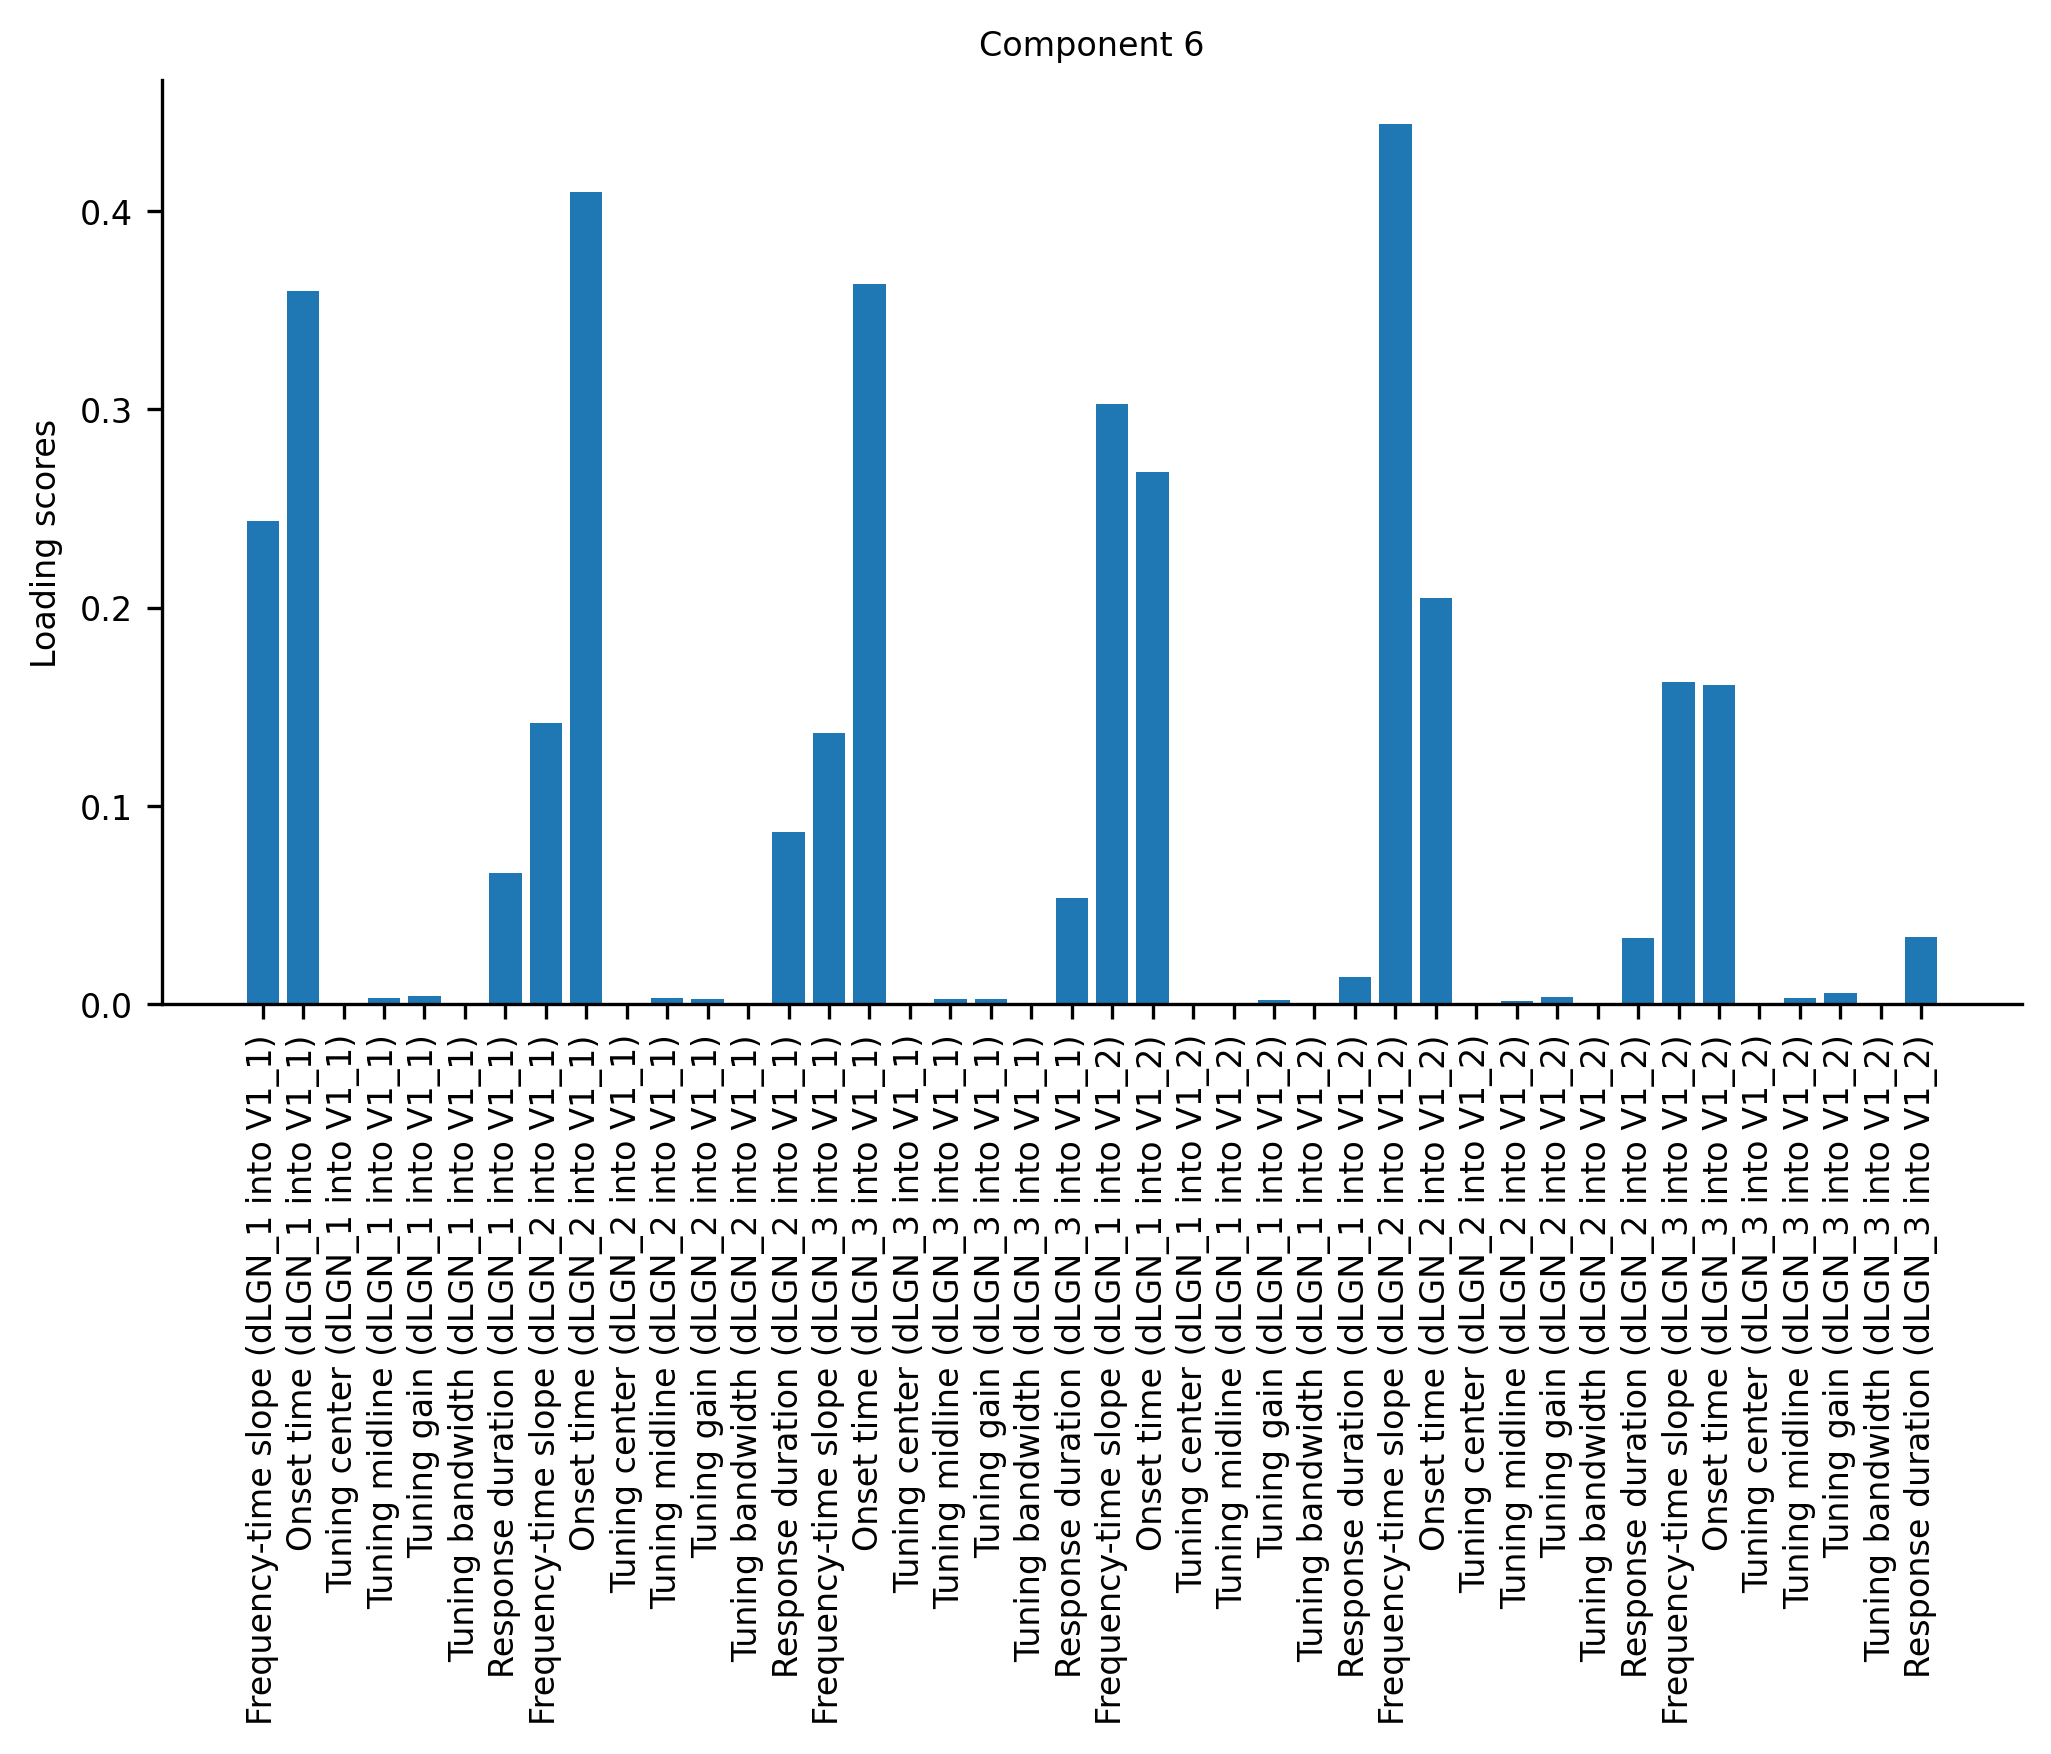

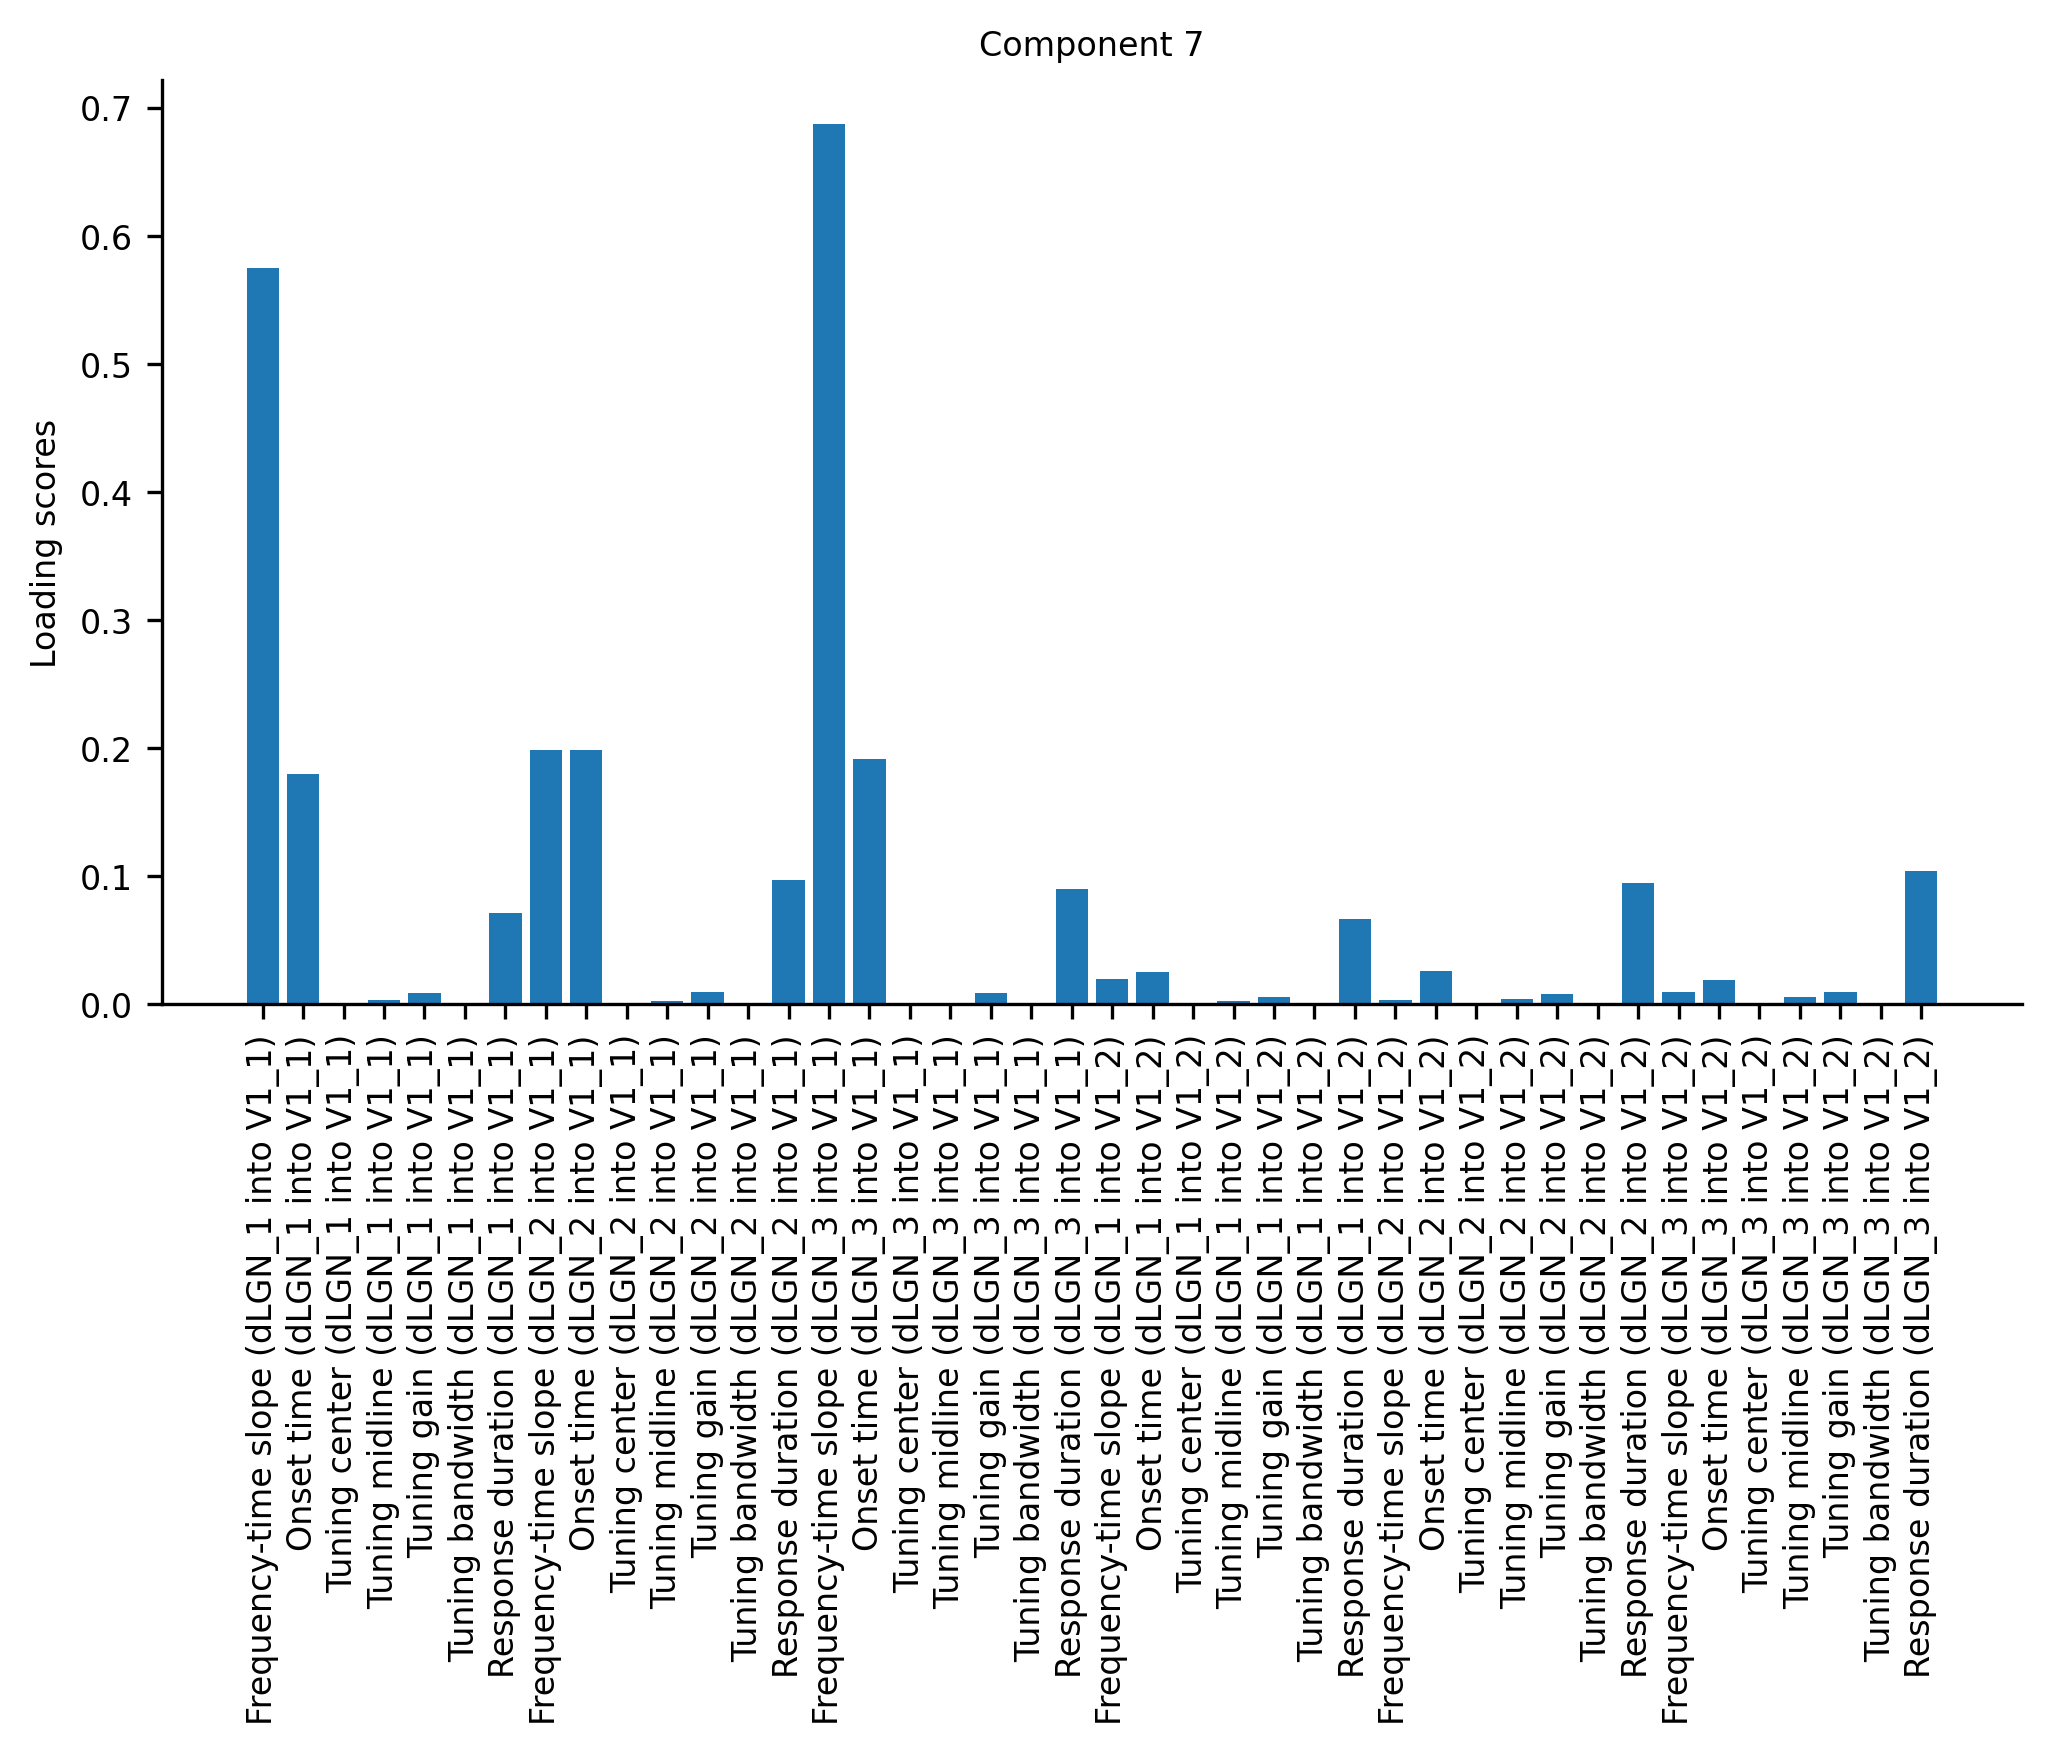

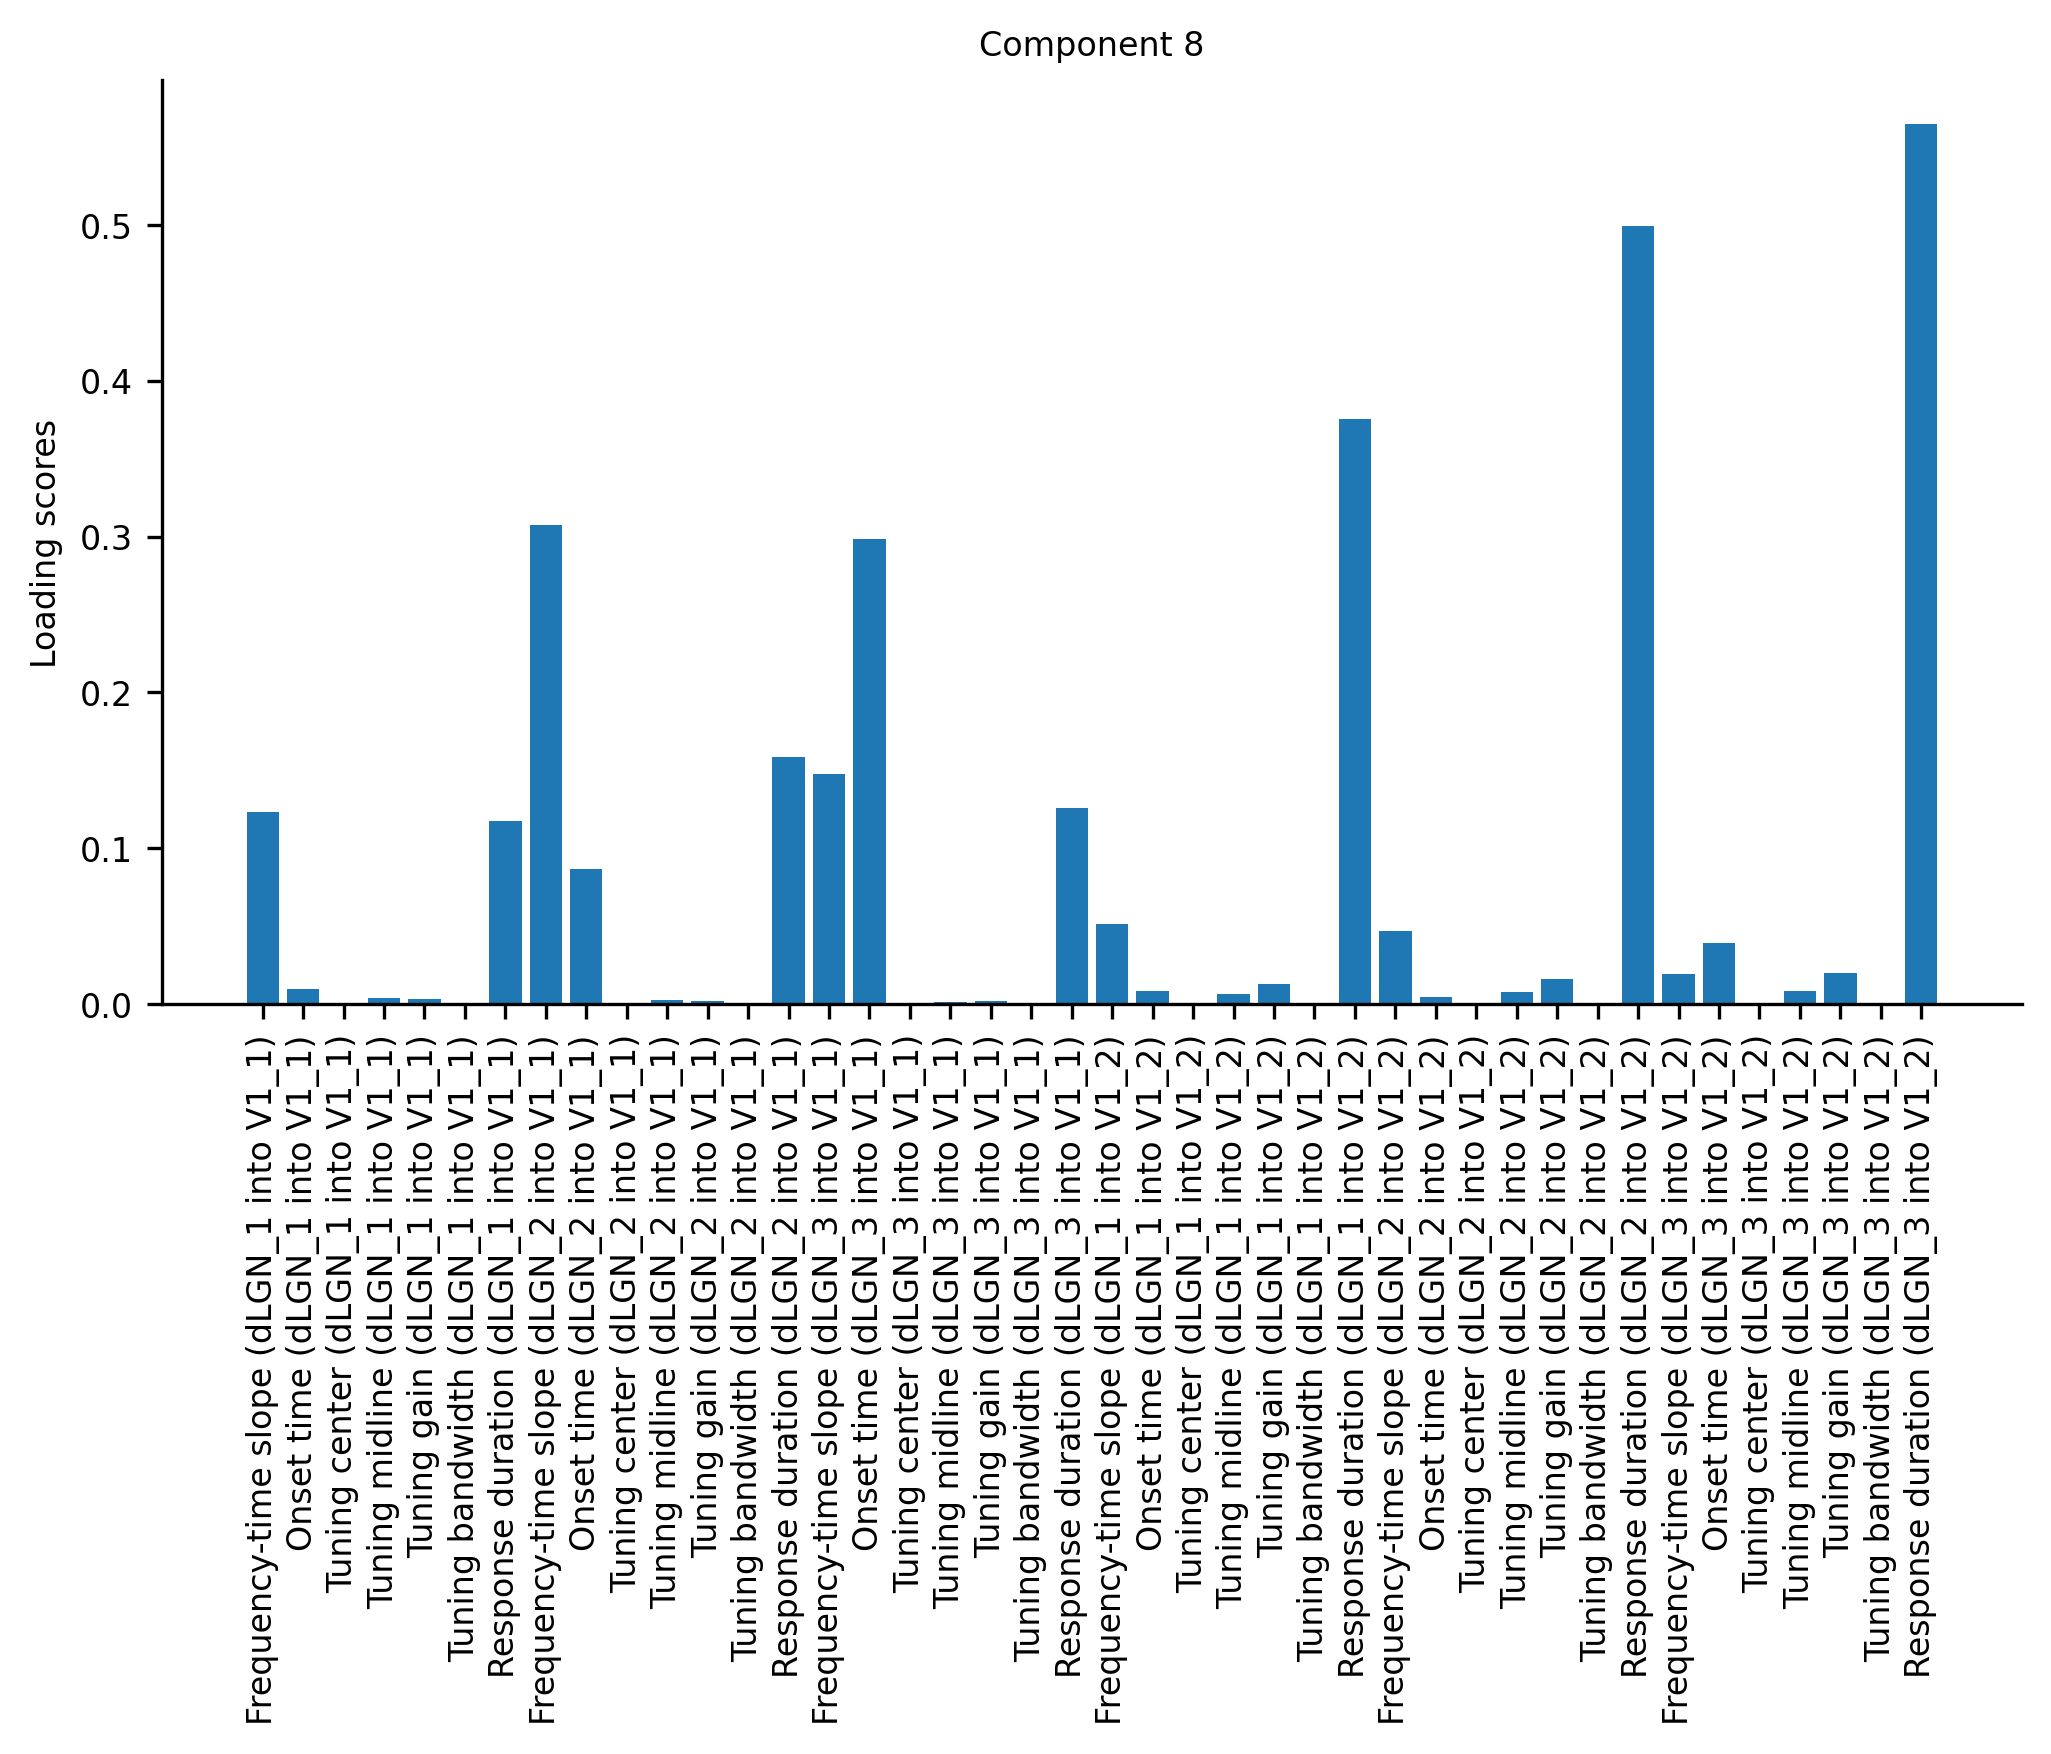

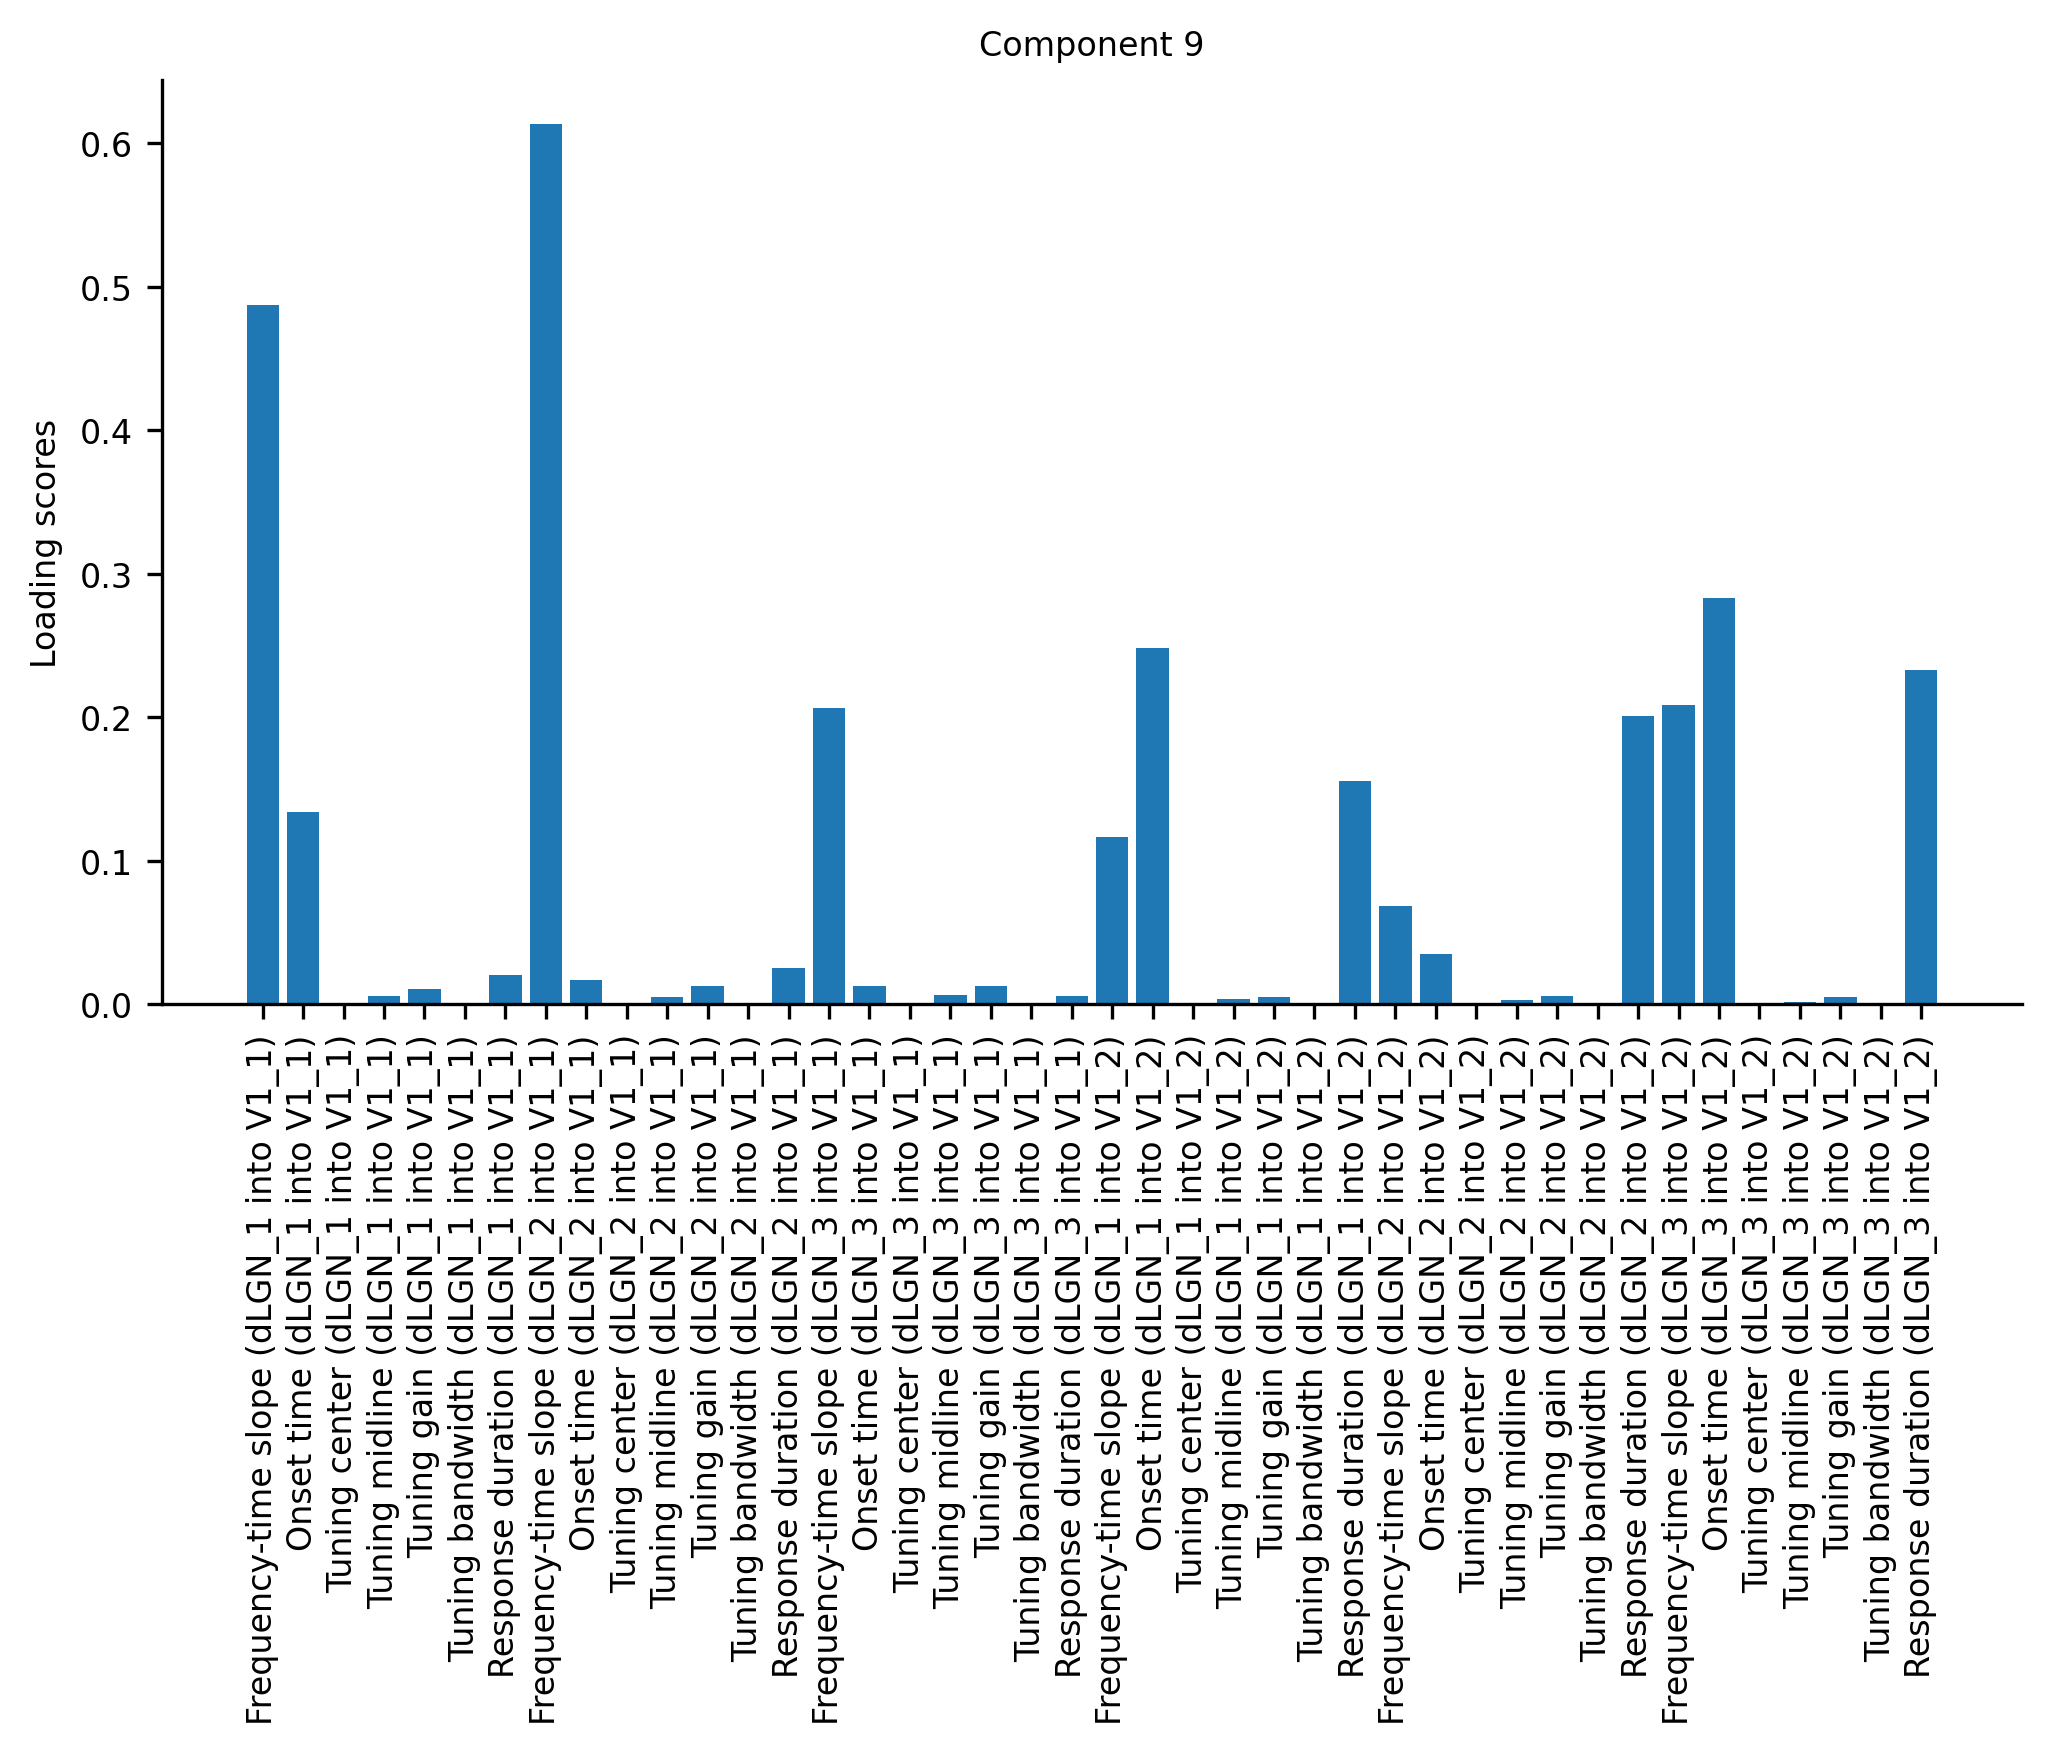

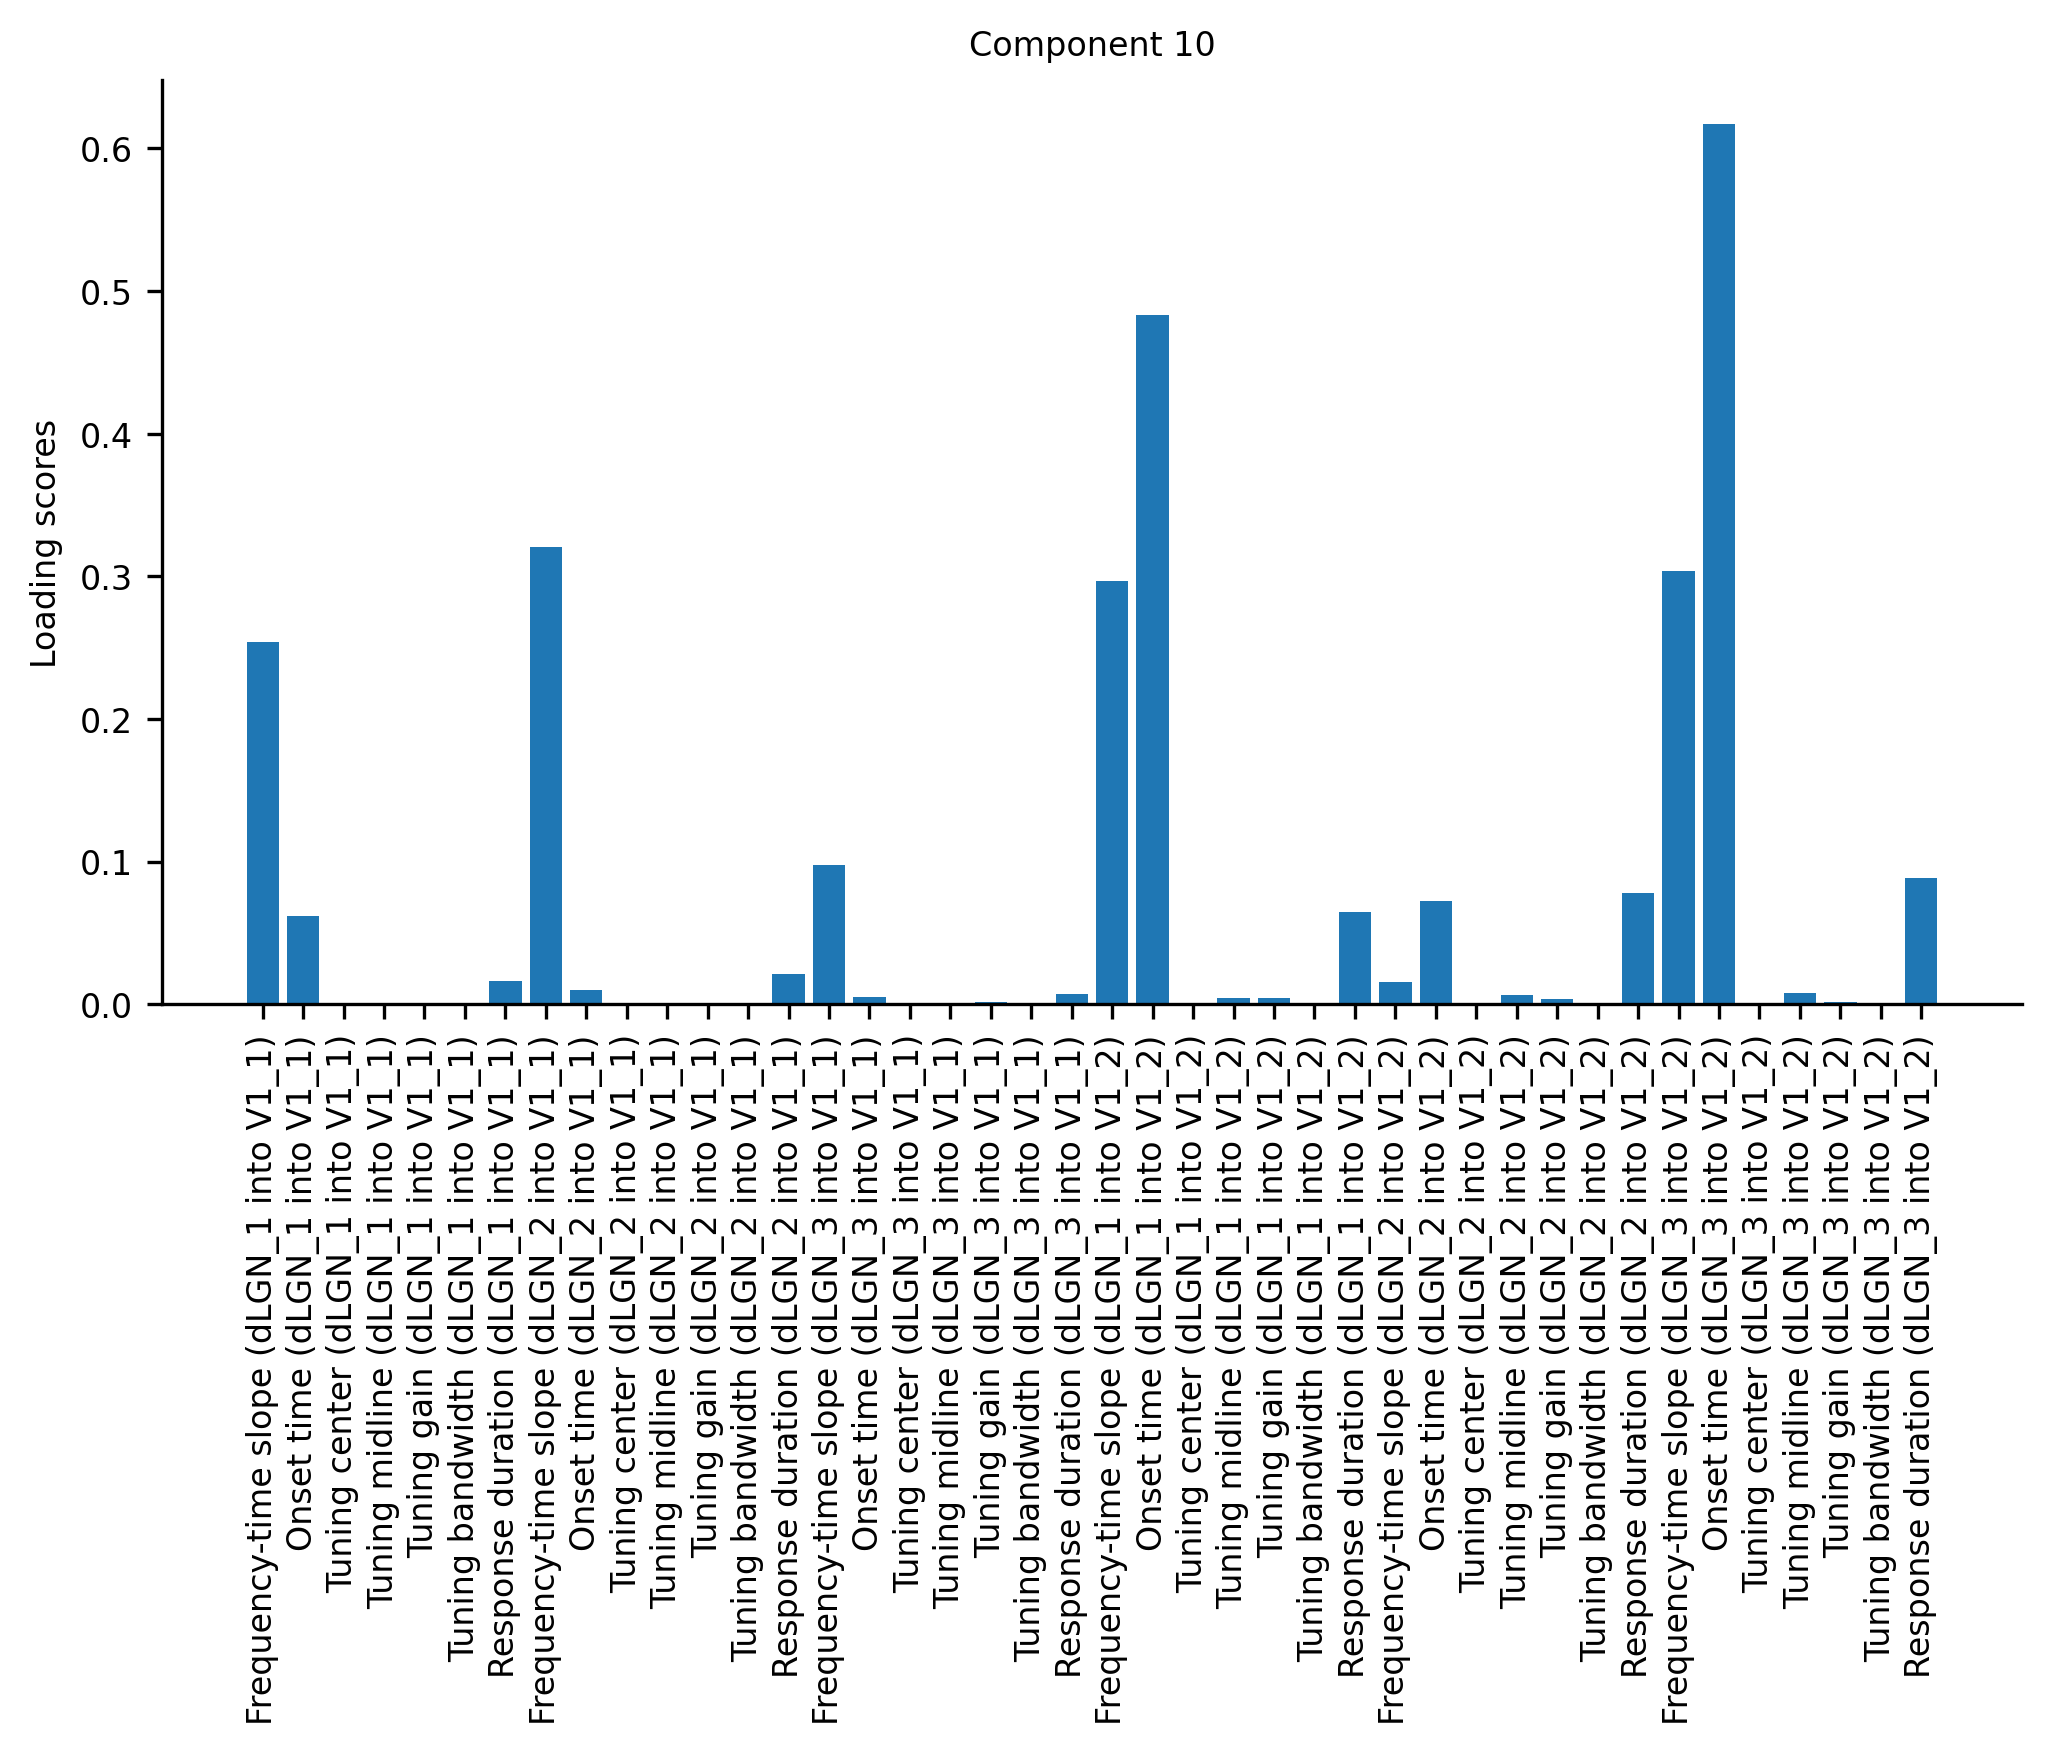

In [29]:
for i in range(10):
    fig, ax = plt.subplots(figsize = (8, 4))
    ax.tick_params(labelsize = fontsize)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.bar(np.arange(len(full_lgn_params)), np.abs(pca.components_[i]))
    ax.set_xticks(np.arange(len(full_lgn_params)))
    ax.set_xticklabels(param_names[:len(full_lgn_params)], rotation = 90)
    ax.set_ylabel("Loading scores", fontsize = fontsize)
    ax.set_title(f"Component {i+1}", fontsize = fontsize)

    figname = f'2d_model_pca_loadings_pc{i+1}_first_round.svg'
    savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
    plt.savefig(savepath, transparent = False, facecolor = 'white',
            bbox_inches = 'tight', dpi = 300)

## 2) Local perturbation restart (testing the stability of the solutions)

In [30]:
sgcc = SGCCircuit(param_bounds)

In [31]:
sgcc.load_saved_parameters(
    {x[0]:x[1] + tf.random.uniform(x[1].shape, -0.5, 0.5)
    for x in optimizer.outputs['final_epoch_params'].items()}
)

In [32]:
optimizer = Optimize(sgcc, epochs=10000, loss_threshold=0.11)

Optimizer initialized with <keras.optimizers.optimizer_v2.adam.Adam object at 0x000001E210FCE9D0>


In [33]:
loss_decay = optimizer.fit(X, Y_true)

Training step = 0, N_exploration_samples = 1000,
min_loss = 0.14148275554180145
med_loss = 0.3948650360107422
max_loss = 2.650667428970337

Training step = 100, N_exploration_samples = 1000,
min_loss = 0.10683408379554749
med_loss = 0.24407193064689636
max_loss = 1.4794964790344238

Training step = 200, N_exploration_samples = 1000,
min_loss = 0.10672265291213989
med_loss = 0.17287735641002655
max_loss = 0.8179684281349182

Training step = 300, N_exploration_samples = 1000,
min_loss = 0.10672265291213989
med_loss = 0.13930390775203705
max_loss = 0.482465922832489

Training step = 400, N_exploration_samples = 1000,
min_loss = 0.10672265291213989
med_loss = 0.12099967151880264
max_loss = 0.47860556840896606

Training step = 500, N_exploration_samples = 1000,
min_loss = 0.10672265291213989
med_loss = 0.11159080266952515
max_loss = 0.4763457179069519

Training step = 600, N_exploration_samples = 1000,
min_loss = 0.10672265291213989
med_loss = 0.1095338985323906
max_loss = 0.474571675062179

In [34]:
optimizer.save_state('sgcc_mop_3_8_26', write=True)

In [35]:
res = optimizer.outputs
param_history = res['param_history']

In [36]:
loss_decay = res['loss_decay']
last_epoch = loss_decay[-1]
best = np.where(last_epoch == last_epoch.min())[0][0]
print(f"Index of best parameters: {best}, loss = {last_epoch[best]}")

Index of best parameters: 296, loss = 0.10675048828125


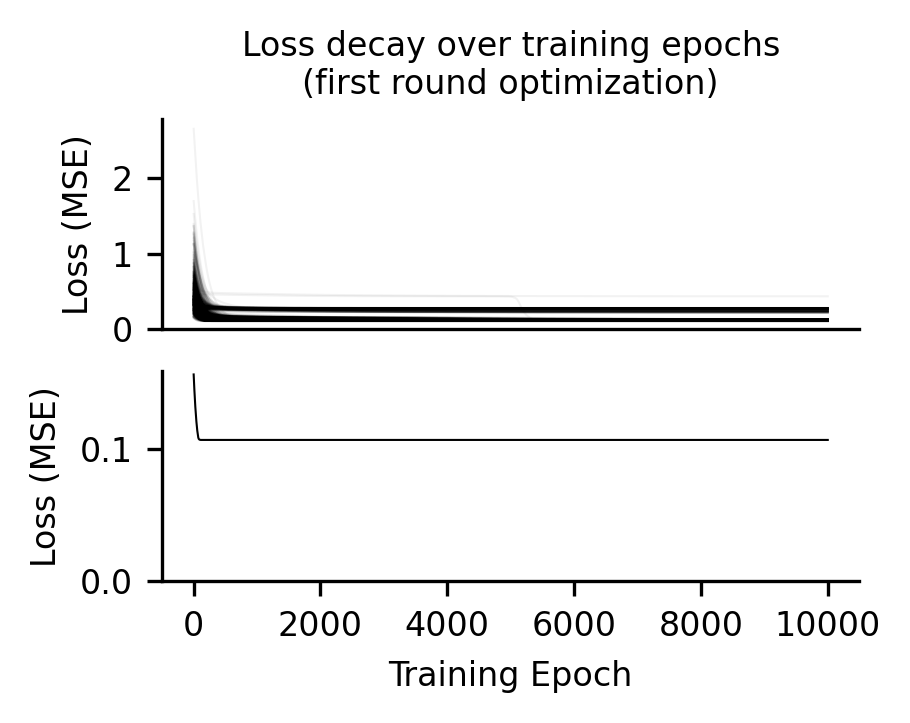

In [37]:
fig, ax = plt.subplots(2, figsize = (3,2))

for i, decay in enumerate(loss_decay.T):
    ax[0].plot(decay, alpha = 0.05, color = 'black', linewidth = linewidth)

ax[1].set_xlabel("Training Epoch", fontsize = fontsize)
ax[0].set_ylabel("Loss (MSE)", fontsize = fontsize)
ax[0].set_ylim(0,)
ax[0].set_xticks([])

ax[1].set_ylabel("Loss (MSE)", fontsize = fontsize)
ax[1].plot(loss_decay[:,best], alpha = 1, color = 'black', linewidth = linewidth)
ax[1].set_ylim(0.)
ax[0].set_title("Loss decay over training epochs\n(first round optimization)", fontsize = fontsize)

for i in range(2):
    ax[i].tick_params(labelsize = fontsize)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

figname = '2d_model_loss_decay_reopt.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

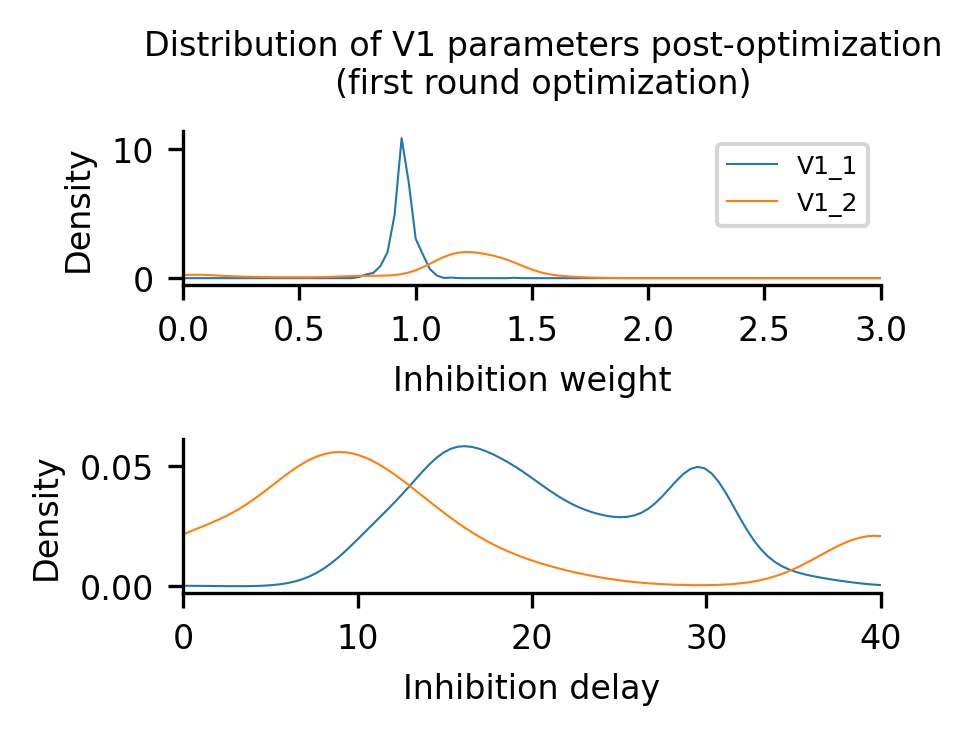

In [38]:
fig, ax = plt.subplots(2,1, figsize = (3, 2))

for i in range(2):
    i_ = np.abs(i-1)
    for u in range(2):
        x = np.linspace(
            list(param_bounds.values())[-1-i][0],
            list(param_bounds.values())[-1-i][1],
            100
        )
        data = param_history['V1_params'][:,-1,u,0,i_,0,0]
        kde = gaussian_kde(data)
        y = kde(x)

        ax[i].plot(x,y, label = f'V1_{u+1}', linewidth = linewidth)
        ax[i].set_xlim(
            list(param_bounds.values())[-1-i][0],
            list(param_bounds.values())[-1-i][1]
        )
        ax[i].set_ylabel("Density", fontsize = fontsize)
        ax[i].spines['top'].set_visible(False)
        ax[i].spines['right'].set_visible(False)
        ax[i].tick_params(labelsize = fontsize)

ax[0].set_xlabel('Inhibition weight', fontsize = fontsize)
ax[1].set_xlabel('Inhibition delay', fontsize = fontsize)
ax[0].legend(fontsize = 6)
fig.subplots_adjust(hspace=1)
plt.suptitle("Distribution of V1 parameters post-optimization\n(first round optimization)", fontsize = fontsize, x = 0.525, y = 1.05)

figname = '2d_model_v1_param_density_func_reopt.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

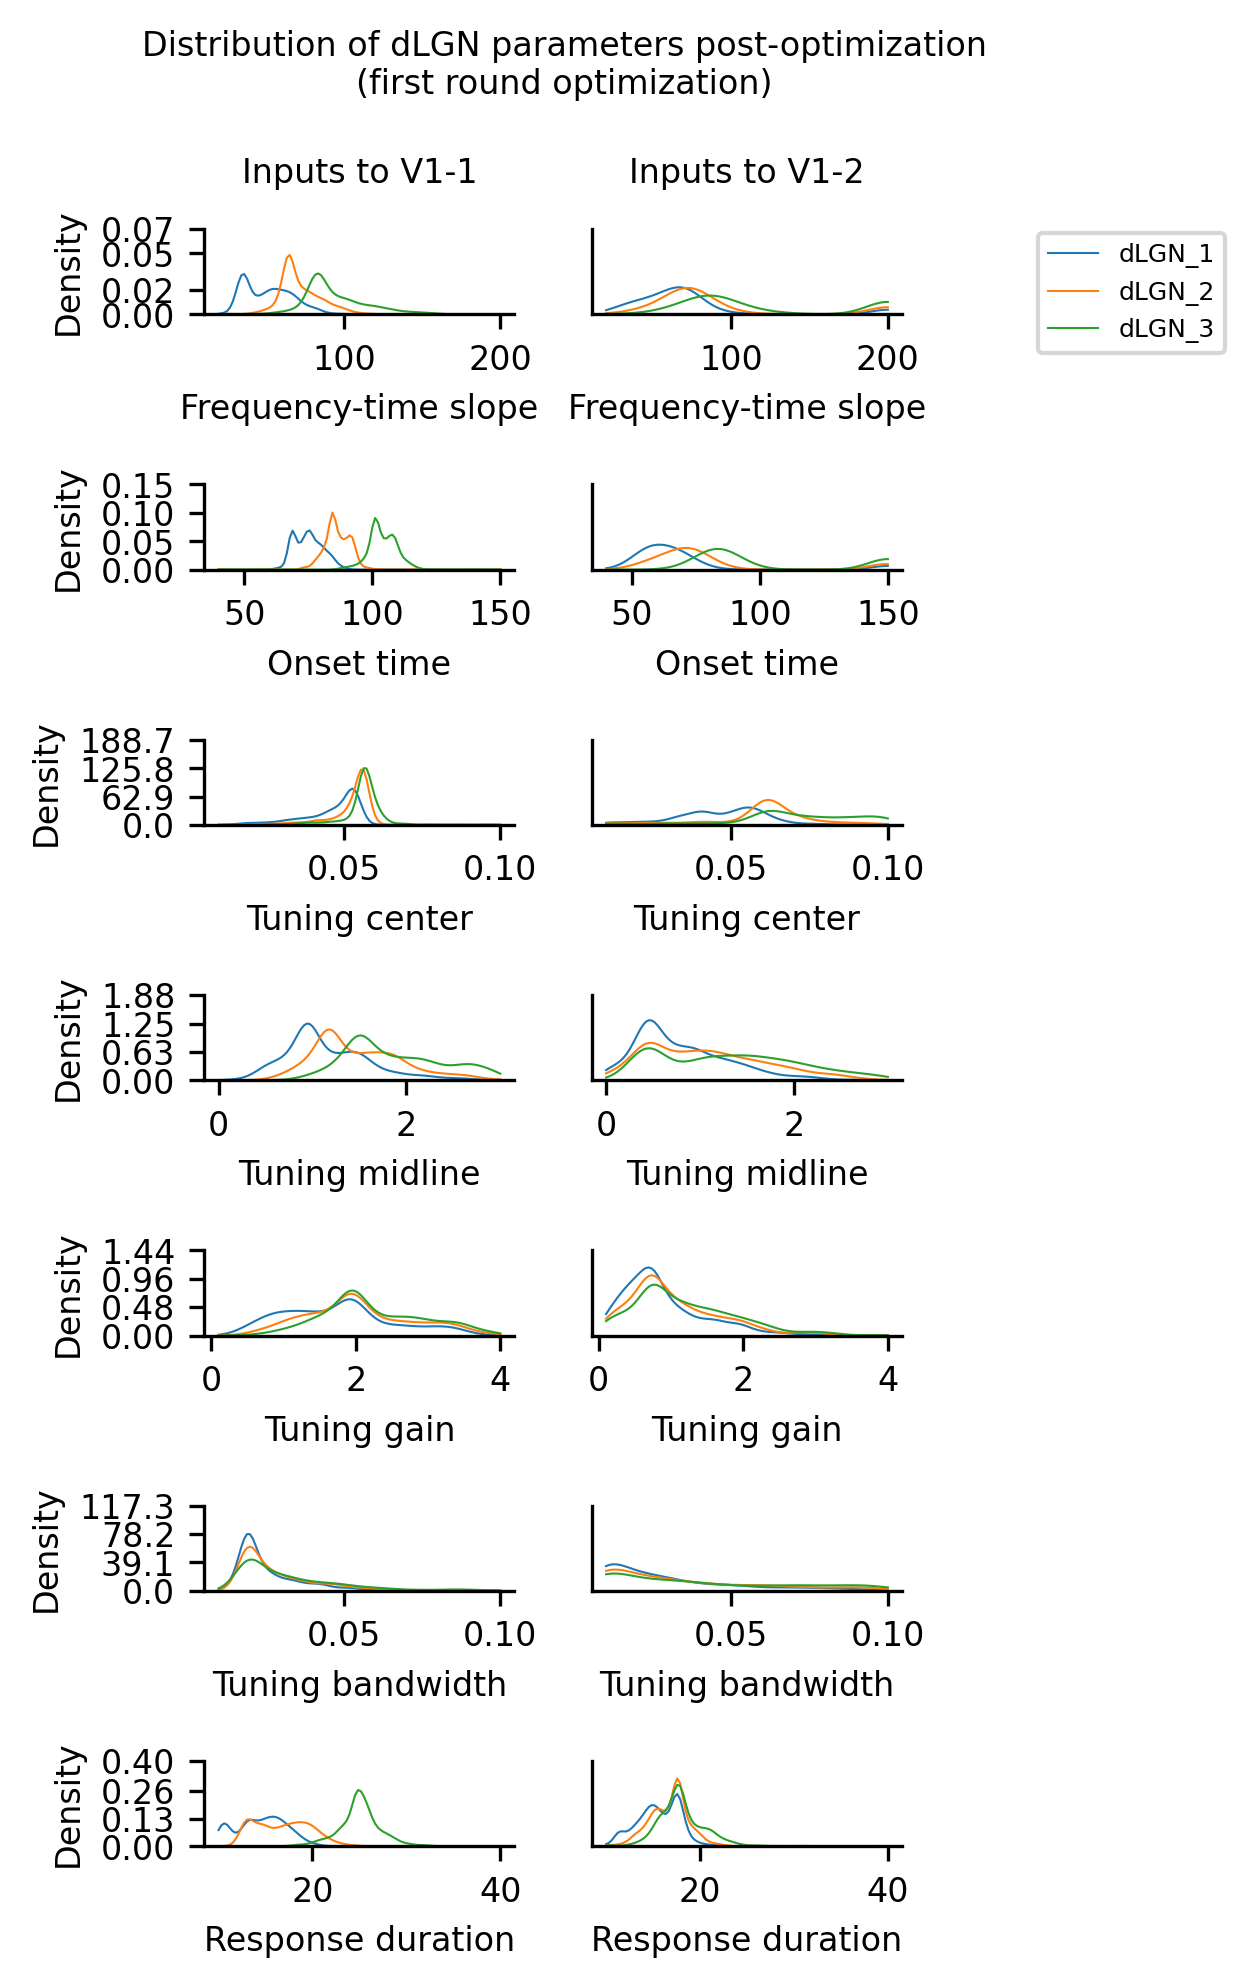

In [39]:
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Onset time',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Response duration'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            data = param_history['dLGN_params'][:,-1,u,i,row,0,0]
            x = np.linspace(
                list(param_bounds.values())[:7][row][0],
                list(param_bounds.values())[:7][row][1], 
                100
            )
            kde = gaussian_kde(data)
            y = kde(x)

            ymax.append(y.max())
            
            ax[row, u].plot(x, y, label = neuron_labels[i], linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("Density", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, np.max(ymax)+np.max(ymax)*0.25)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.linspace(0, np.max(ymax)+np.max(ymax)*0.5, 4).round(2))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.4,1.1))
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Distribution of dLGN parameters post-optimization\n(first round optimization)", fontsize = fontsize, x = 0.525, y = 0.975)

figname = '2d_model_dlgn_param_density_func_reopt.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

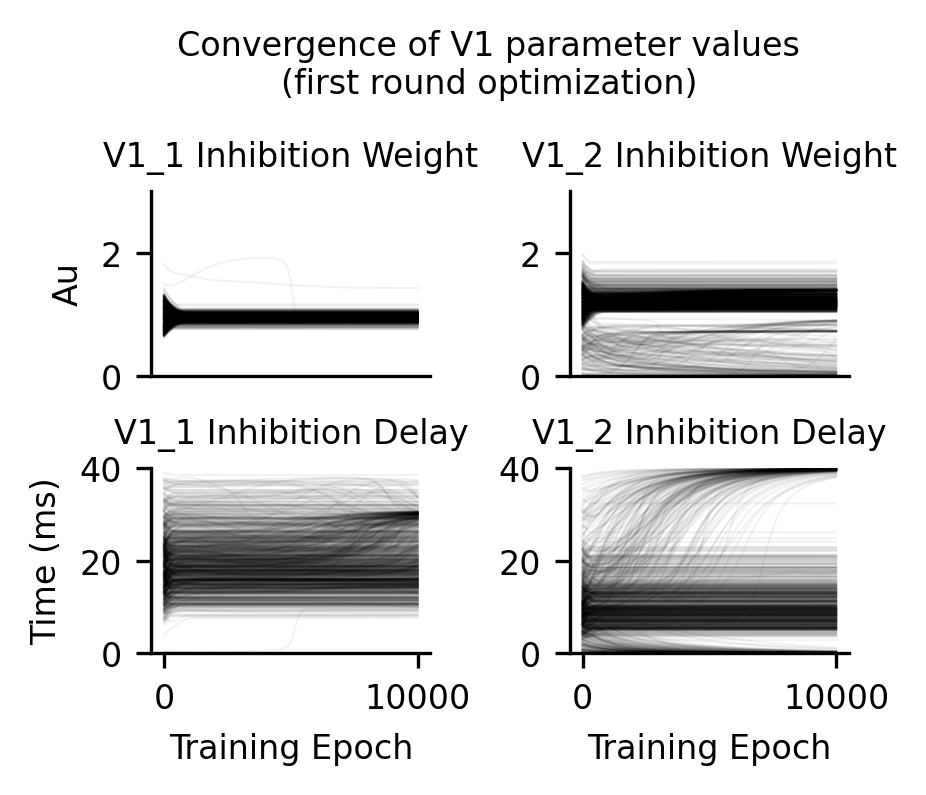

In [40]:
## inhibition weight::inhibition delay

fig, ax = plt.subplots(2,2, figsize = (3,2))

inh_w = 1
v1_n = 0 

for row in range(2):
    for col in range(2):
        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

ax[0,0].plot(
    param_history['V1_params'][:,:,v1_n,0,inh_w,0,0].T,
    linewidth=linewidth,
    alpha=0.05,
    color = 'black'
)

# 
v1_n = 1
ax[0,1].plot(
    param_history['V1_params'][:,:,v1_n,0,inh_w,0,0].T,
    linewidth=linewidth,
    alpha=0.05,
    color = 'black'
)

# a0
inh_d = 0
v1_n = 0
ax[1,0].plot(
    param_history['V1_params'][:,:,v1_n,0,inh_d,0,0].T,
    linewidth=linewidth,
    alpha=0.05,
    color = 'black'
)

# a1
v1_n = 1
ax[1,1].plot(
    param_history['V1_params'][:,:,v1_n,0,inh_d,0,0].T,
    linewidth=linewidth,
    alpha=0.05,
    color = 'black'
)

ax[0,0].set_ylim(0,3)
ax[0,0].set_title("V1_1 Inhibition Weight", fontsize = fontsize)
ax[0,0].set_xticks([])
ax[0,0].set_ylabel("Au", fontsize = fontsize)

ax[0,1].set_ylim(0,3)
ax[0,1].set_title("V1_2 Inhibition Weight", fontsize = fontsize)
ax[0,1].set_xticks([])

ax[1,0].set_ylim(0,40)
ax[1,0].set_title("V1_1 Inhibition Delay", fontsize = fontsize)
ax[1,0].set_ylabel("Time (ms)", fontsize = fontsize)
ax[1,0].set_xlabel("Training Epoch", fontsize = fontsize)

ax[1,1].set_ylim(0,40)
ax[1,1].set_title("V1_2 Inhibition Delay", fontsize = fontsize)
ax[1,1].set_xlabel("Training Epoch", fontsize = fontsize)
fig.subplots_adjust(wspace=0.5, hspace=0.5)
plt.suptitle("Convergence of V1 parameter values\n(first round optimization)", fontsize = fontsize, y = 1.15)

figname = '2d_model_v1_param_convergence_reopt.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

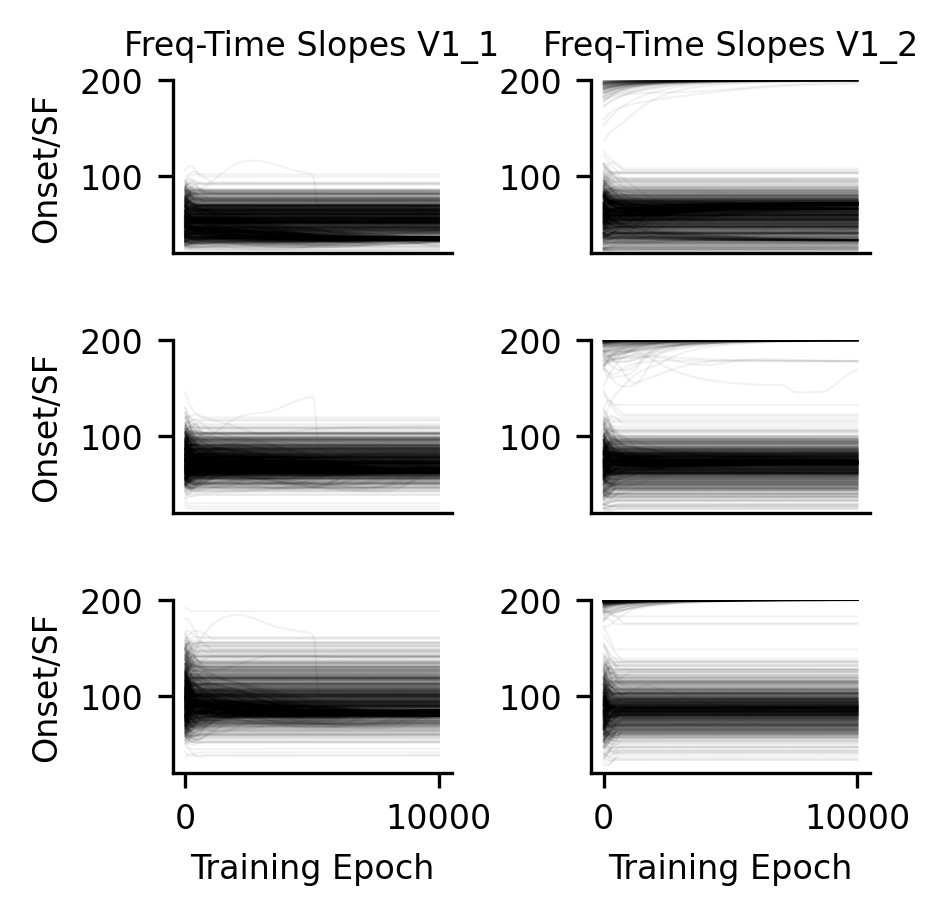

In [41]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 0

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Freq-Time Slopes V1_{i+1}", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("Onset/SF", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(20,200)
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

figname = '2d_model_fts_convergence_reopt.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

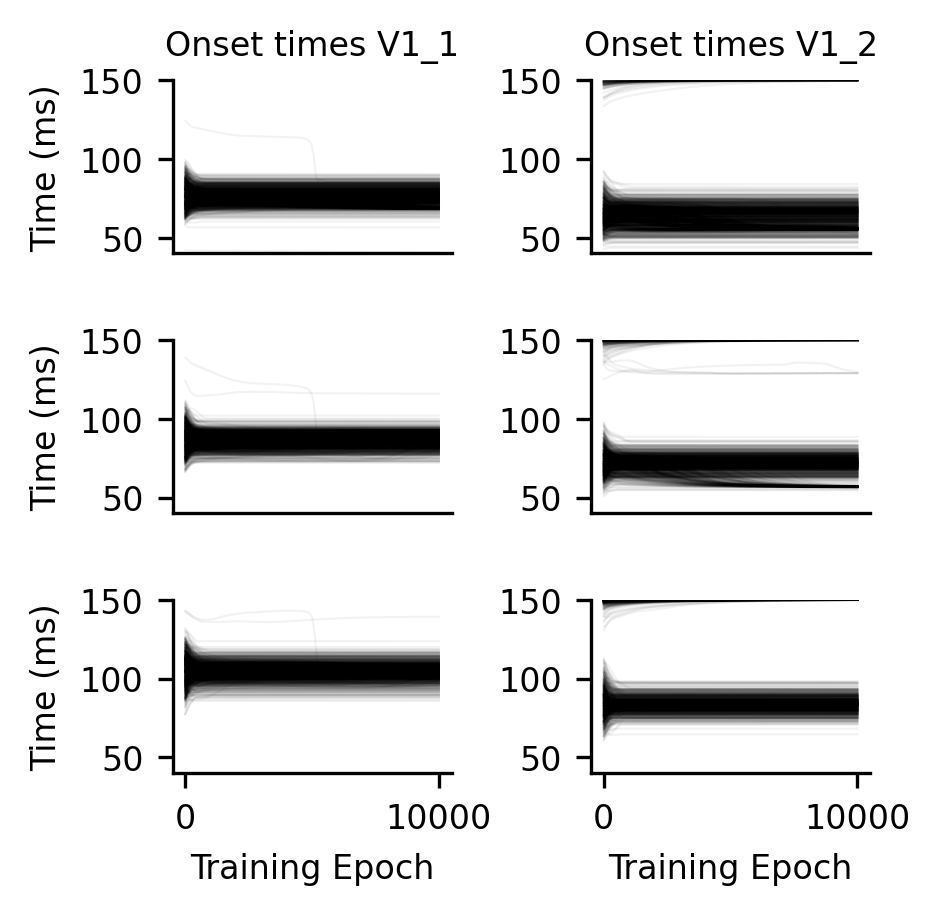

In [42]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 1

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Onset times V1_{i+1}", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("Time (ms)", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(40,150)
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

figname = '2d_model_t_convergence_reopt.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

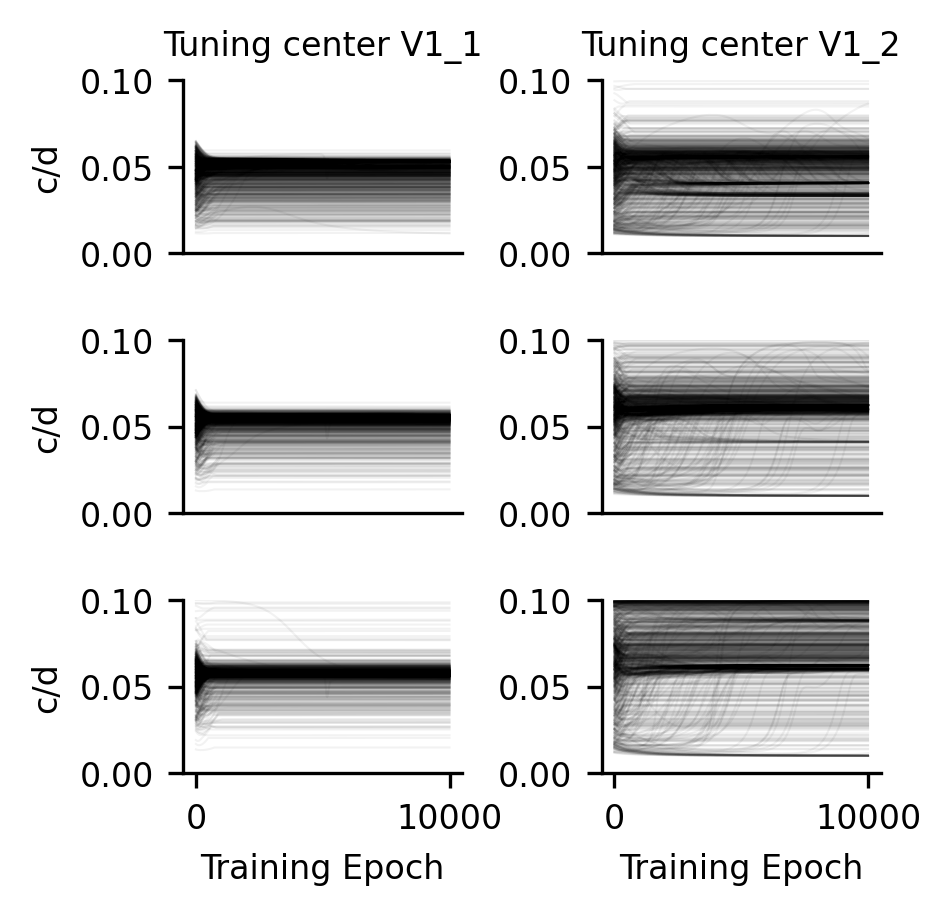

In [43]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 2

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Tuning center V1_{i+1}", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("c/d", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(0,0.1)
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

figname = '2d_model_ampc_convergence_reopt.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

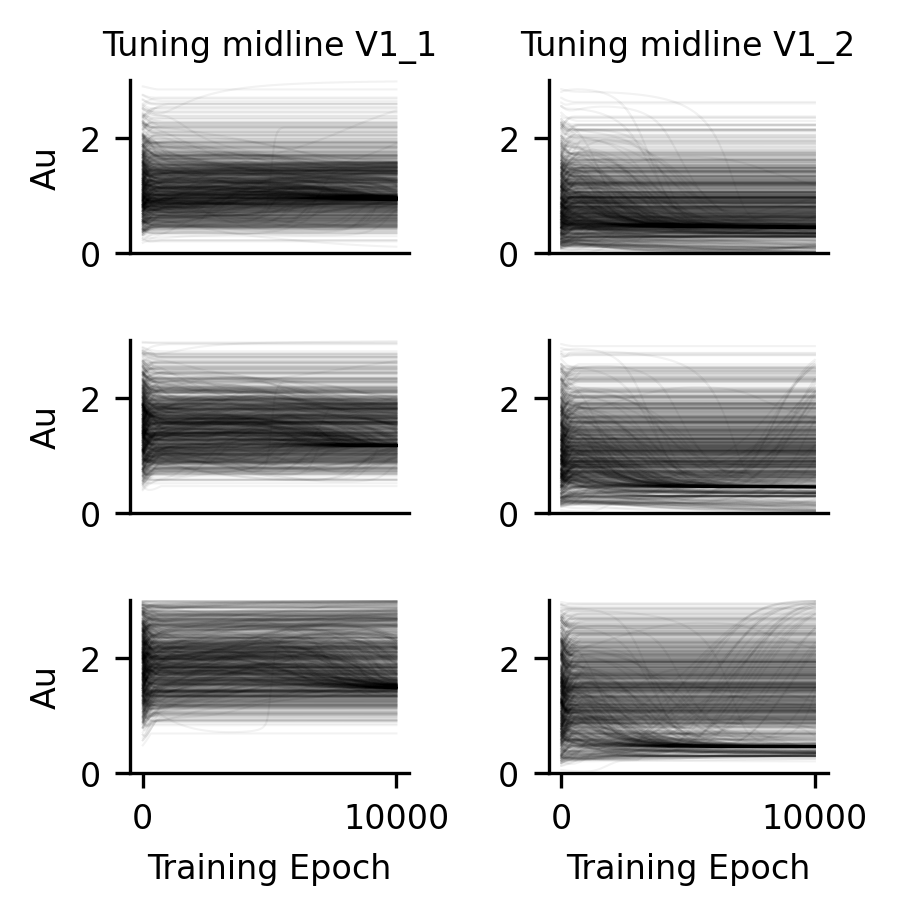

In [44]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 3

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Tuning midline V1_{i+1}", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("Au", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(0,3)
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

figname = '2d_model_ampm_convergence_reopt.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

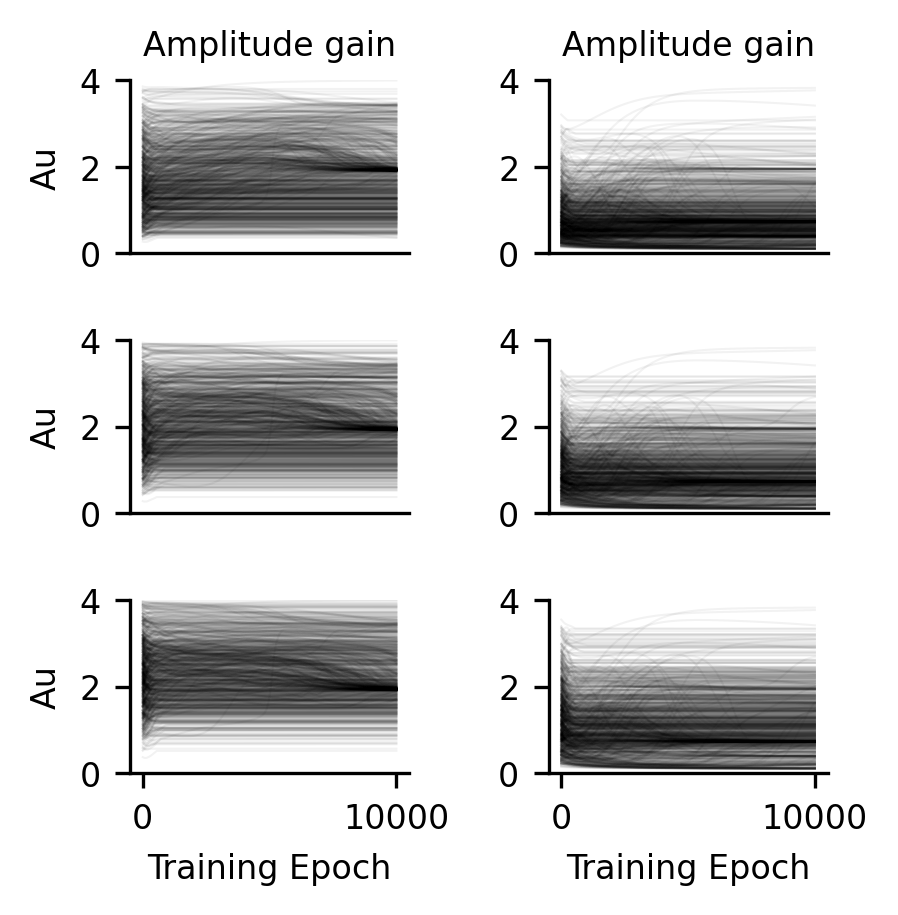

In [45]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 4

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Amplitude gain", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("Au", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(0,4)
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

figname = '2d_model_ampg_convergence_reopt.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

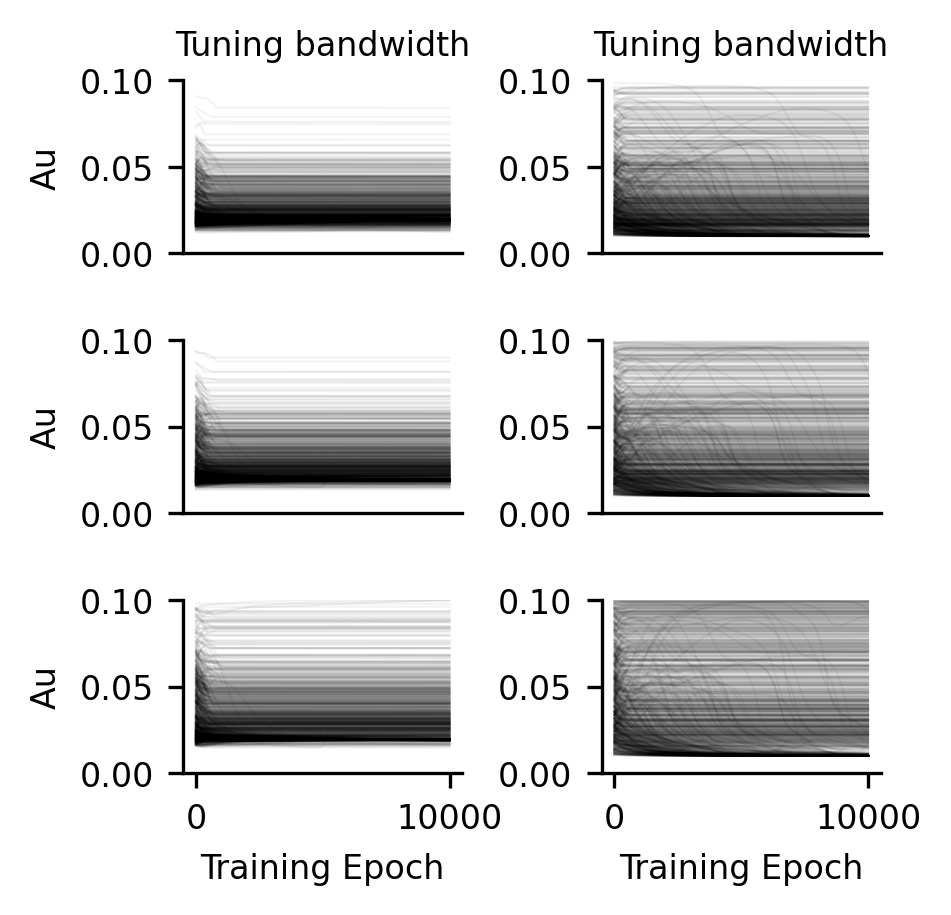

In [46]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 5

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Tuning bandwidth", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("Au", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(0,0.1)
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

figname = '2d_model_ampw_convergence_reopt.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

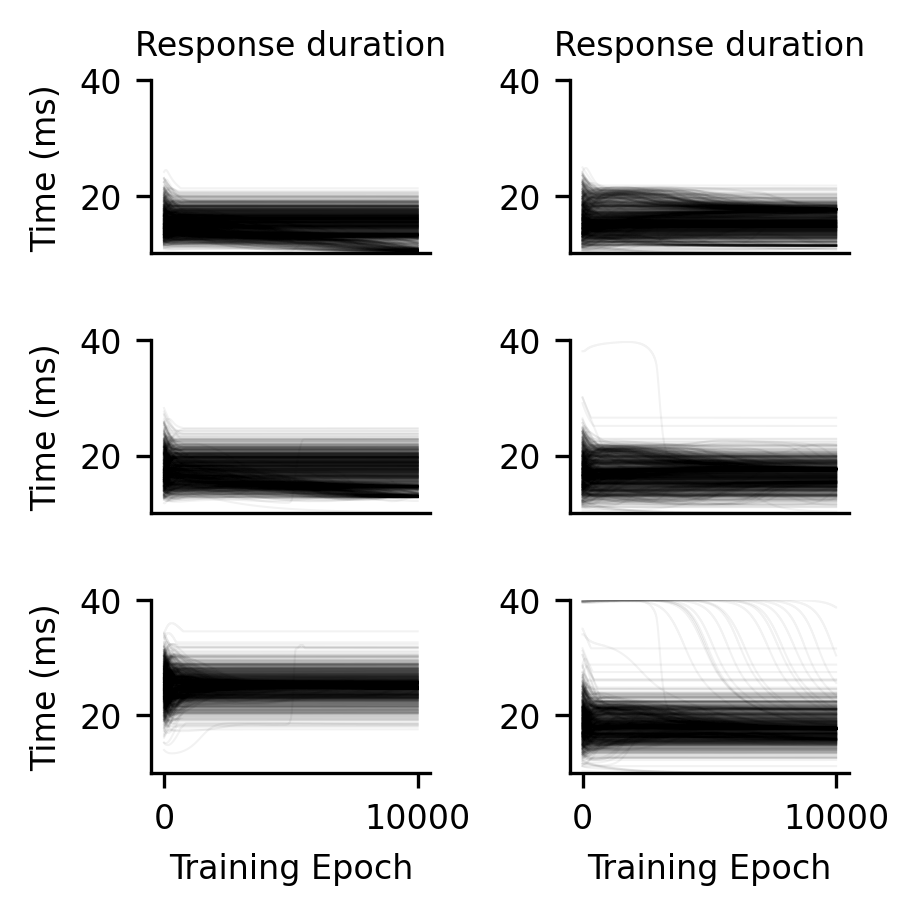

In [47]:
fig, ax = plt.subplots(3,2, figsize = (3,3))
norm = plt.Normalize(0, 1)

param = 6

for col in range(2):
    for row in range(3):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        data = param_history['dLGN_params'][:,:,col,row,param,0,0].T
        ax[row,col].plot(
        param_history['dLGN_params'][:,:,col,row,param,0,0].T,
            linewidth=linewidth,
            alpha=0.05,
            color='black'
        )

for i in range(2):
    ax[0,i].set_title(f"Response duration", fontsize = fontsize)
for i in range(3):
    ax[i,0].set_ylabel("Time (ms)", fontsize = fontsize)
for row in range(2):
    for col in range(2):
        ax[row,col].set_xticks([])
for row in range(3):
    for col in range(2):
        ax[row,col].set_ylim(10,40)
for i in range(2):
    ax[2,i].set_xlabel("Training Epoch", fontsize = fontsize)

fig.subplots_adjust(wspace=0.5, hspace=0.5)

figname = '2d_model_d_convergence_reopt.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

In [48]:
res = param_history['dLGN_params'].squeeze()
print(res.shape[2:])
n_samples, n_epochs = res.shape[:2]
n_params = np.prod(res.shape[2:])# + np.prod(r2.shape[2:])

res = res.reshape(res.shape[0] * res.shape[1], np.prod(res.shape[2:]))

(2, 3, 7)


In [49]:
pca = PCA() # all epochs included
res_transformed_pca = pca.fit_transform(res).reshape(n_samples, n_epochs, n_params)

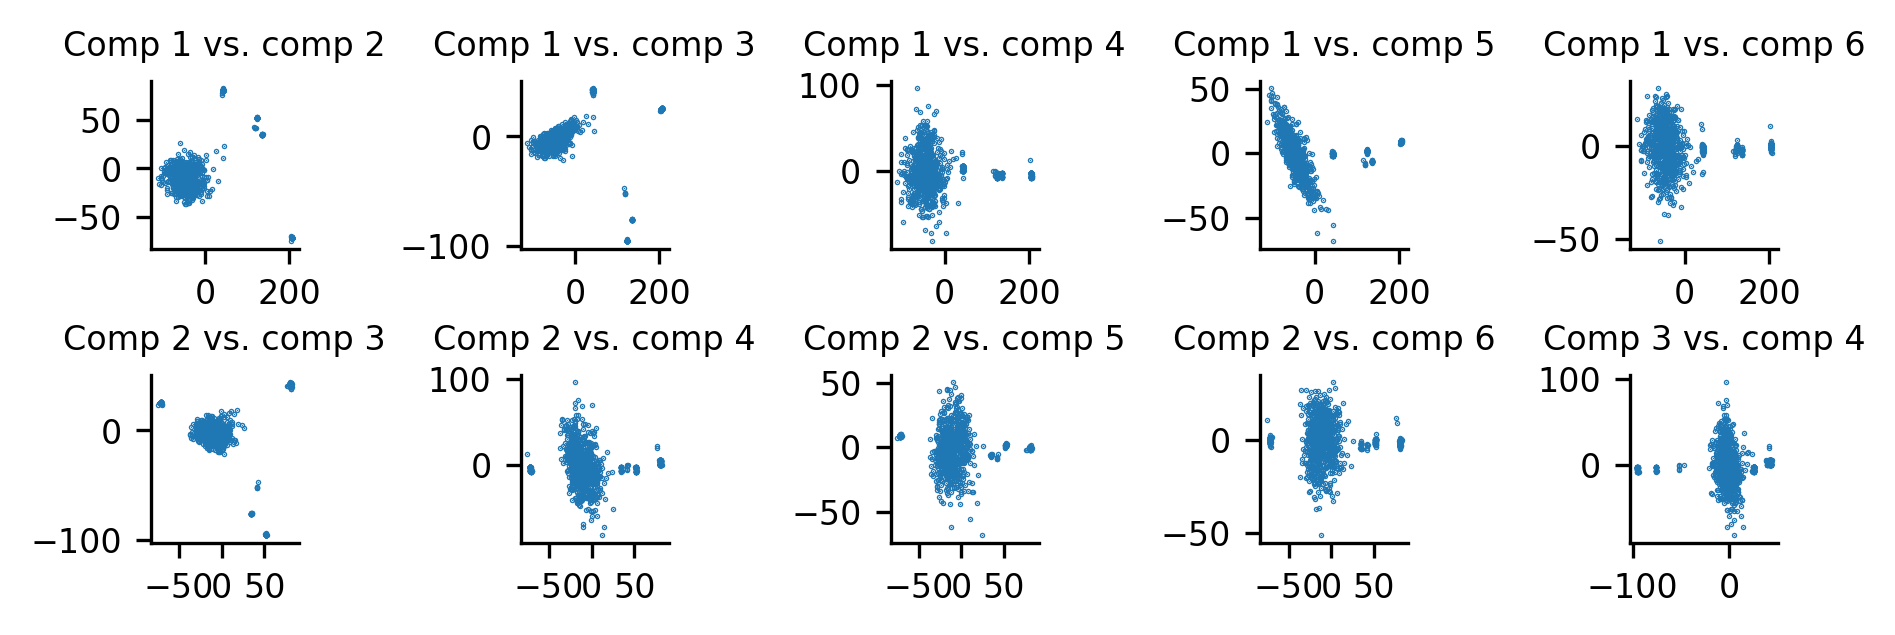

In [50]:
fig, ax = plt.subplots(2,5, figsize = (7,2))

comp_pairs = (list(combinations(np.arange(6), 2)))
i = 0
for row in range(2):
    for col in range(5):

        ax[row, col].spines['top'].set_visible(False)
        ax[row, col].spines['right'].set_visible(False)
        ax[row, col].tick_params(labelsize = fontsize)

        c0, c1 = comp_pairs[i]
        ax[row, col].scatter(res_transformed_pca[:,-1,c0], res_transformed_pca[:,-1,c1], s = 0.1) # last epoch
        ax[row, col].set_title(f"Comp {c0+1} vs. comp {c1+1}", fontsize = fontsize)
        i+=1

fig.subplots_adjust(hspace = 0.75, wspace = 1.5)
figname = '2d_model_pcaprojection_reopt.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
plt.savefig(savepath, transparent = False, facecolor = 'white',
           bbox_inches = 'tight', dpi = 300)

In [51]:
lgn_params = [
    'Frequency-time slope',
    'Onset time',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Response duration'
]

v1_params = [
    'Inhibition delay',
    'Inhibition weight'
]

lgn_units = [
    'dLGN_1 into V1_1',
    'dLGN_2 into V1_1',
    'dLGN_3 into V1_1',
    'dLGN_1 into V1_2',
    'dLGN_2 into V1_2',
    'dLGN_3 into V1_2',
]

v1_units = [
    'V1_1',
    'V1_2'
]

full_lgn_params = []
for unit in lgn_units:
    for param in lgn_params:
        full_lgn_params.append(f"{param} ({unit})")

full_v1_params = []
for unit in v1_units:
    for param in v1_params:
        full_v1_params.append(f"{param} ({unit})")
        
param_names = full_lgn_params+full_v1_params

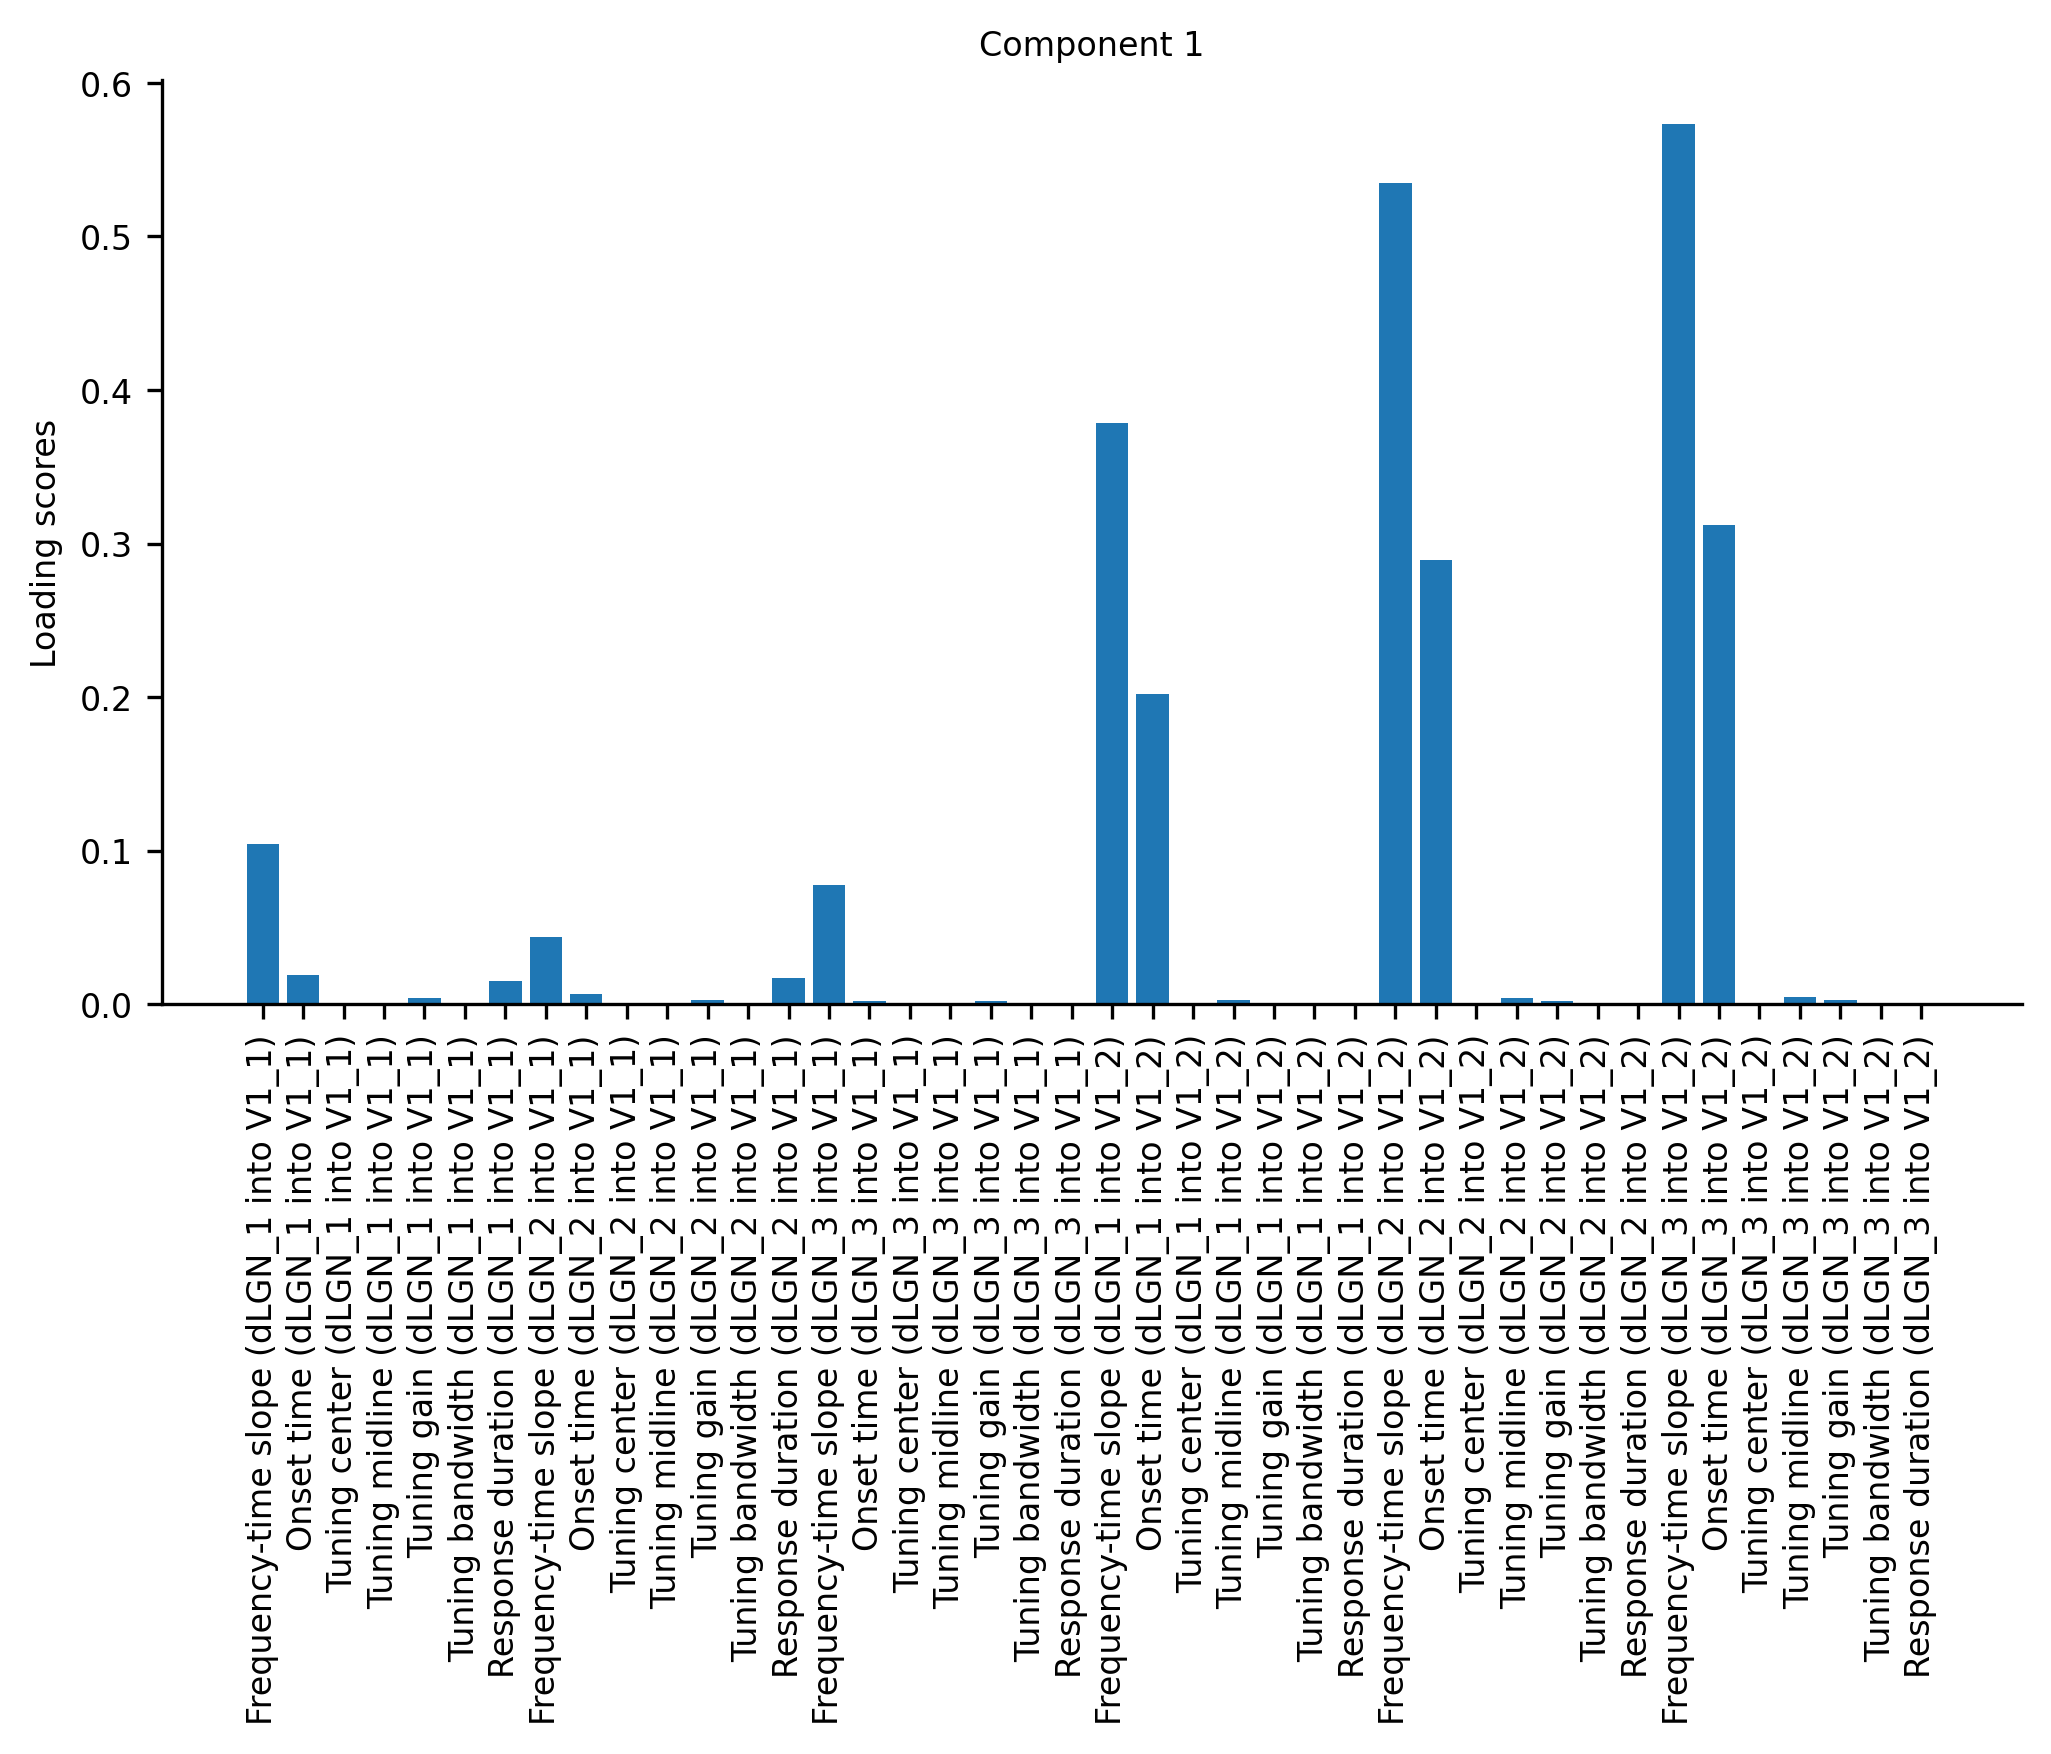

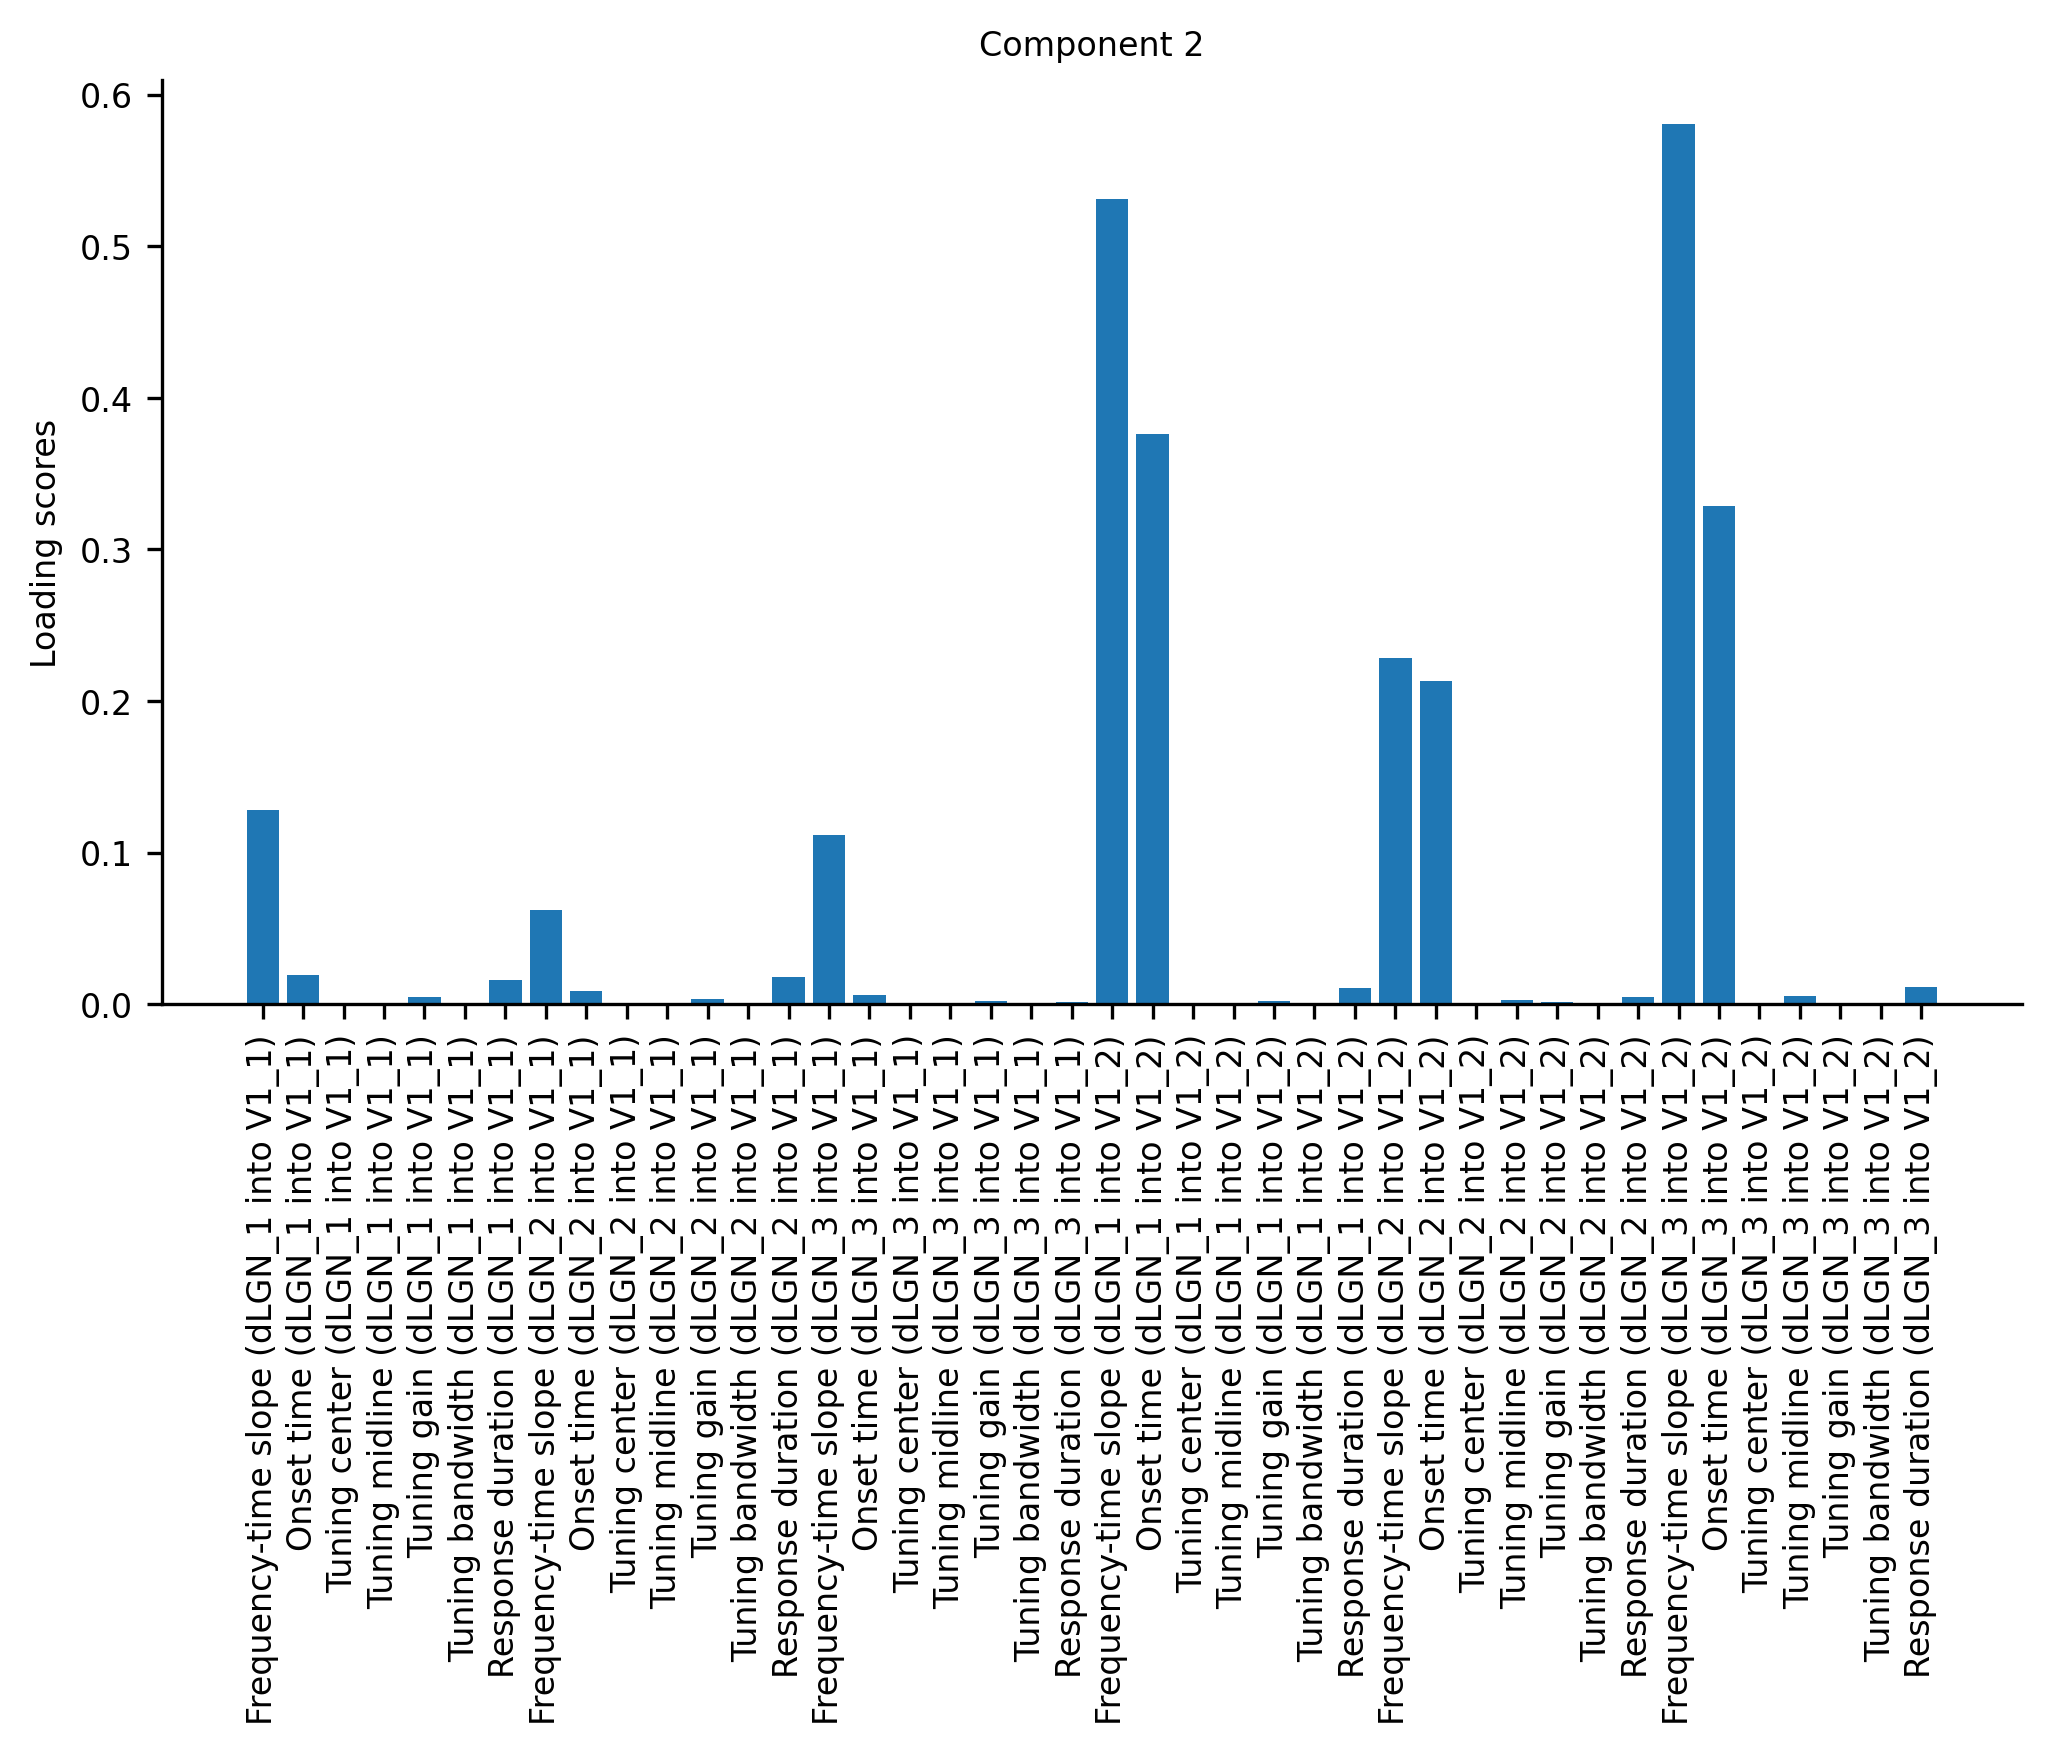

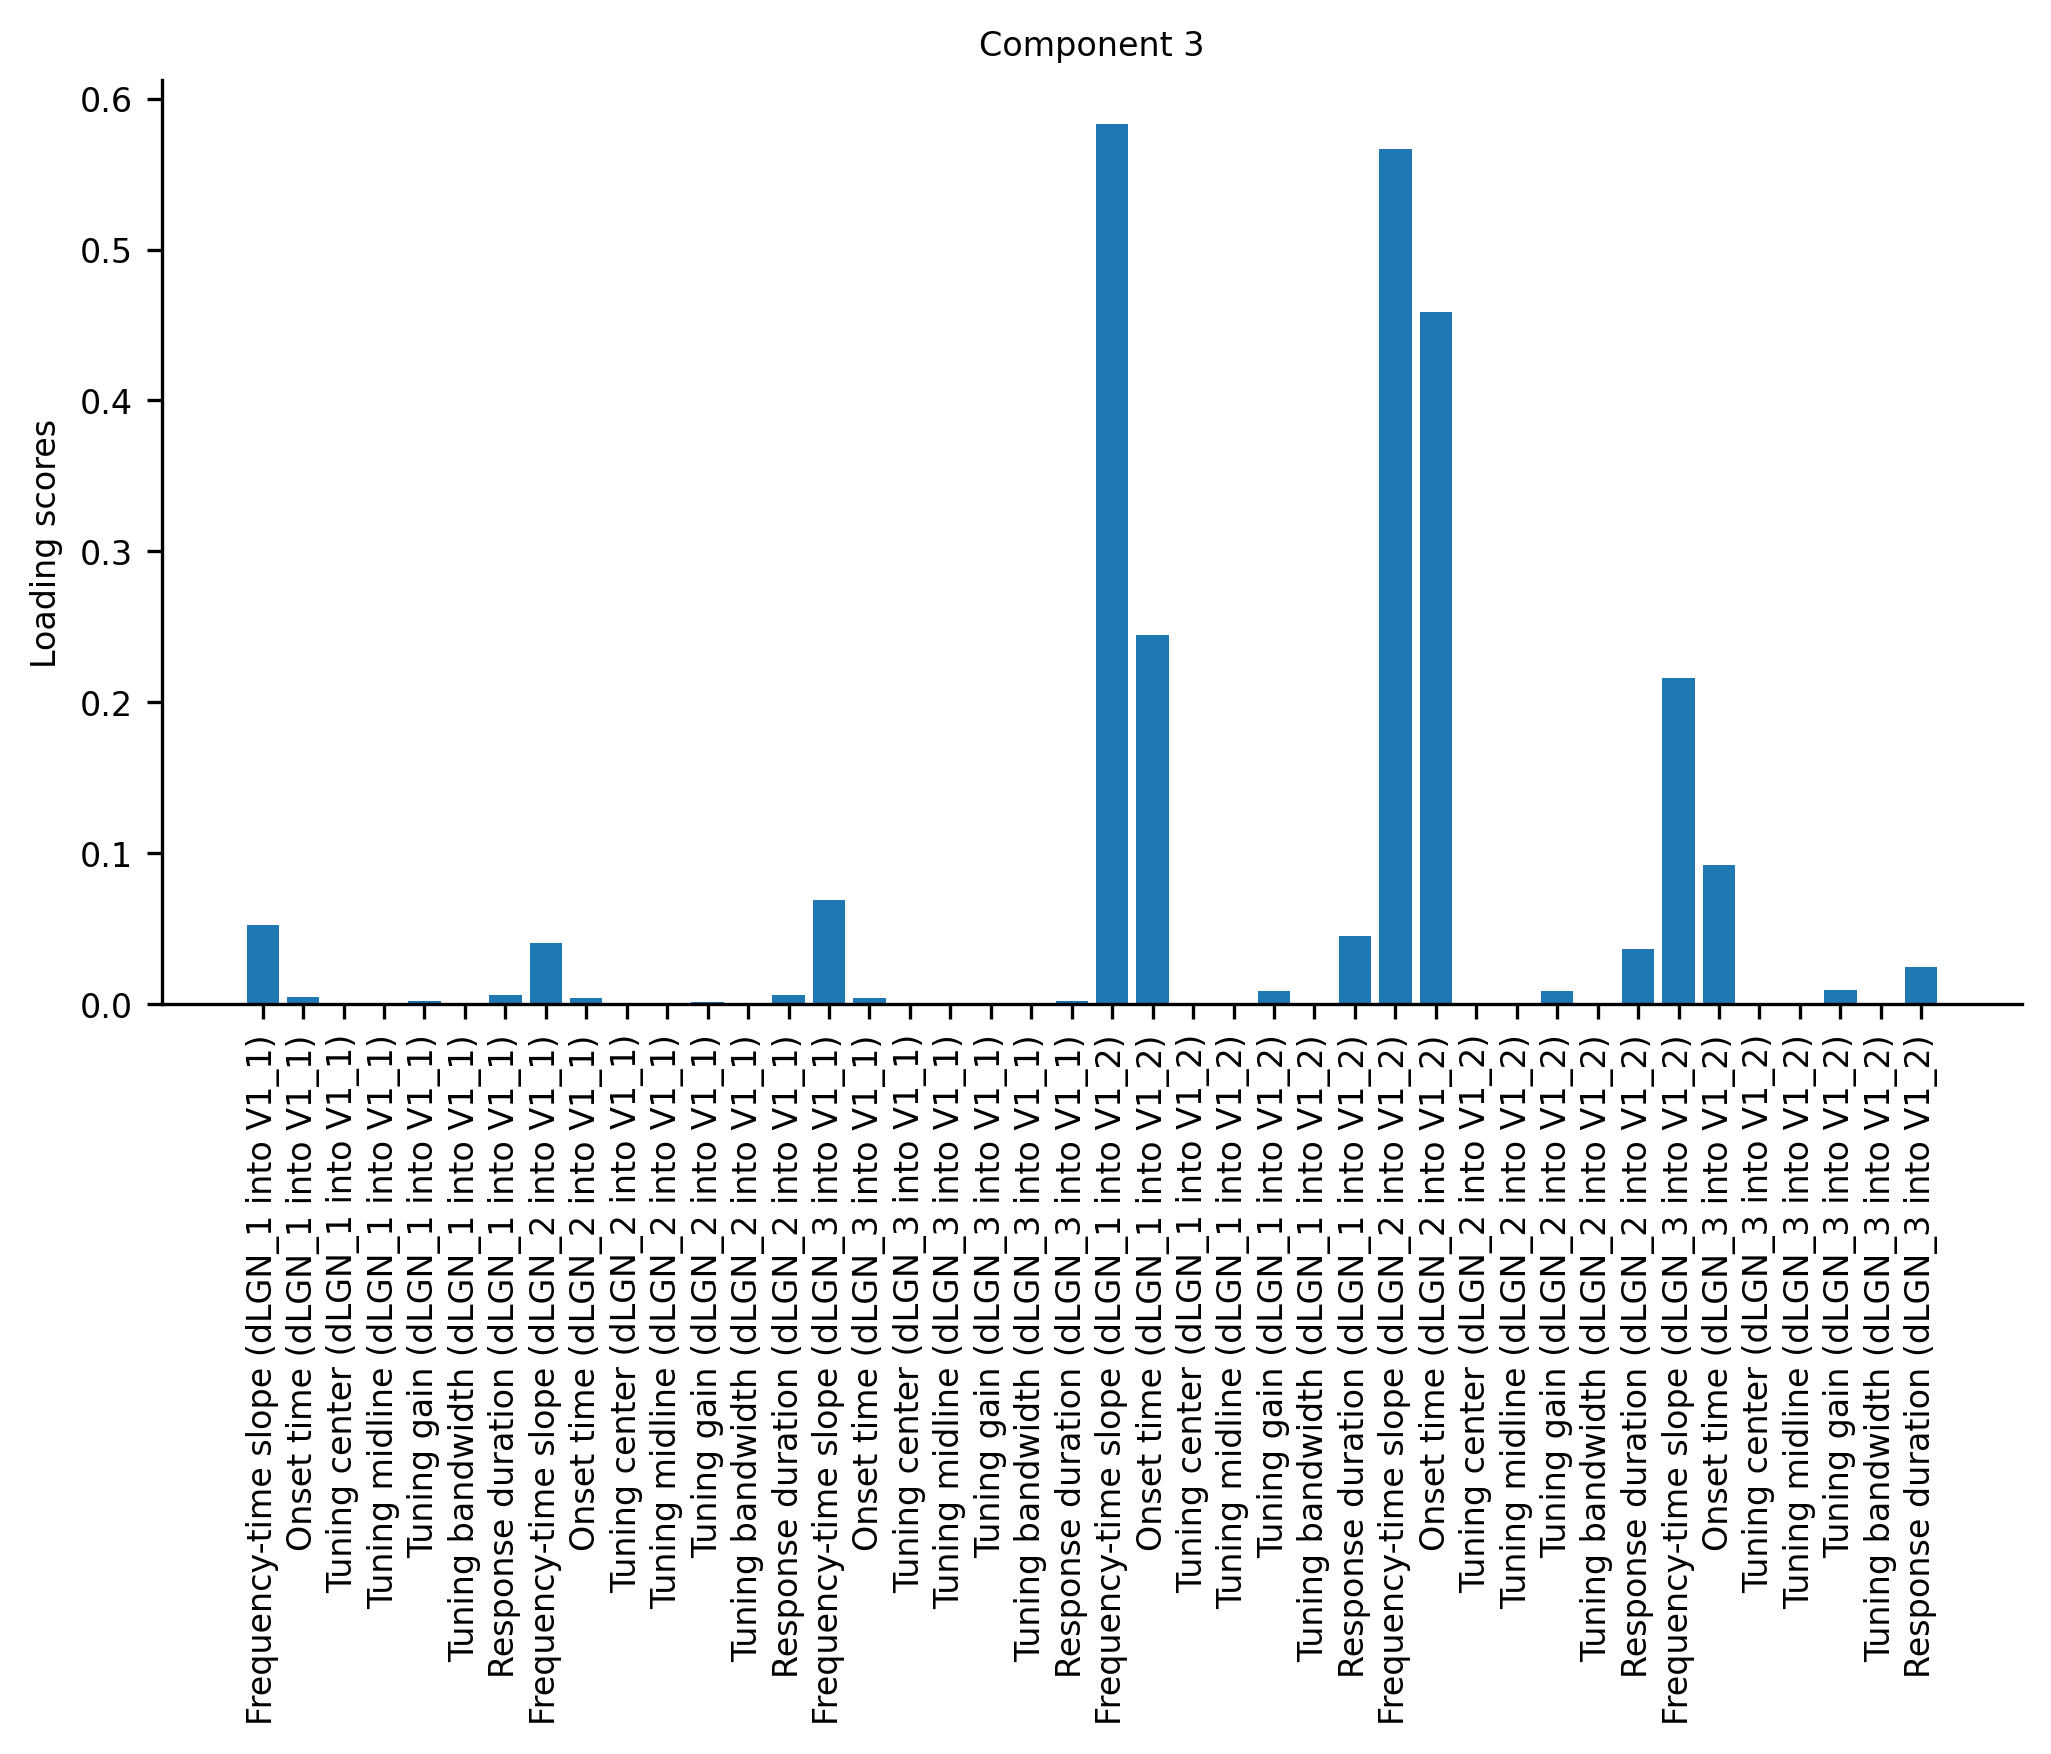

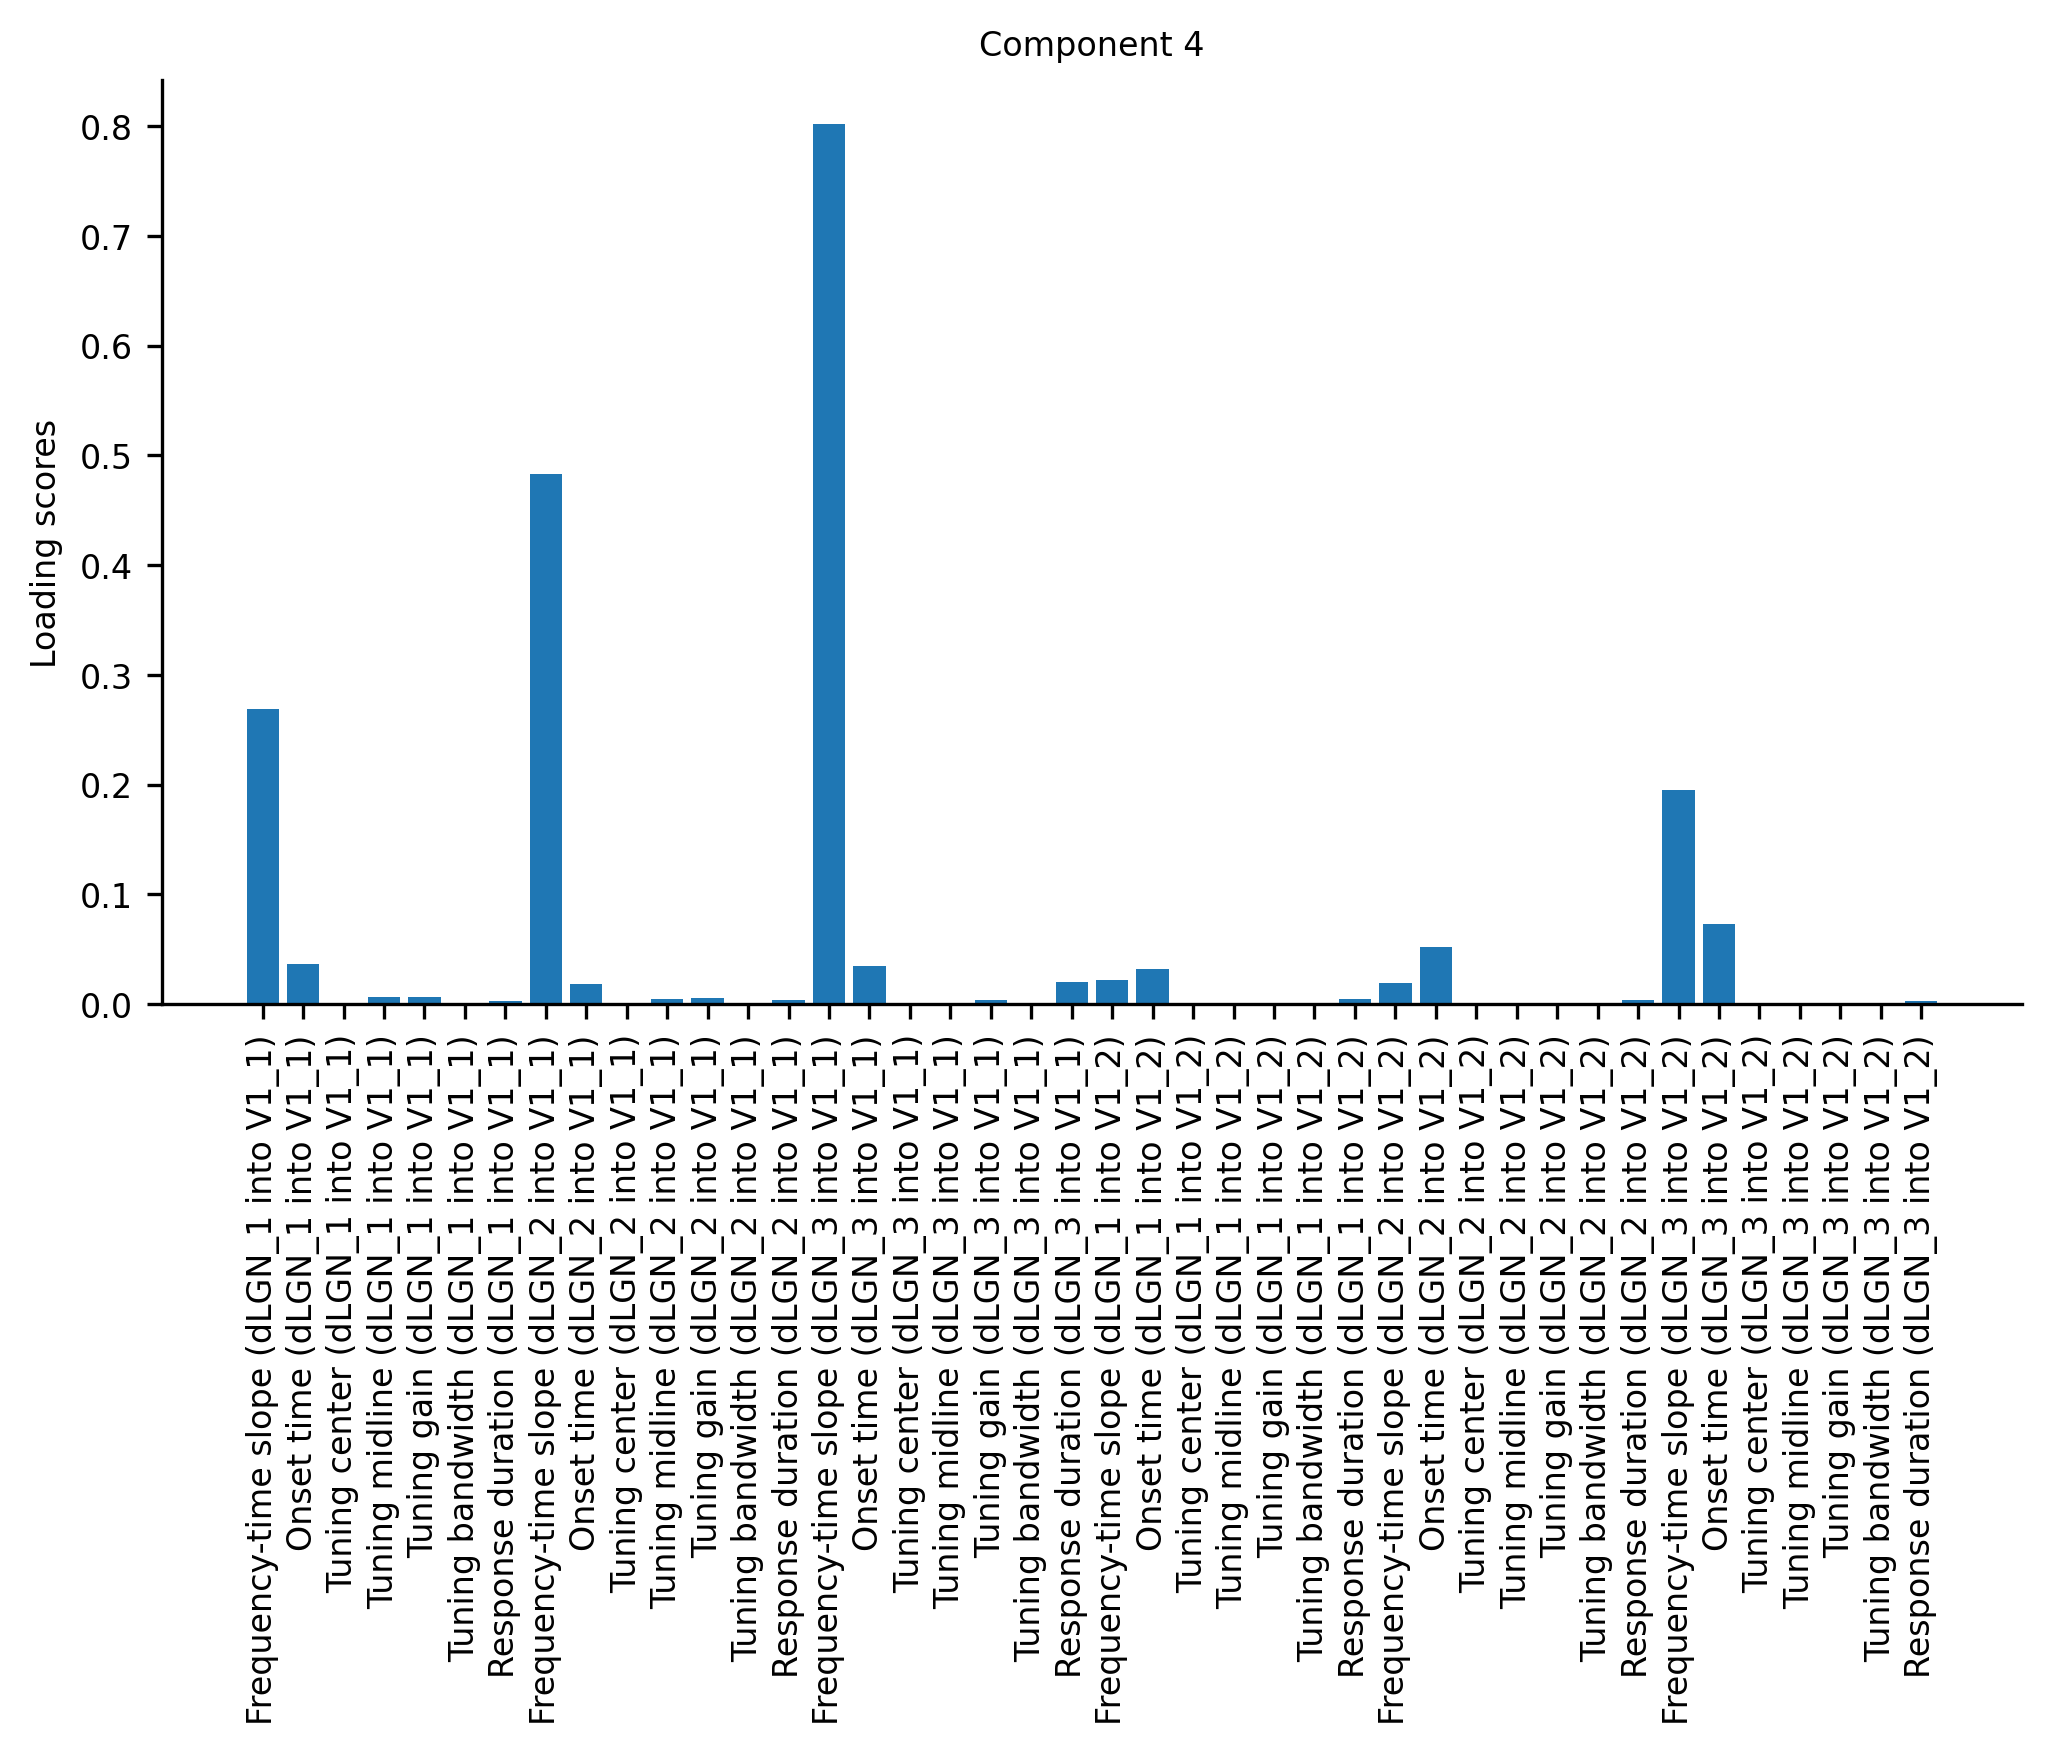

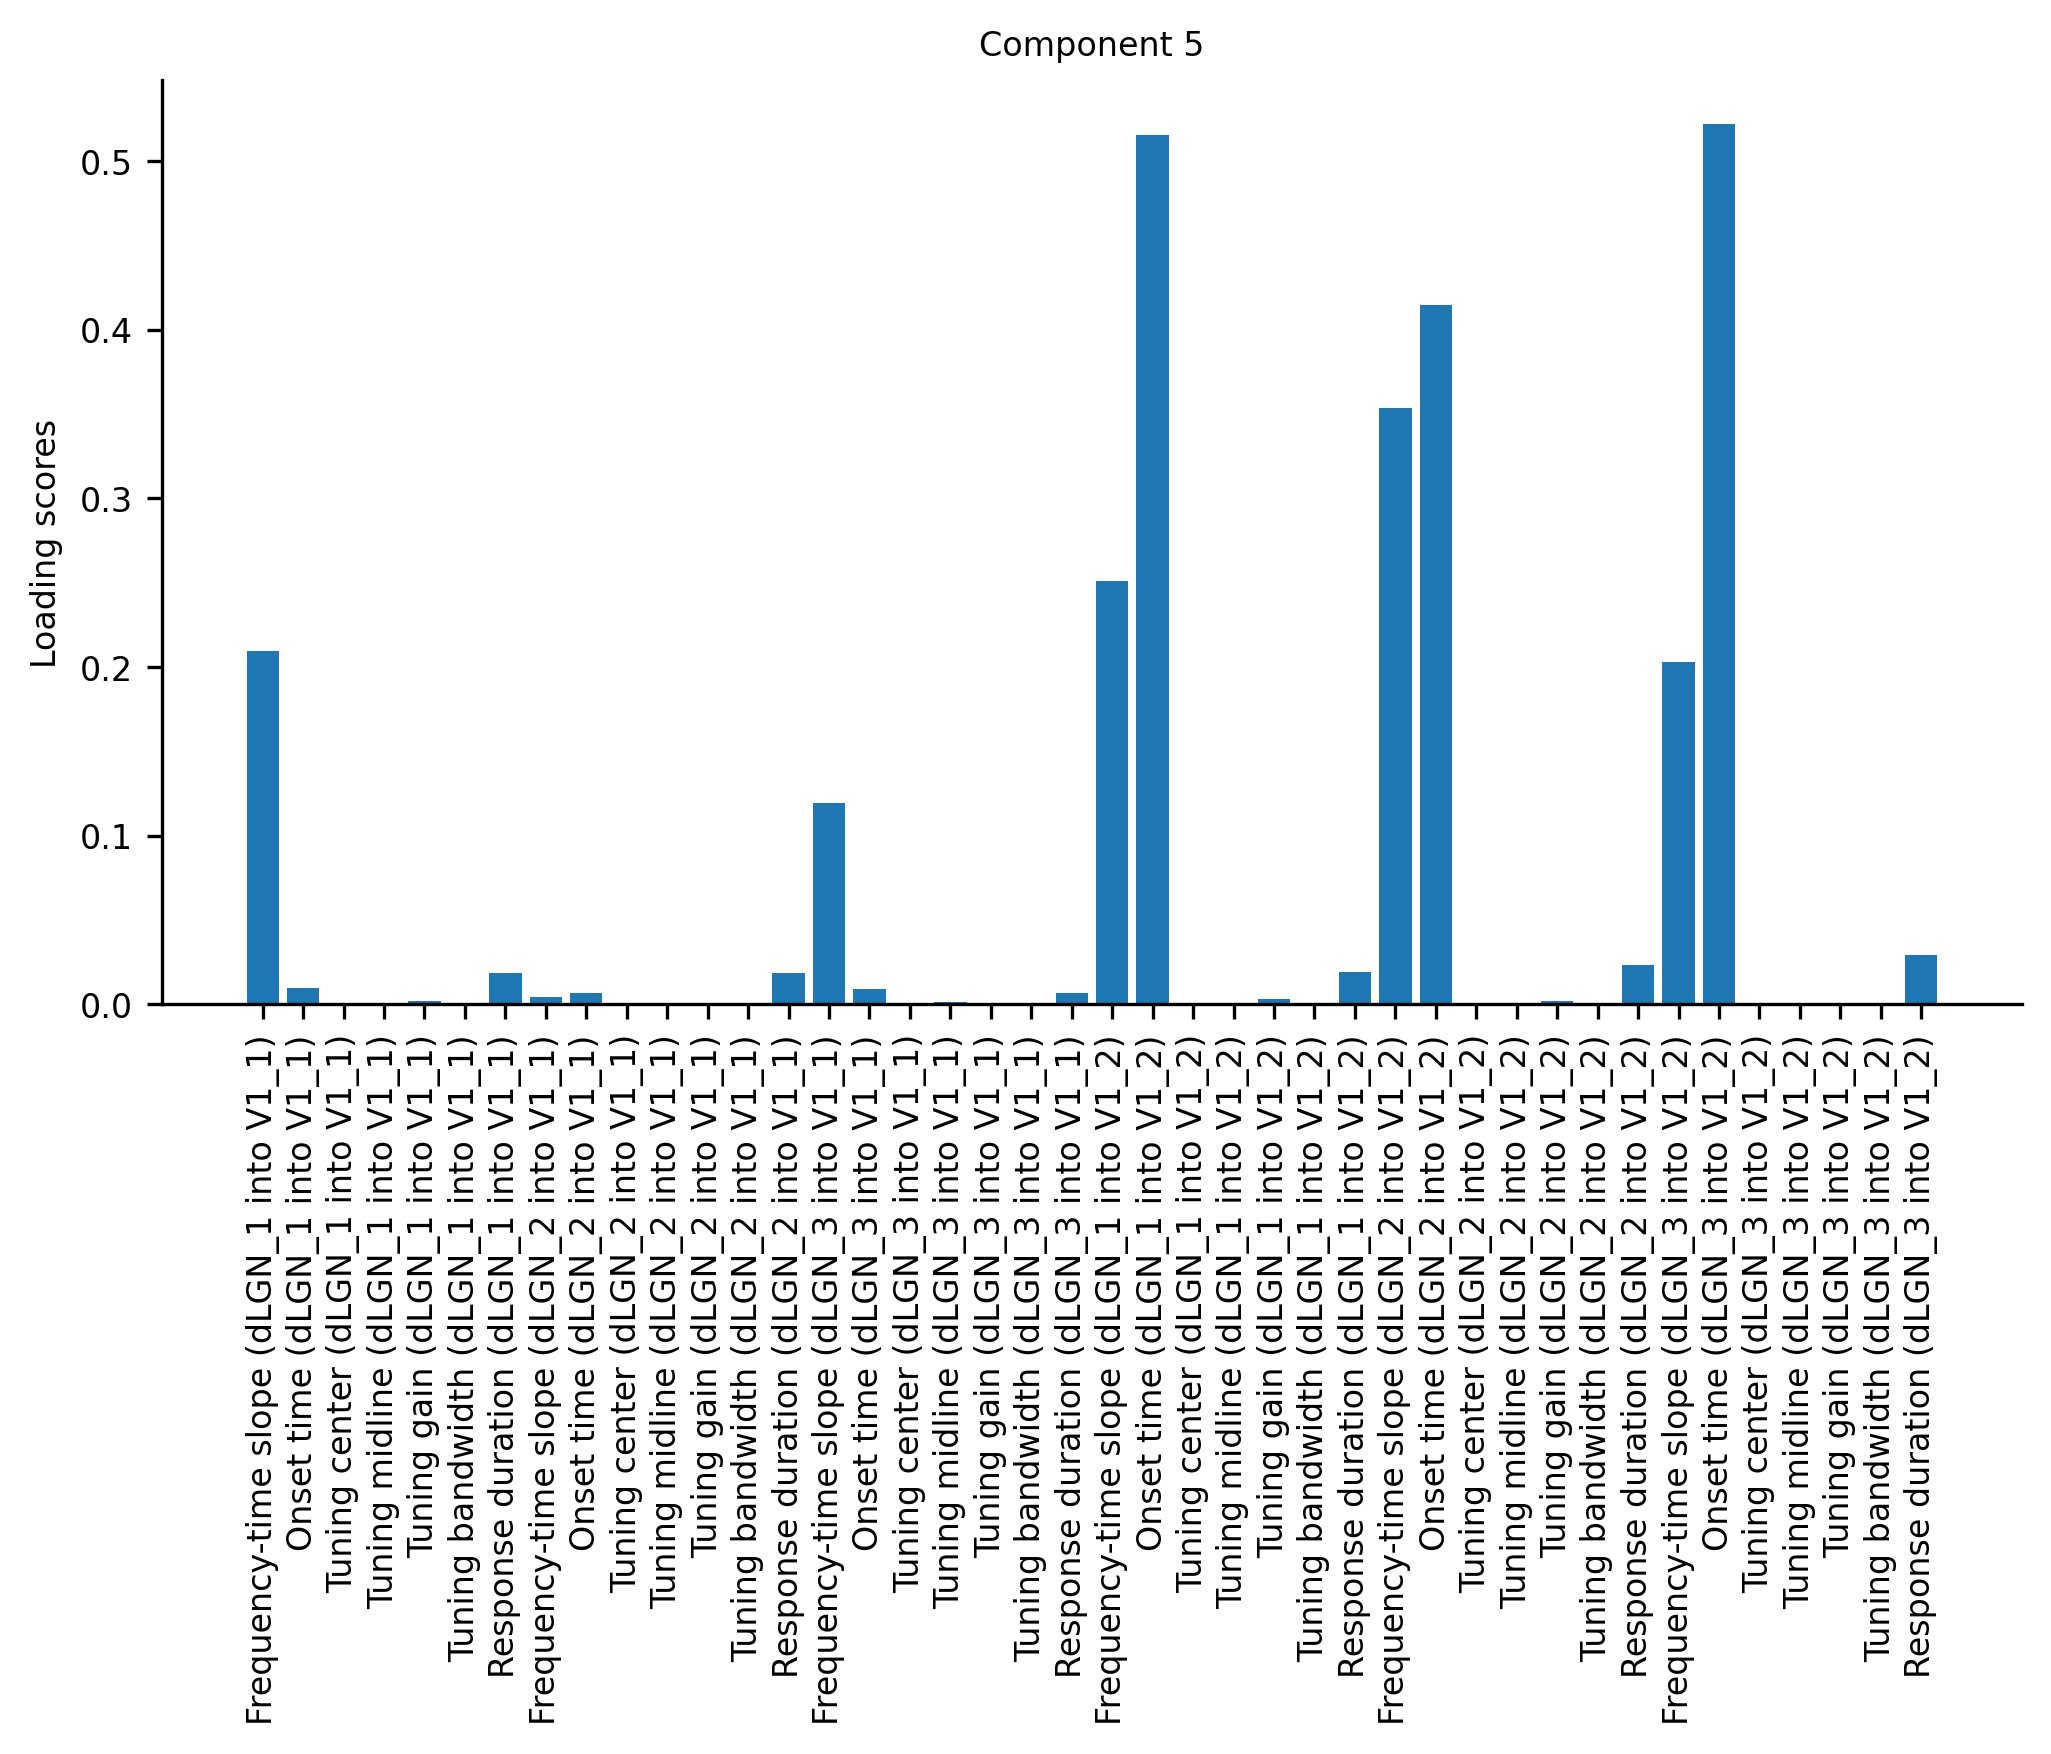

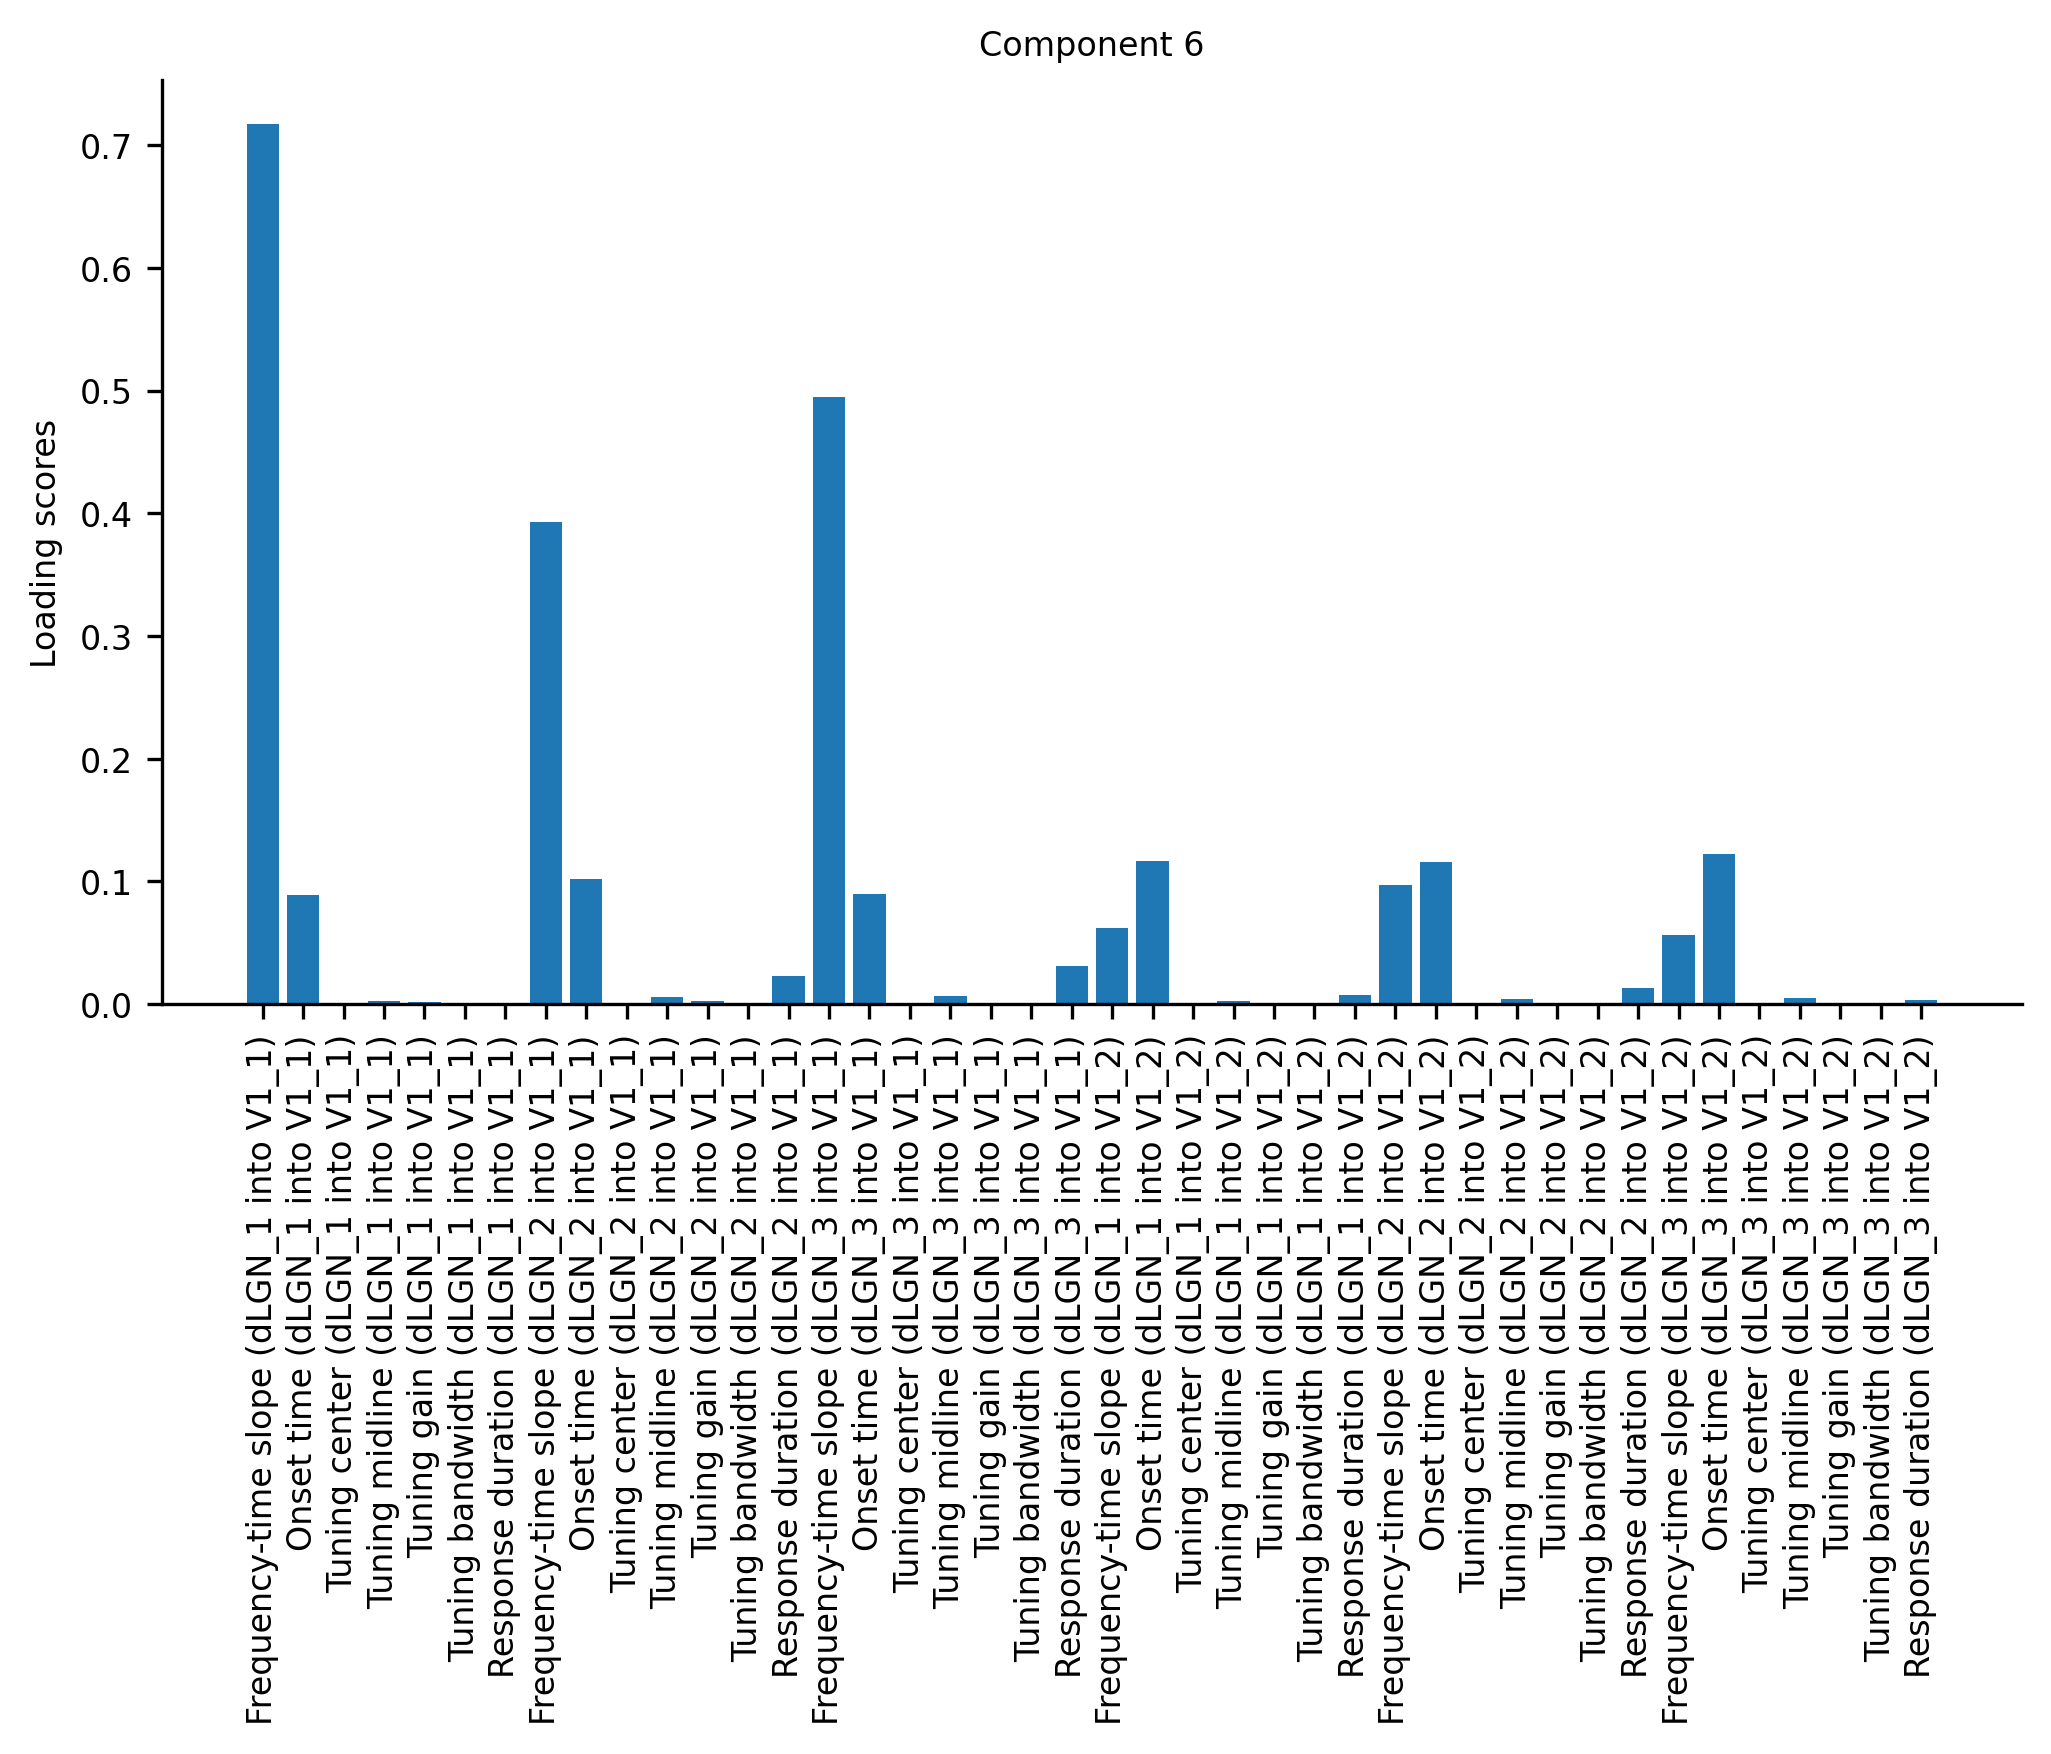

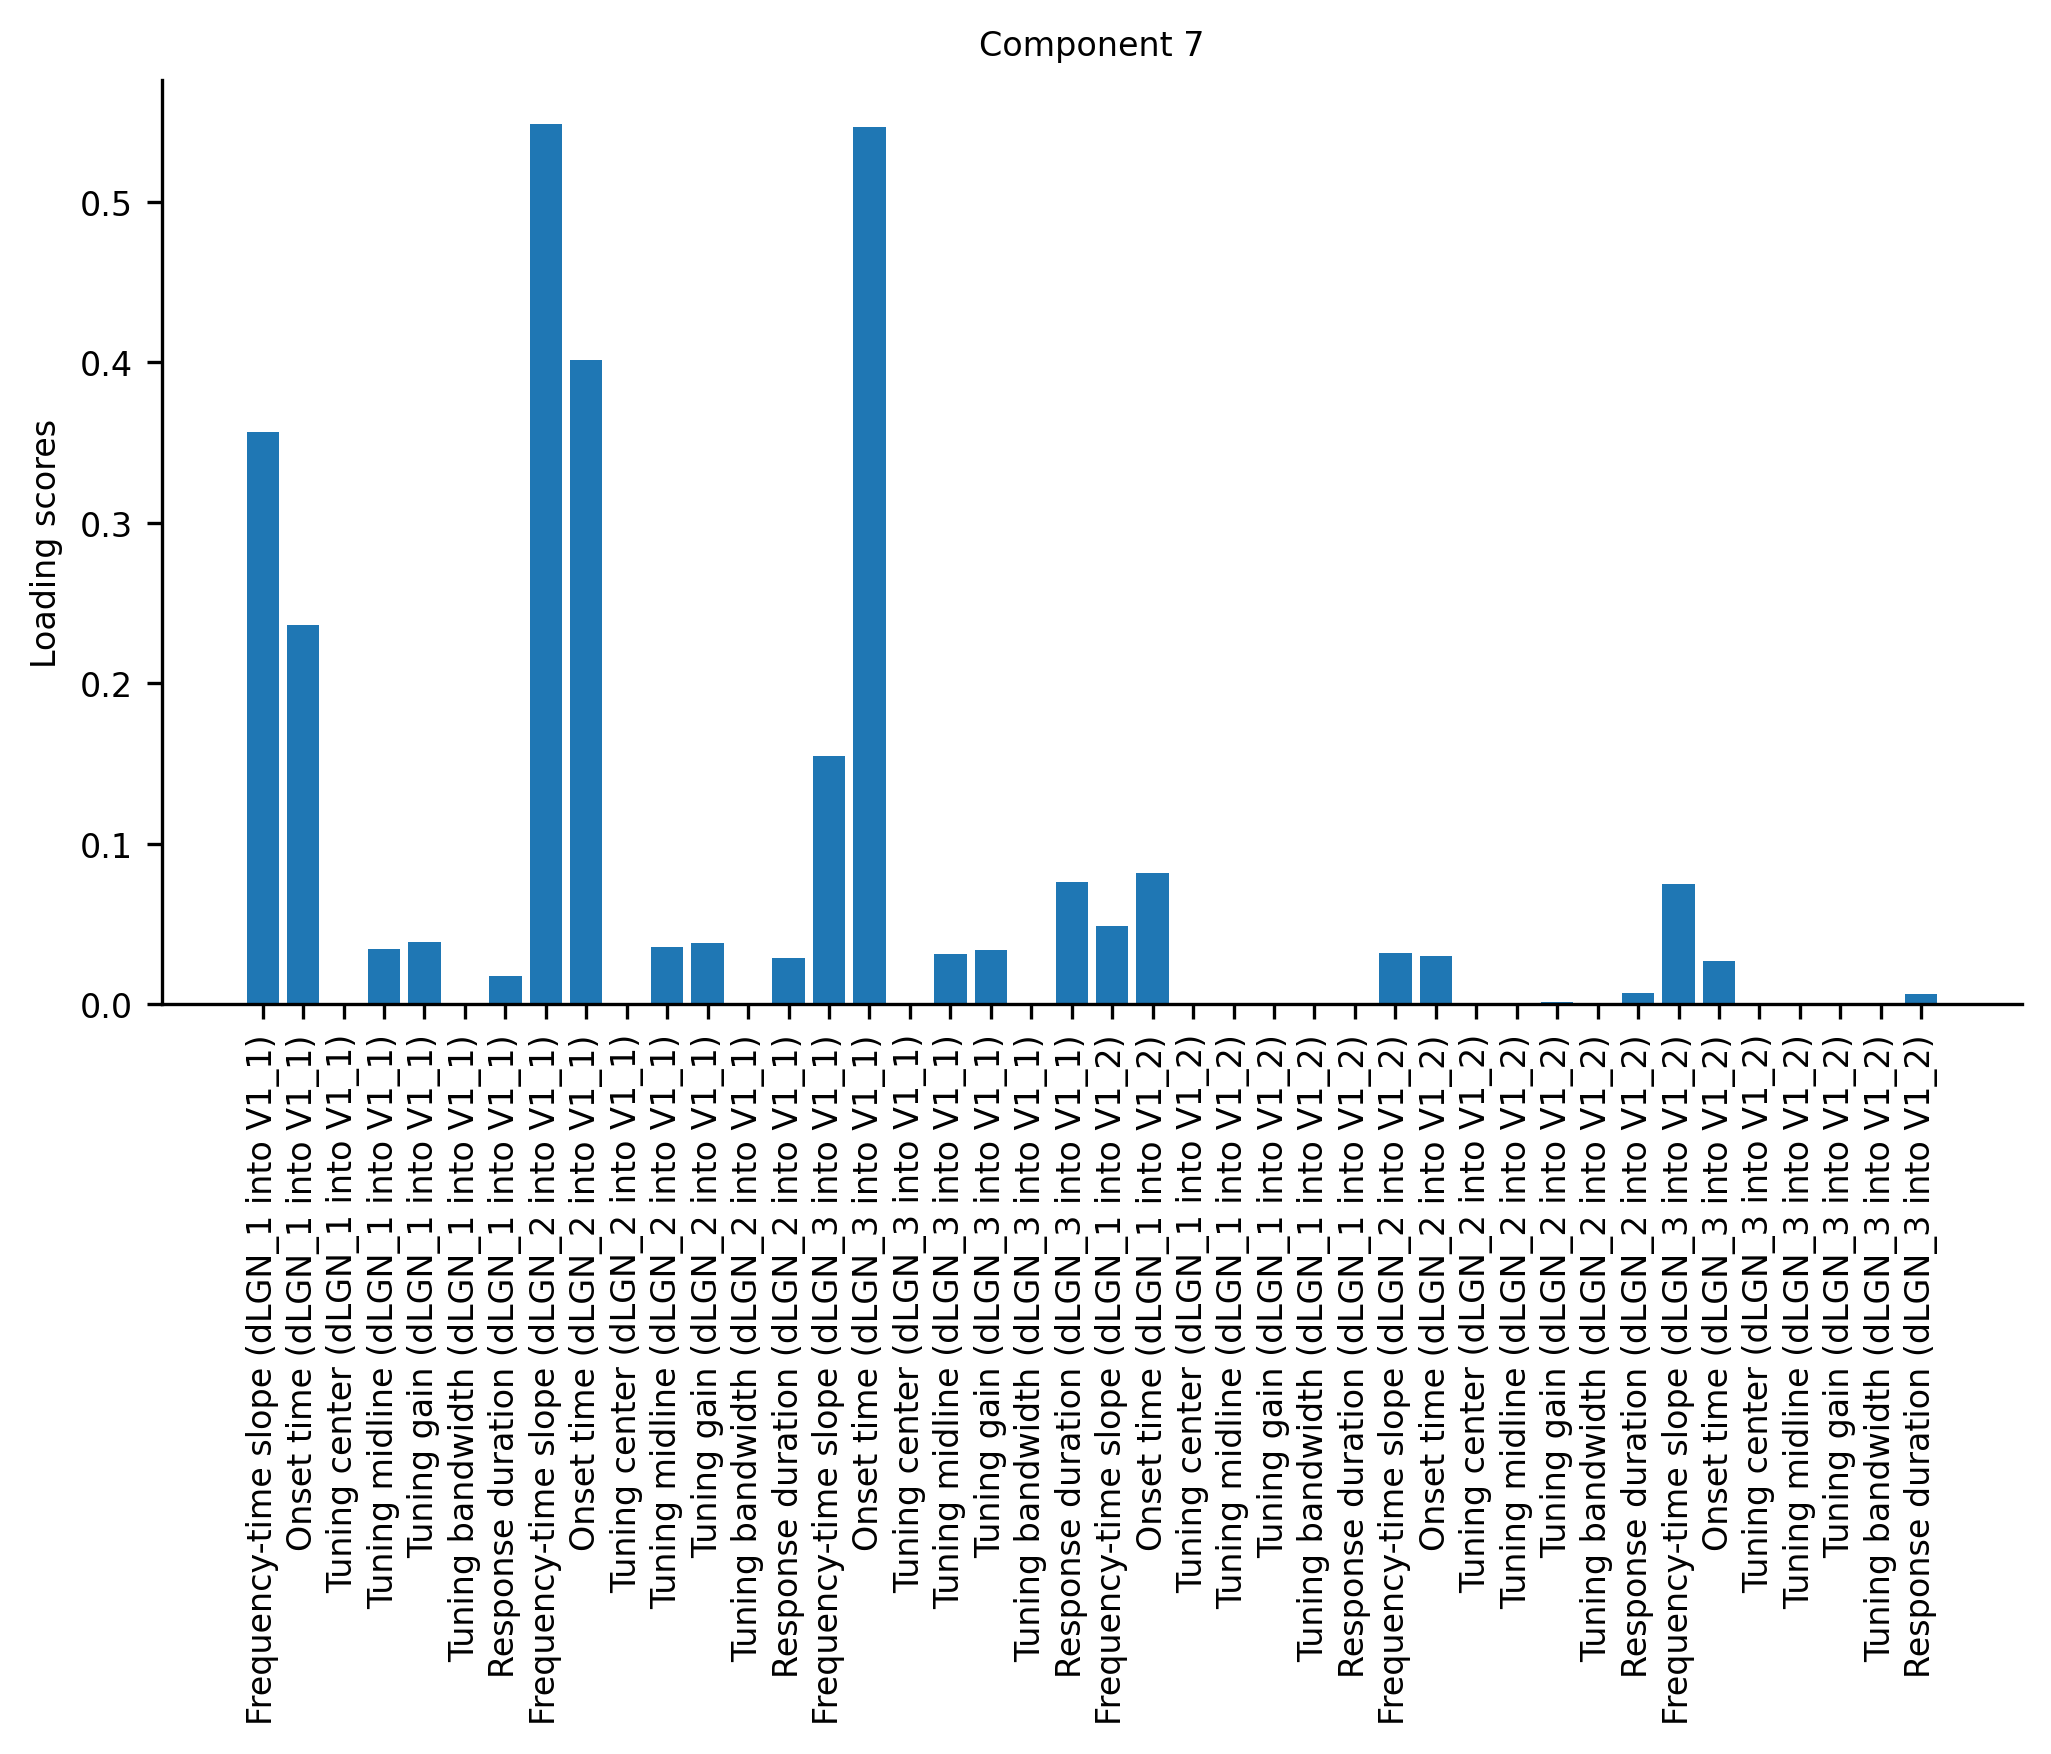

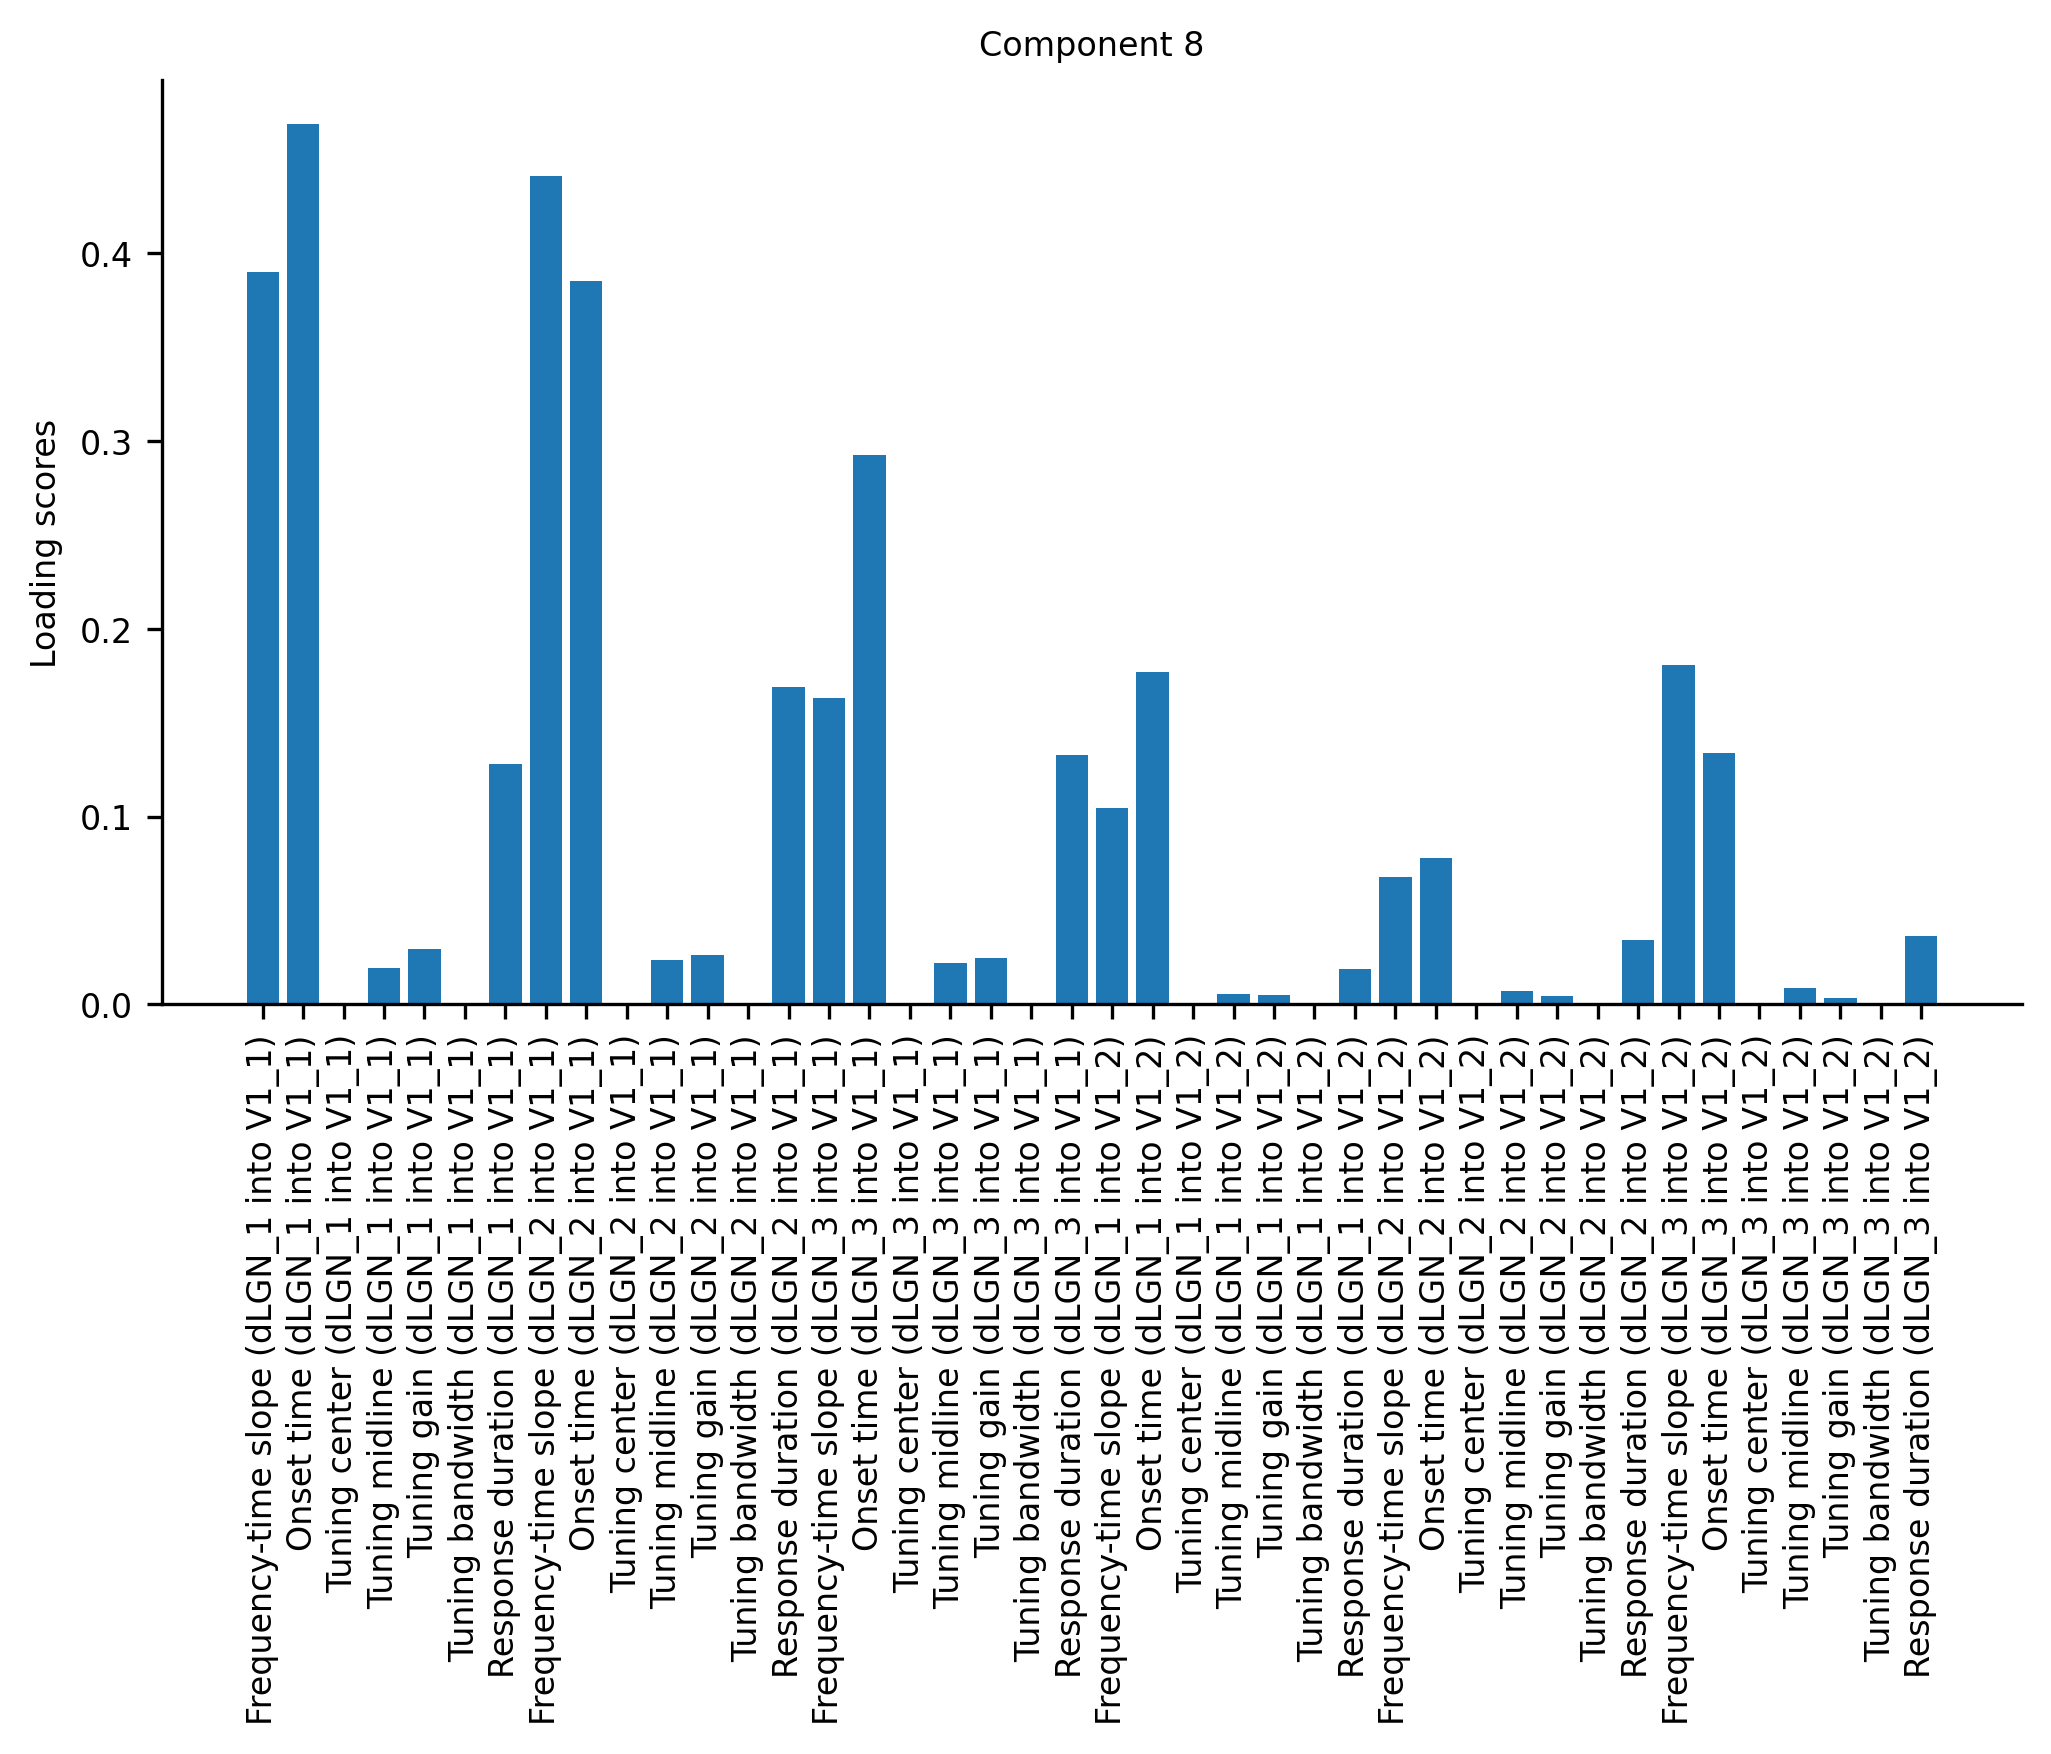

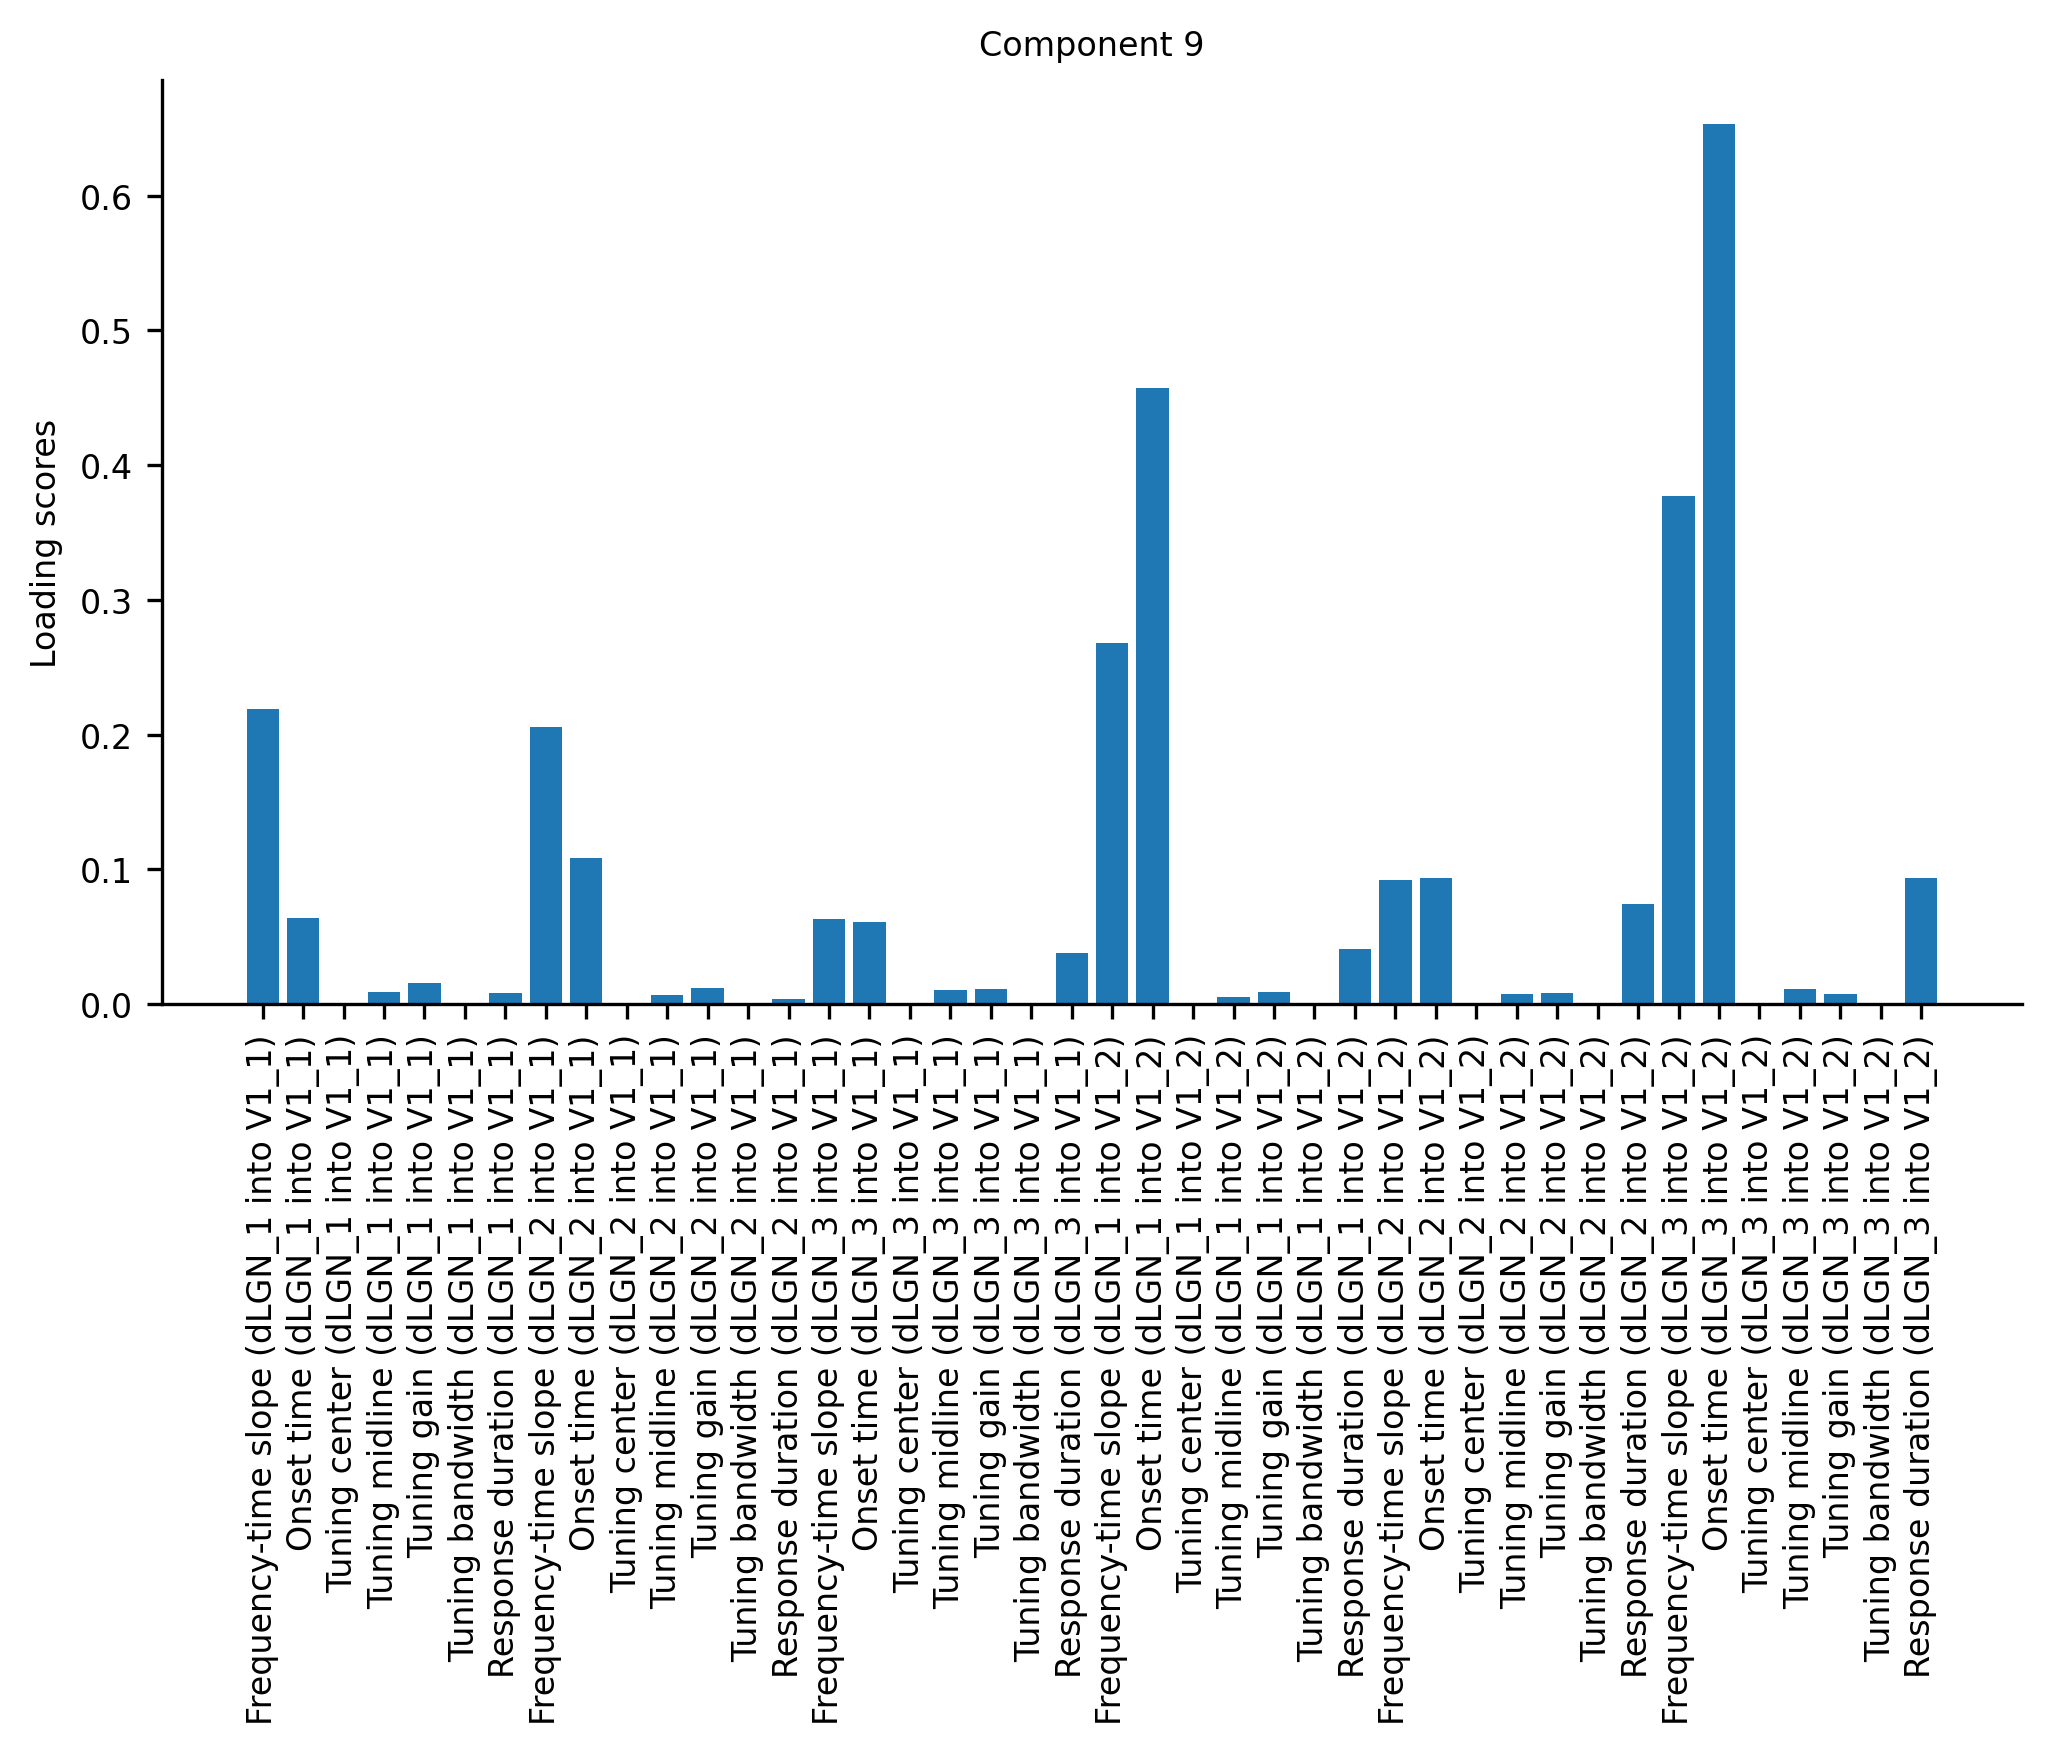

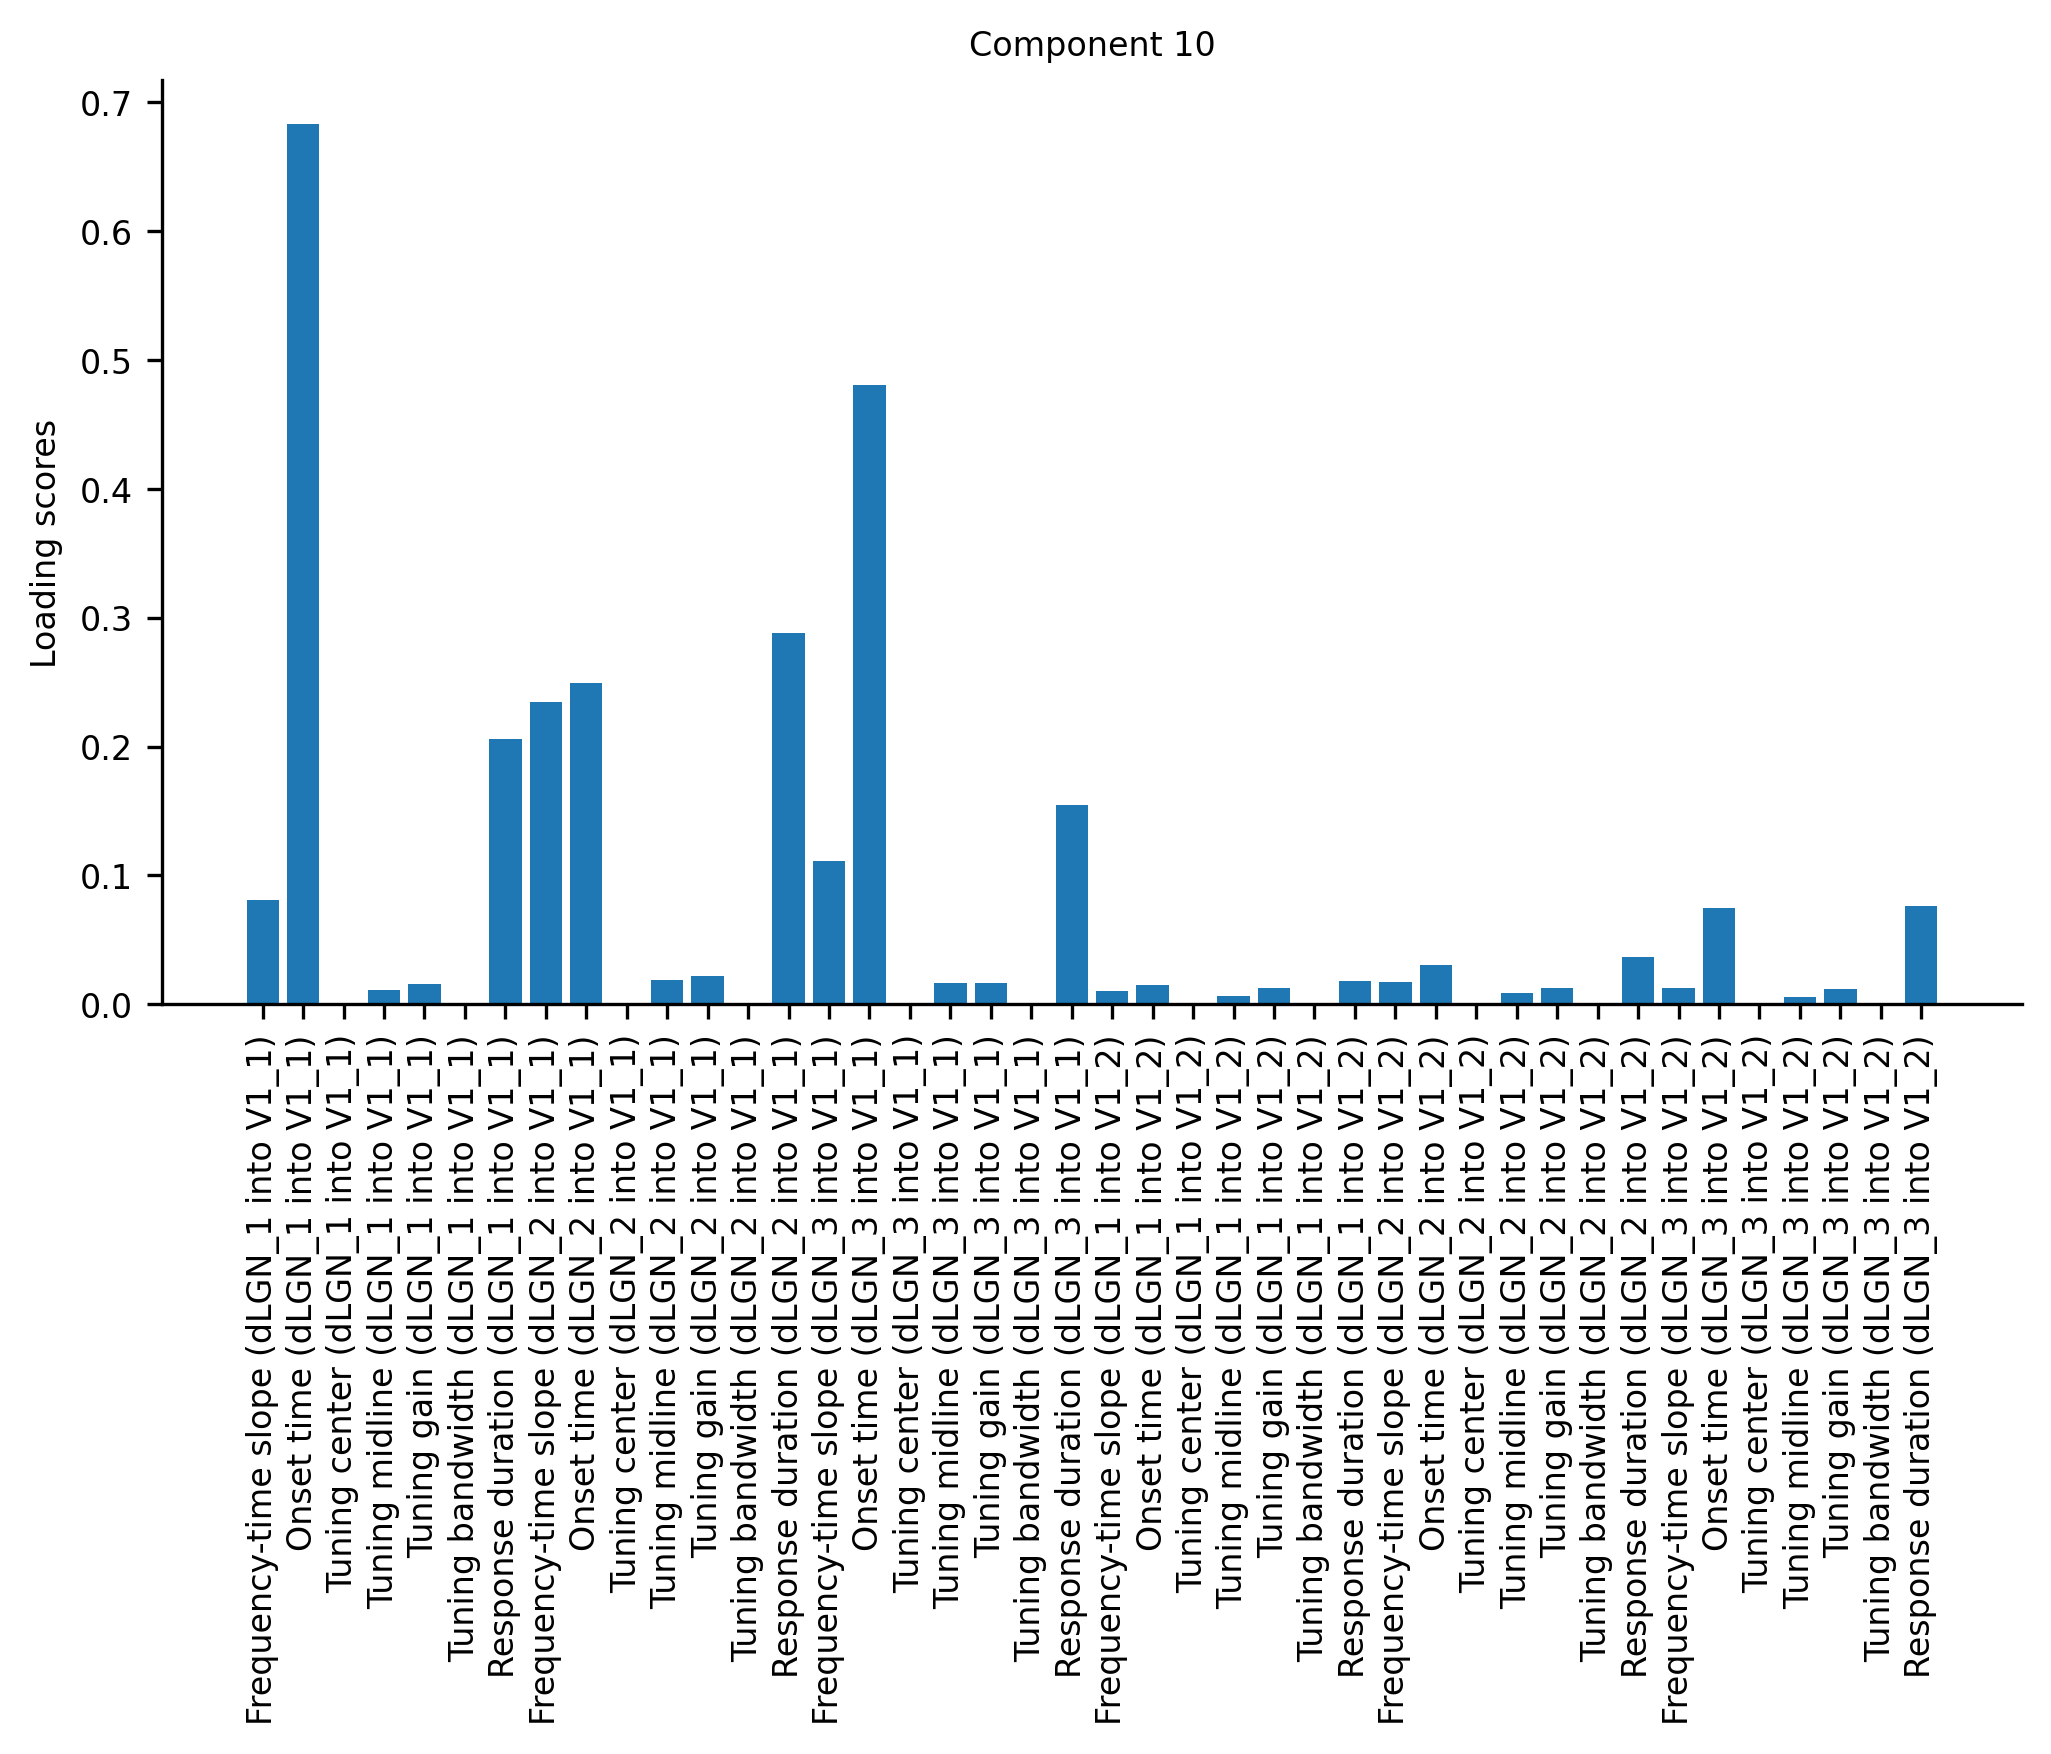

In [52]:
for i in range(10):
    fig, ax = plt.subplots(figsize = (8, 4))
    ax.tick_params(labelsize = fontsize)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.bar(np.arange(len(full_lgn_params)), np.abs(pca.components_[i]))
    ax.set_xticks(np.arange(len(full_lgn_params)))
    ax.set_xticklabels(param_names[:len(full_lgn_params)], rotation = 90)
    ax.set_ylabel("Loading scores", fontsize = fontsize)
    ax.set_title(f"Component {i+1}", fontsize = fontsize)

    figname = f'2d_model_pca_loadings_pc{i+1}_reopt.svg'
    savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
    plt.savefig(savepath, transparent = False, facecolor = 'white',
            bbox_inches = 'tight', dpi = 300)